# File Path Configuration

In [23]:
BASE_DIR = "../../../input_columns_1mm/input_columns"
SUBJECT_IDS_CSV = "../../age_prediction_on_columns_analyses/subject_ids.csv"
AGE_CSV = "../../age_prediction_on_columns_analyses/ages.csv"
METADATA_PATH = "../../../AD_DECODE_data3.xlsx"
THICKNESS_DIR = '../../../thickness_in_region'

# COLUMNS MEAN

In [24]:
import os  # For handling file paths and directories
import pandas as pd  # For working with tabular data using DataFrames
import matplotlib.pyplot as plt  # For generating plots
import zipfile  # For reading compressed files without extracting them
import re  # For extracting numerical IDs using regular expressions

import torch
import random
import numpy as np

import os
import pandas as pd
import numpy as np

import networkx as nx  # For graph-level metrics

# === Set seed for reproducibility ===
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

## Load columns

In [25]:
# Base directory where subject folders (e.g., S00775_columns_1mm) are stored
BASE_DIR = BASE_DIR

In [26]:
# List of hemispheres
HEMIS = ["lh", "rh"]

# List of cortical regions (based on the parcellation used)
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]

In [27]:
# Paths to CSVs
SUBJECT_IDS_CSV = SUBJECT_IDS_CSV
AGE_CSV = AGE_CSV

# Load both files (no headers)
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
age_df = pd.read_csv(AGE_CSV, header=None)

# Zero-pad subject IDs to 5 digits
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()
ages = age_df[0].astype(float).tolist()

# Build dictionary: subject_id → age
age_dict = dict(zip(subject_ids, ages))

In [28]:
# Final dictionary: subject_id -> region -> matrix
column_data = {}

# Loop through subjects
for subj_id in subject_ids:
    subj_dict = {}
    subj_dir = os.path.join(BASE_DIR, f"S{subj_id}_columns_1mm")
    subj_dir_to_thickness = os.path.join(THICKNESS_DIR, f"S{subj_id}")  # Path to subject's thickness folder

    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            filename = f"S{subj_id}_{region_key}_md.csv"
            thickness_filename = f"S{subj_id}{region_key}_thickness.csv"
            # Construct full file paths
            filepath = os.path.join(subj_dir, filename)
            thickness_filepath = os.path.join(subj_dir_to_thickness, thickness_filename)

            if not os.path.exists(filepath):
                print(f"[WARNING] Missing: {filepath}")
                continue
            if not os.path.exists(thickness_filepath):
                print(f"[WARNING] Missing thickness file: {thickness_filepath}")
                continue

            # Load the thickness CSV matrix and get the mean thickness value
            thickness_mat = pd.read_csv(thickness_filepath, header=None).values.astype(np.float32)
            if thickness_mat.size == 0:
                print(f"[WARNING] Empty thickness matrix for {thickness_filepath}")
                continue
            # Calculate mean thickness for the region
            mean_thickness = np.mean(thickness_mat)

            mat = pd.read_csv(filepath, header=None).values.astype(np.float32)
            # Add mean thickness as an additional attribute to the matrix
            if mat.size == 0:
                print(f"[WARNING] Empty matrix for {filepath}")
                continue
            # Add mean thickness as an additional attribute to the matrix
            mat = np.append(mat, mean_thickness)  # Append mean thickness as the last element of the matrix
            subj_dict[region_key] = mat

    if len(subj_dict) > 0:
        column_data[subj_id] = subj_dict
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions)")

# === Example: print region shapes per subject ===
for subj_id, regions in column_data.items():
    print(f"\nSubject {subj_id}:")
    for region_name, matrix in regions.items():
        print(f"  {region_name} → {matrix.shape}")

[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_bankssts_md.csv
[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_caudalanteriorcingulate_md.csv
[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_caudalmiddlefrontal_md.csv
[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_cuneus_md.csv
[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_entorhinal_md.csv
[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_fusiform_md.csv
[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_inferiorparietal_md.csv
[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_inferiortemporal_md.csv
[WARNING] Missing: ../../../input_columns_1mm/input_columns\S03866_columns_1mm\S03866_lh_isthmuscingulate_md.csv
[WARN

# CONSTRUCT GRAPHS 

In [29]:
import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors

In [30]:
# Get subject's data (dict: region → matrix)
subject_data = column_data[subj_id]

In [31]:
#Normalize
from sklearn.preprocessing import StandardScaler

# Concatenate all regions for one subject
x_np = np.vstack(list(subject_data.values()))  # shape [n_total_columns, 21]

# Z-score normalization across all features (columns)
scaler = StandardScaler()
x_np = scaler.fit_transform(x_np)

In [32]:
# === STEP 1: Build edge_index from K-Nearest Neighbors ===

def build_knn_edge_index(x_np, k=10):
    """
    Builds the edge_index for a graph using KNN based on node features.

    Args:
        x_np (np.ndarray): shape [n_nodes, n_features]
        k (int): number of neighbors per node

    Returns:
        edge_index (torch.LongTensor): shape [2, num_edges]
    """
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    knn.fit(x_np)
    knn_graph = knn.kneighbors_graph(x_np).tocoo()

    edge_index = torch.tensor(
        np.vstack((knn_graph.row, knn_graph.col)),
        dtype=torch.long
    )
    return edge_index

# === STEP 2: Build PyG graph from a single subject ===

def build_graph_from_subject(subj_id, column_data, age_dict, k=10):
    """
    Converts one subject's cortical column data into a PyTorch Geometric graph.

    Args:
        subj_id (str): subject ID
        column_data (dict): {subject_id → {region_name → matrix}}
        age_dict (dict): {subject_id → age}
        k (int): number of KNN neighbors

    Returns:
        Data: PyTorch Geometric graph with x, edge_index, y
    """
    # Get all regions from this subject and stack all columns
    subj_regions = column_data[subj_id]
    x_np = np.vstack(list(subj_regions.values()))  # shape [n_columns_total, 21]

    # Convert features to tensor
    x = torch.tensor(x_np, dtype=torch.float32)

    # Build edge_index using KNN over node features
    edge_index = build_knn_edge_index(x_np, k=k)

    # Get subject's age and convert to tensor
    y = torch.tensor([age_dict[subj_id]], dtype=torch.float32)

    # Create PyG Data object
    data = Data(x=x, edge_index=edge_index, y=y)
    data.subject_id = subj_id  # optional: store ID for reference
    return data

# === STEP 3: Loop through all subjects and build their graphs ===

graph_data_list_all = []

for subj_id in column_data:
    if subj_id in age_dict:
        graph = build_graph_from_subject(subj_id, column_data, age_dict, k=10)
        graph_data_list_all.append(graph)
        print(f" Built graph for subject {subj_id} with {graph.num_nodes} nodes")
    else:
        print(f"[WARNING] No age found for subject {subj_id}")

 Built graph for subject 02110 with 68 nodes


 Built graph for subject 02363 with 68 nodes
 Built graph for subject 02373 with 68 nodes
 Built graph for subject 02386 with 68 nodes
 Built graph for subject 02390 with 68 nodes
 Built graph for subject 02231 with 68 nodes
 Built graph for subject 02402 with 68 nodes
 Built graph for subject 02410 with 68 nodes
 Built graph for subject 02421 with 68 nodes
 Built graph for subject 01912 with 68 nodes
 Built graph for subject 02424 with 68 nodes
 Built graph for subject 02446 with 68 nodes
 Built graph for subject 02451 with 68 nodes
 Built graph for subject 02485 with 68 nodes
 Built graph for subject 02473 with 68 nodes
 Built graph for subject 02491 with 68 nodes
 Built graph for subject 02506 with 68 nodes
 Built graph for subject 02524 with 68 nodes
 Built graph for subject 02535 with 68 nodes
 Built graph for subject 02654 with 68 nodes
 Built graph for subject 02666 with 68 nodes
 Built graph for subject 02670 with 68 nodes
 Built graph for subject 02690 with 68 nodes
 Built gra

## Visualize graph

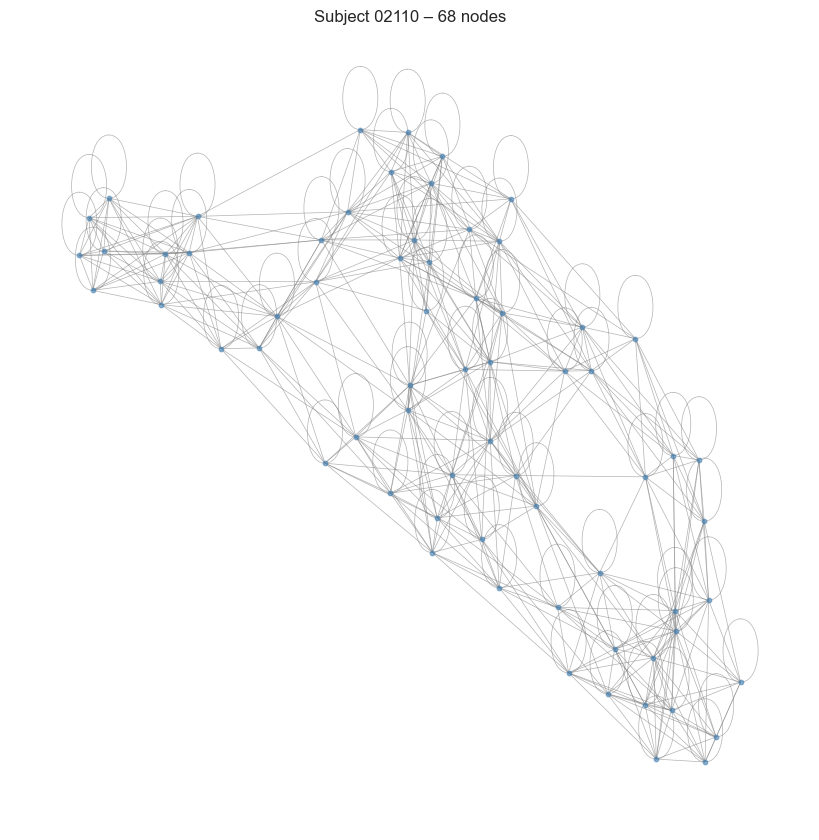

In [33]:

import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

# === Pick the first subject's graph ===
graph = graph_data_list_all[0]

# === Convert PyG graph to NetworkX for visualization ===
G = to_networkx(graph, to_undirected=True)

# === Optional: layout (slower for large graphs) ===
pos = nx.spring_layout(G, seed=42)  # force-directed layout

# === Plot ===
plt.figure(figsize=(8, 8))
nx.draw(G, pos, node_size=10, node_color='steelblue', edge_color='gray', alpha=0.6, width=0.5)

plt.title(f"Subject {graph.subject_id} – {graph.num_nodes} nodes")
plt.axis('off')
plt.show()

## Apply pretraining

In [34]:
#####################  DEVICE CONFIGURATION  #######################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [35]:
import torch
print(torch.__version__)
print(torch.version.cuda)  # should NOT be None if CUDA is enabled
print(torch.cuda.is_available())  # should be True if GPU is usable


2.5.1+cu121
12.1
True


In [36]:
#DEFINE MODEL GCNs
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

class BrainAgeGNN(torch.nn.Module):
    def __init__(self, input_dim=22):  # ← set to 22 features per node
        super(BrainAgeGNN, self).__init__()

        self.conv1 = GCNConv(input_dim, 64)
        self.bn1 = BatchNorm(64)

        self.conv2 = GCNConv(64, 128)
        self.bn2 = BatchNorm(128)

        self.conv3 = GCNConv(128, 128)
        self.bn3 = BatchNorm(128)

        self.fc = torch.nn.Linear(128, 1)
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x_residual = x
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = x + x_residual

        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        x = self.fc(x)

        return x.view(-1)

In [37]:
from torch_geometric.loader import DataLoader
import pandas as pd
import numpy as np
import torch

# === Load the trained model on all healthy+familial subjects ===
model = BrainAgeGNN(input_dim=22).to(device)  # Input: 21 features per column
model.load_state_dict(torch.load("column_md_model_trained_on_all_healthy.pt"))  # Load pretrained weights
model.eval()  # Set model to evaluation mode (disables dropout, etc.)

# === Create a DataLoader for all subjects (including AD, MCI, etc.) ===
all_graph_loader = DataLoader(graph_data_list_all, batch_size=6, shuffle=False)

# === Prepare storage for results ===
all_preds = []        # Predicted ages
all_ids = []          # Subject IDs
all_true_ages = []    # Ground-truth chronological ages

# === Perform inference ===
with torch.no_grad():  # Disable gradient computation for efficiency
    for data in all_graph_loader:
        data = data.to(device)  # Move data to GPU or CPU
        output = model(data).view(-1)  # Predict age for each graph in the batch
        all_preds.extend(output.cpu().tolist())        # Store predictions
        all_true_ages.extend(data.y.cpu().tolist())    # Store true ages
        all_ids.extend(data.subject_id)                # Store subject IDs

# === Organize results into a DataFrame ===
df_results = pd.DataFrame({
    "subject_id": all_ids,
    "age": all_true_ages,
    "predicted_age": all_preds
})

# === Compute Brain Age Gap (BAG = predicted - actual age) ===
df_results["BAG"] = df_results["predicted_age"] - df_results["age"]

# === Save results to CSV file ===
df_results.to_csv("column_model_predictions_all_subjects.csv", index=False)
print(" Predictions saved to 'column_model_predictions_all_subjects.csv'")

 Predictions saved to 'column_model_predictions_all_subjects.csv'


C:\Users\22679\AppData\Local\Temp\ipykernel_48892\1648645830.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("column_md_model_trained_on

# cbag

In [38]:
from sklearn.linear_model import LinearRegression
import numpy as np

# === Compute corrected BAG (cBAG) ===

# Fit linear regression: BAG ~ age
X = df_results["age"].values.reshape(-1, 1)  # Predictor: age
y = df_results["BAG"].values                # Target: BAG
reg = LinearRegression().fit(X, y)

# Predict age effect (regression line)
age_effect = reg.predict(X)

# Subtract regression line to get cBAG
df_results["cBAG"] = df_results["BAG"] - age_effect

# === Save updated results ===
df_results.to_csv("column_model_predictions_all_subjects_with_cBAG.csv", index=False)
print(" Results with cBAG saved to 'column_model_predictions_all_subjects_with_cBAG.csv'")

 Results with cBAG saved to 'column_model_predictions_all_subjects_with_cBAG.csv'


# plot bag and cbag

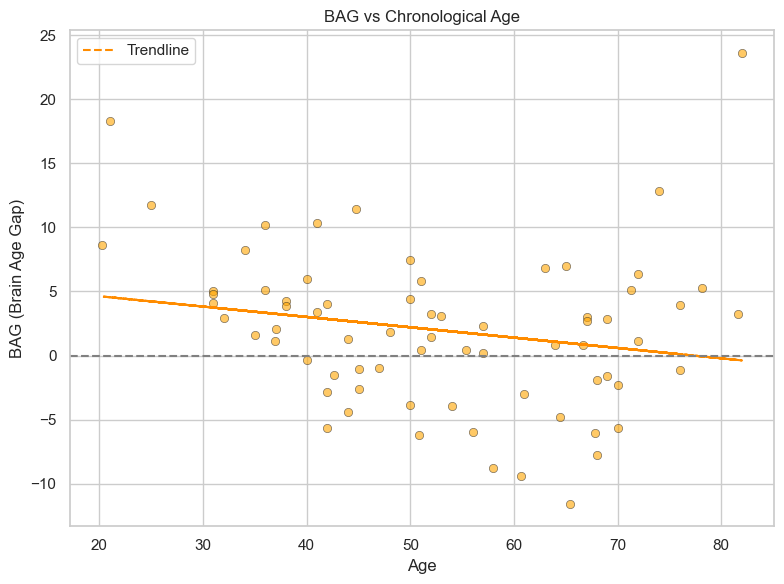

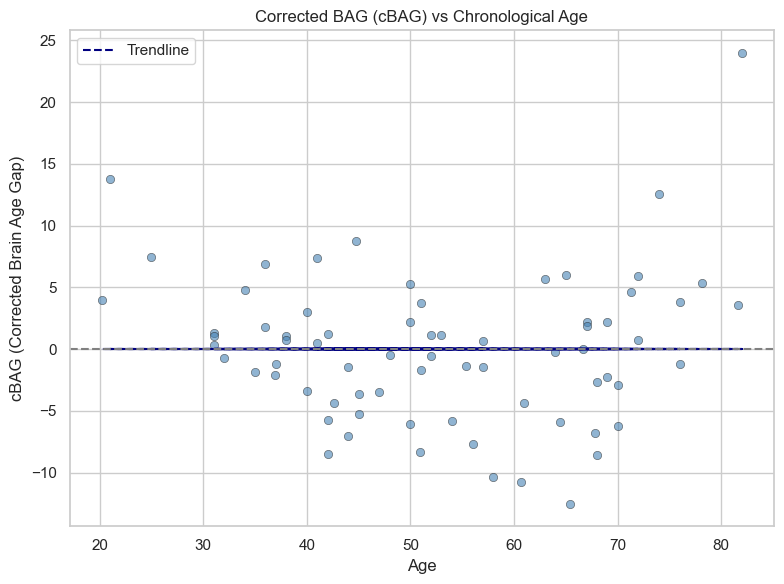

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

# Set plot style
sns.set(style="whitegrid")

# ========================== Plot 1: BAG vs Age ==========================
plt.figure(figsize=(8, 6))

# Scatter plot
sns.scatterplot(x="age", y="BAG", data=df_results, color="orange", alpha=0.6, edgecolor="k")

# Trendline
X_age = df_results["age"].values.reshape(-1, 1)
y_bag = df_results["BAG"].values
reg_bag = LinearRegression().fit(X_age, y_bag)
y_pred_bag = reg_bag.predict(X_age)

plt.plot(df_results["age"], y_pred_bag, color="darkorange", linestyle="--", label="Trendline")

# Labels and style
plt.title("BAG vs Chronological Age")
plt.xlabel("Age")
plt.ylabel("BAG (Brain Age Gap)")
plt.axhline(0, linestyle="--", color="gray")
plt.legend()
plt.tight_layout()
plt.show()

# ========================== Plot 2: cBAG vs Age ==========================
plt.figure(figsize=(8, 6))

# Scatter plot
sns.scatterplot(x="age", y="cBAG", data=df_results, color="steelblue", alpha=0.6, edgecolor="k")

# Trendline
y_cbag = df_results["cBAG"].values
reg_cbag = LinearRegression().fit(X_age, y_cbag)
y_pred_cbag = reg_cbag.predict(X_age)

plt.plot(df_results["age"], y_pred_cbag, color="navy", linestyle="--", label="Trendline")

# Labels and style
plt.title("Corrected BAG (cBAG) vs Chronological Age")
plt.xlabel("Age")
plt.ylabel("cBAG (Corrected Brain Age Gap)")
plt.axhline(0, linestyle="--", color="gray")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
#Metadata
import pandas as pd

# === Paths ===
SUBJECT_IDS_CSV = SUBJECT_IDS_CSV
AGE_CSV = AGE_CSV
METADATA_PATH = METADATA_PATH

# === Load subject IDs and pad to 5 digits ===
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()

# === Load metadata ===
df_metadata = pd.read_excel(METADATA_PATH)

df_metadata["Risk"] = df_metadata["Risk"].fillna("NoRisk")

In [41]:
# Standardize MRI Exam ID column
df_metadata["MRI_Exam_fixed"] = (
    df_metadata["MRI_Exam"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Drop fully empty rows and rows without MRI_Exam
df_metadata_cleaned = df_metadata.dropna(how="all")
df_metadata_cleaned = df_metadata_cleaned.dropna(subset=["MRI_Exam"])

# Filter metadata to only subjects we have columns for
df_matched = df_metadata_cleaned[df_metadata_cleaned["MRI_Exam_fixed"].isin(subject_ids)].copy()

# Optional: reset index
df_matched = df_matched.reset_index(drop=True)

In [42]:
# Merge predicted results with metadata
df_plot = pd.merge(df_results, df_matched, left_on="subject_id", right_on="MRI_Exam_fixed", how="left")

C:\Users\22679\AppData\Local\Temp\ipykernel_48892\2810264676.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="Risk", y="BAG", inner="point", palette="pastel")


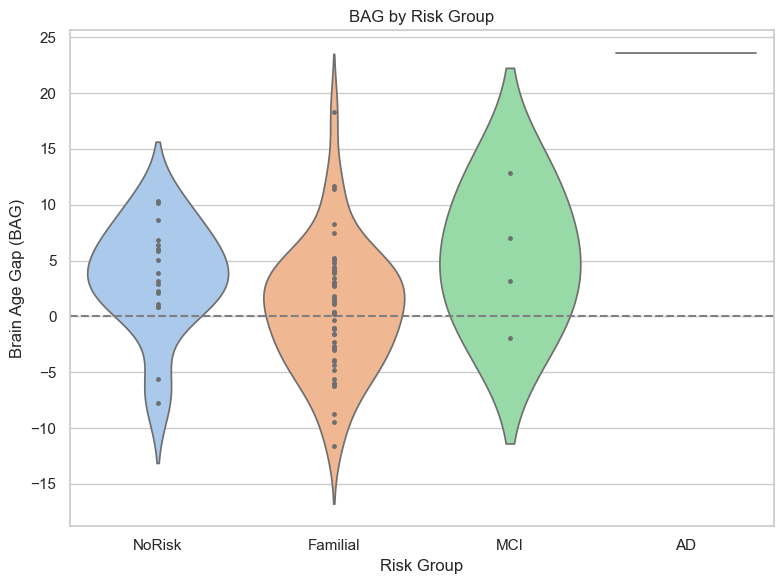

C:\Users\22679\AppData\Local\Temp\ipykernel_48892\2810264676.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="Risk", y="cBAG", inner="point", palette="pastel")


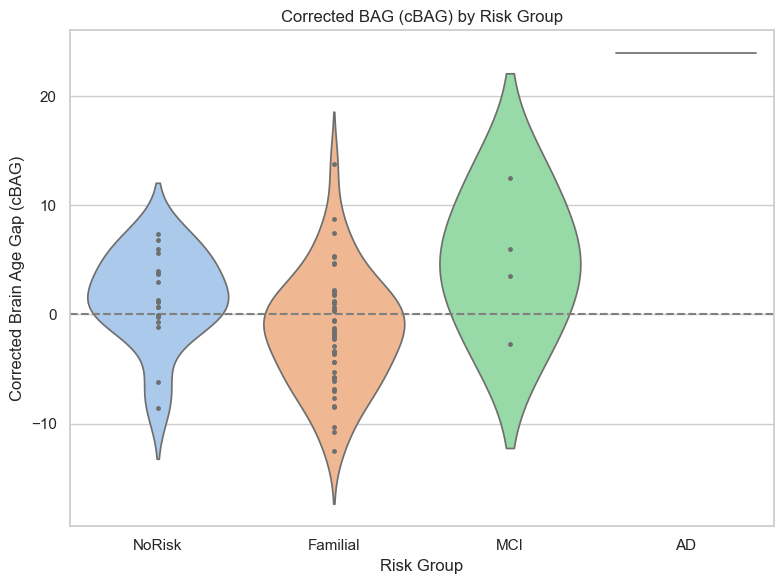

In [43]:
#Violin plots RISK
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# === BAG by Risk group ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="Risk", y="BAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("BAG by Risk Group")
plt.ylabel("Brain Age Gap (BAG)")
plt.xlabel("Risk Group")
plt.tight_layout()
plt.show()

# === cBAG by Risk group ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="Risk", y="cBAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Corrected BAG (cBAG) by Risk Group")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.xlabel("Risk Group")
plt.tight_layout()
plt.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_48892\1917420560.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="genotype", y="BAG", inner="point", palette="muted", order=genotype_order)


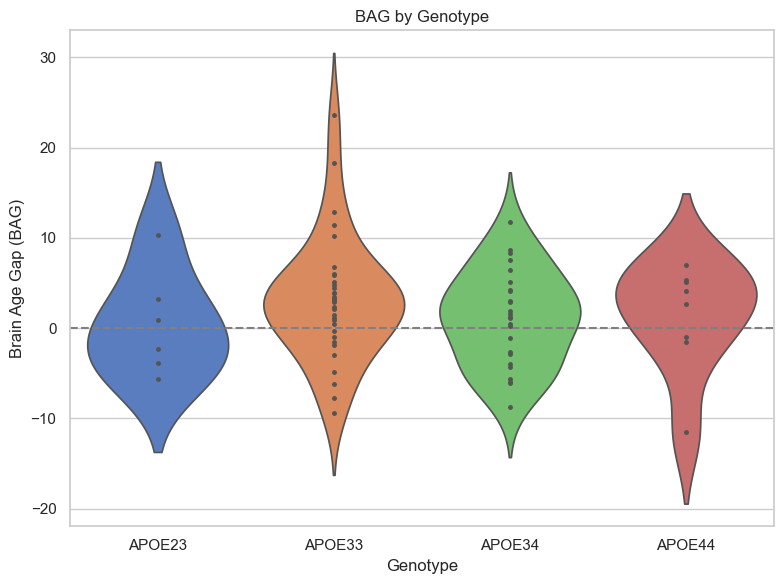

C:\Users\22679\AppData\Local\Temp\ipykernel_48892\1917420560.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="genotype", y="cBAG", inner="point", palette="muted", order=genotype_order)


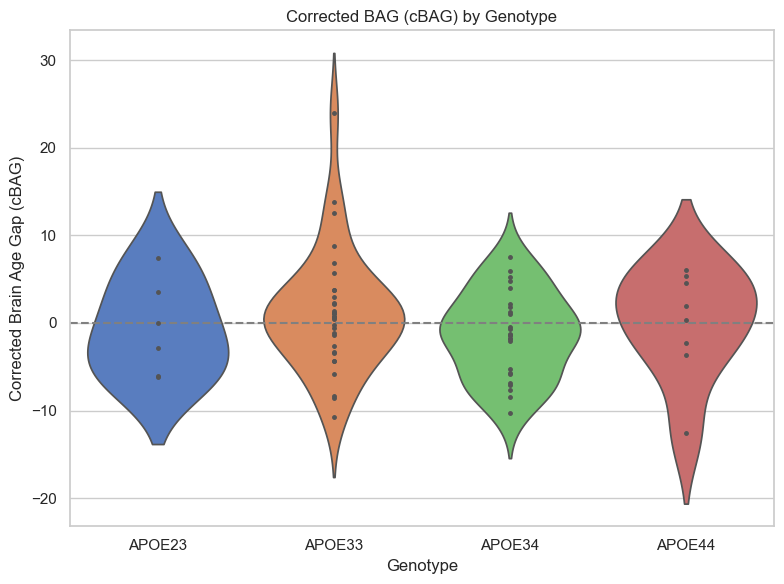

In [44]:
#VIOLIN GENOTYPE
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Define correct APOE genotype order
genotype_order = ["APOE23", "APOE33", "APOE34", "APOE44"]

# === BAG by Genotype (ordered) ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="genotype", y="BAG", inner="point", palette="muted", order=genotype_order)
plt.axhline(0, linestyle="--", color="gray")
plt.title("BAG by Genotype")
plt.xlabel("Genotype")
plt.ylabel("Brain Age Gap (BAG)")
plt.tight_layout()
plt.show()

# === cBAG by Genotype (ordered) ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="genotype", y="cBAG", inner="point", palette="muted", order=genotype_order)
plt.axhline(0, linestyle="--", color="gray")
plt.title("Corrected BAG (cBAG) by Genotype")
plt.xlabel("Genotype")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.tight_layout()
plt.show()

C:\Users\22679\AppData\Local\Temp\ipykernel_48892\1921486781.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="APOE", y="BAG", inner="point", palette="pastel")


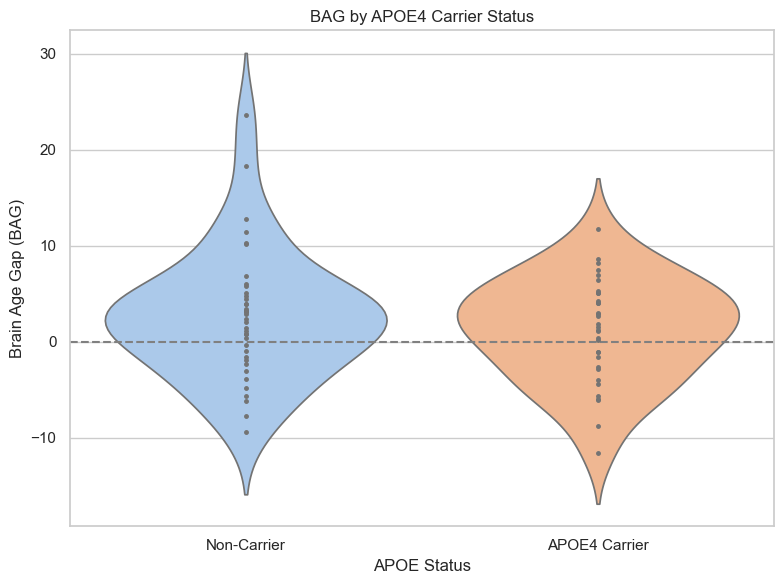

C:\Users\22679\AppData\Local\Temp\ipykernel_48892\1921486781.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="APOE", y="cBAG", inner="point", palette="pastel")


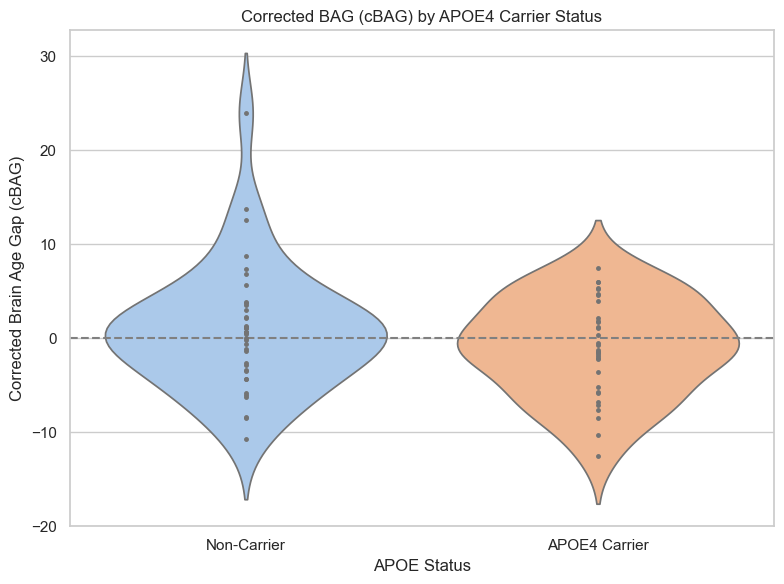

In [45]:
#Violin genotype 4+ or 4-
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Define new APOE status based on genotype
def define_apoe_status(genotype):
    if "4" in genotype:
        return "APOE4 Carrier"
    else:
        return "Non-Carrier"
# Apply the function to create a new column
df_plot["APOE"] = df_plot["genotype"].apply(define_apoe_status)

# === BAG by APOE status ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="APOE", y="BAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("BAG by APOE4 Carrier Status")
plt.xlabel("APOE Status")
plt.ylabel("Brain Age Gap (BAG)")
plt.tight_layout()
plt.show()

# === cBAG by APOE status ===
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_plot, x="APOE", y="cBAG", inner="point", palette="pastel")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Corrected BAG (cBAG) by APOE4 Carrier Status")
plt.xlabel("APOE Status")
plt.ylabel("Corrected Brain Age Gap (cBAG)")
plt.tight_layout()
plt.show()

# Saliency compuation

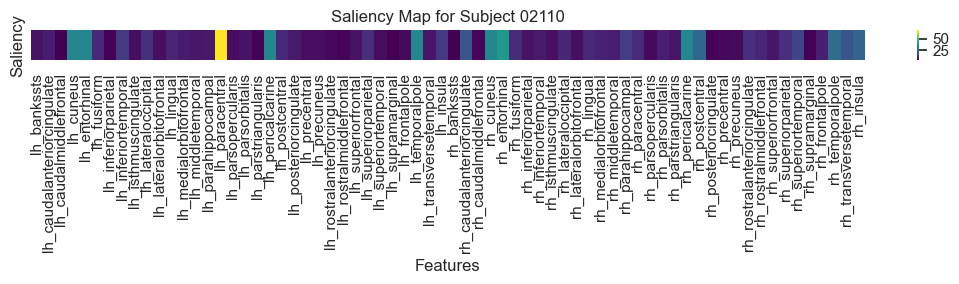

In [46]:
# Saliency maps
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances


# === Function to compute saliency maps ===

def compute_saliency_map(model, data, target_class=None):
    """
    Computes the saliency map for a given graph data. (region)

    Args:
        model (torch.nn.Module): Trained model.
        data (torch_geometric.data.Data): Graph data.
        target_class (int, optional): Class index to compute saliency for. If None, uses the model's output.

    Returns:
        saliency_map (np.ndarray): Saliency map for the graph.
    """
    # Set model to evaluation mode
    model.eval()

    # Forward pass
    data = data.to(device)
    output = model(data)

    # If target_class is not provided, use the model's output
    if target_class is None:
        target_class = output.argmax(dim=0).item()

    # Zero gradients
    model.zero_grad()

    # Backward pass to compute gradients
    output[0].backward()

    # Get gradients and convert to numpy
    gradients = data.x.grad.cpu().numpy()
    saliency_map = np.abs(gradients).sum(axis=1)  # Sum gradients across features

    return saliency_map

def compute_saliency_map_by_layer(model, data, target_class=None):
    """
    Computes the saliency map for a given graph data. (region)

    Args:
        model (torch.nn.Module): Trained model.
        data (torch_geometric.data.Data): Graph data.
        target_class (int, optional): Class index to compute saliency for. If None, uses the model's output.

    Returns:
        saliency_map (np.ndarray): Saliency map for the graph.
    """
    # Set model to evaluation mode
    model.eval()

    # Forward pass
    data = data.to(device)
    output = model(data)

    # If target_class is not provided, use the model's output
    if target_class is None:
        target_class = output.argmax(dim=0).item()

    # Zero gradients
    model.zero_grad()

    # Backward pass to compute gradients
    output[0].backward()

    # Get gradients and convert to numpy
    gradients = data.x.grad.cpu().numpy()
    saliency_map = np.abs(gradients)

    return saliency_map

# === Function to visualize saliency map ===
def visualize_saliency_map(saliency_map, title="Saliency Map"):
    """
    Visualizes the saliency map as a heatmap.

    Args:
        saliency_map (np.ndarray): Saliency map to visualize.
        title (str, optional): Title of the plot.
    """
    xlabel = []
    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            xlabel.append(region_key)
    plt.figure(figsize=(max(8, len(saliency_map) // 6), 3))
    ax = sns.heatmap(saliency_map.reshape(1, -1), cmap="viridis", cbar=True, 
                     xticklabels=xlabel, yticklabels=False)
    ax.set_xticks(np.arange(len(xlabel)) + 0.5)
    ax.set_xticklabels(xlabel, rotation=90, ha='center')
    plt.title(title)
    plt.xlabel("Features")
    plt.ylabel("Saliency")
    plt.tight_layout()
    plt.show()

# === Function to visualize saliency map with PCA ===
def visualize_saliency_map_pca(saliency_map, title="Saliency Map (PCA)"):
    """
    Visualizes the saliency map after applying PCA.

    Args:
        saliency_map (np.ndarray): Saliency map to visualize.
        title (str, optional): Title of the plot.
    """
    # Apply PCA to reduce dimensionality
    pca = PCA(n_components=2)
    saliency_map_pca = pca.fit_transform(saliency_map.reshape(-1, 1))

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=saliency_map_pca[:, 0], y=saliency_map_pca[:, 1], cmap="viridis")
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.tight_layout()
    plt.show()
# Choose a subject's graph
subject_graph = graph_data_list_all[0]  # Replace with the desired subject's graph
subject_graph = subject_graph.to(device)  # Move to device
subject_graph.x.requires_grad = True  # Enable gradients for features
# Compute saliency map
saliency_map = compute_saliency_map(model, subject_graph)
# Visualize saliency map
visualize_saliency_map(saliency_map, title="Saliency Map for Subject " + str(subject_graph.subject_id))


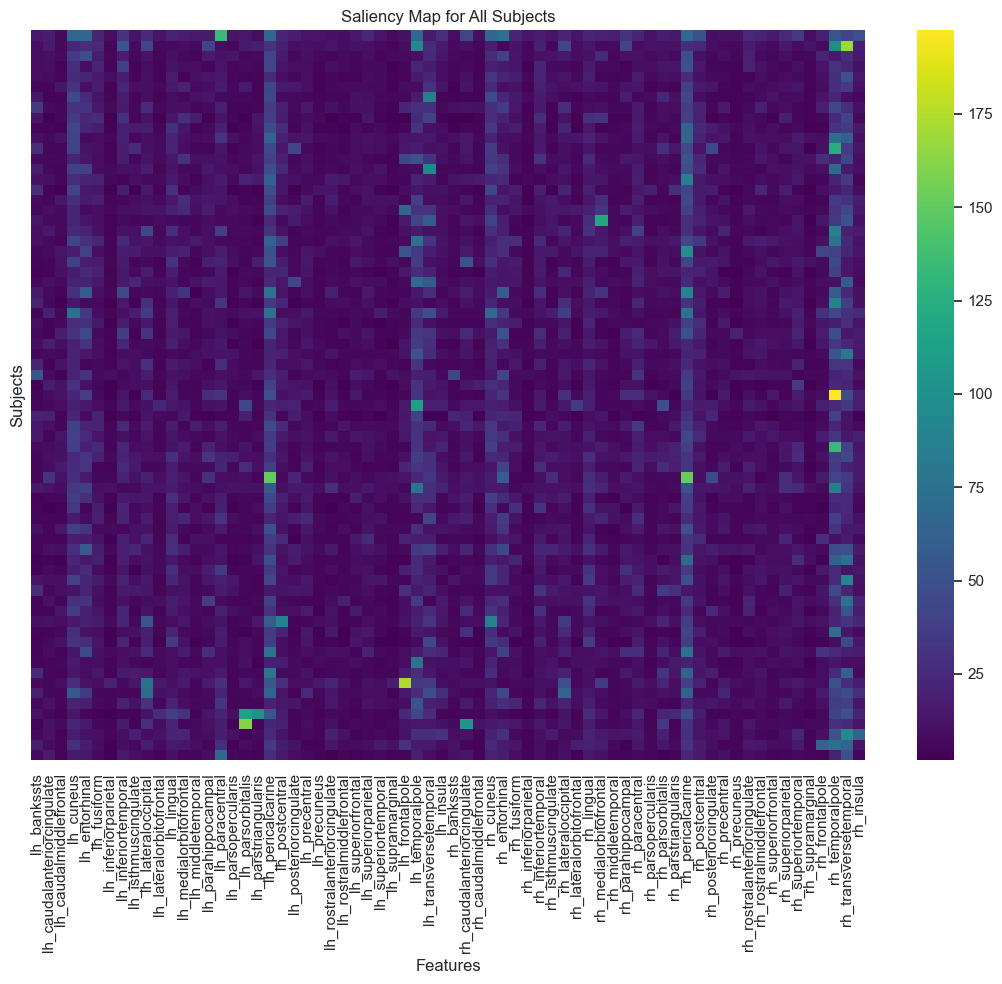

In [47]:
# Plot the saliency map of all subjects stacked
saliency_maps_all = []
for graph in graph_data_list_all:
    graph = graph.to(device)
    graph.x.requires_grad = True
    saliency_map = compute_saliency_map(model, graph)
    saliency_maps_all.append(saliency_map)

# Convert to numpy array
saliency_maps_all = np.array(saliency_maps_all)
# Visualize saliency map for all subjects
xlabel = []
for hemi in HEMIS:
    for region in REGION_NAMES:
        region_key = f"{hemi}_{region}"
        xlabel.append(region_key)
plt.figure(figsize=(max(8, len(saliency_maps_all) // 6),10))  # Adjust figure size based on number of subjects
ax = sns.heatmap(saliency_maps_all, cmap="viridis", cbar=True,
                    xticklabels=xlabel, yticklabels=False)
ax.set_xticks(np.arange(len(xlabel)) + 0.5)
ax.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("Saliency Map for All Subjects")
plt.xlabel("Features")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()


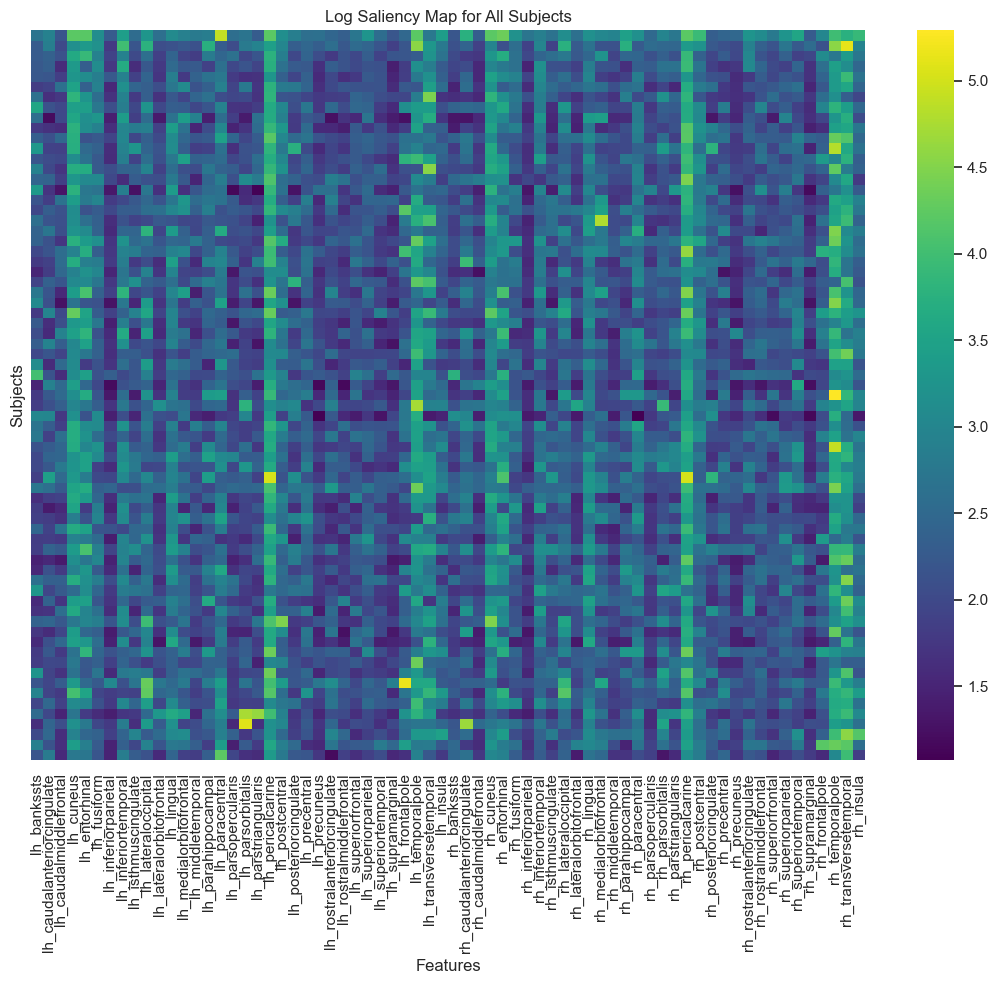

In [48]:
# Plot the log saliency map
saliency_maps_all_log = np.log1p(saliency_maps_all)  # Apply log transformation
plt.figure(figsize=(max(8, len(saliency_maps_all_log) // 6), 10))  # Adjust figure size based on number of subjects
ax = sns.heatmap(saliency_maps_all_log, cmap="viridis", cbar=True,
                    xticklabels=xlabel, yticklabels=False)
ax.set_xticks(np.arange(len(xlabel)) + 0.5)
ax.set_xticklabels(xlabel, rotation=90, ha='center')
plt.title("Log Saliency Map for All Subjects")
plt.xlabel("Features")
plt.ylabel("Subjects")
plt.tight_layout()
plt.show()

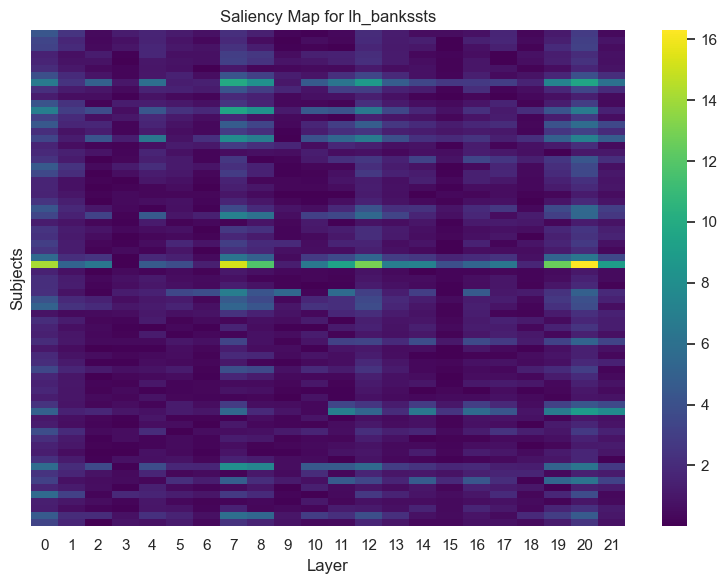

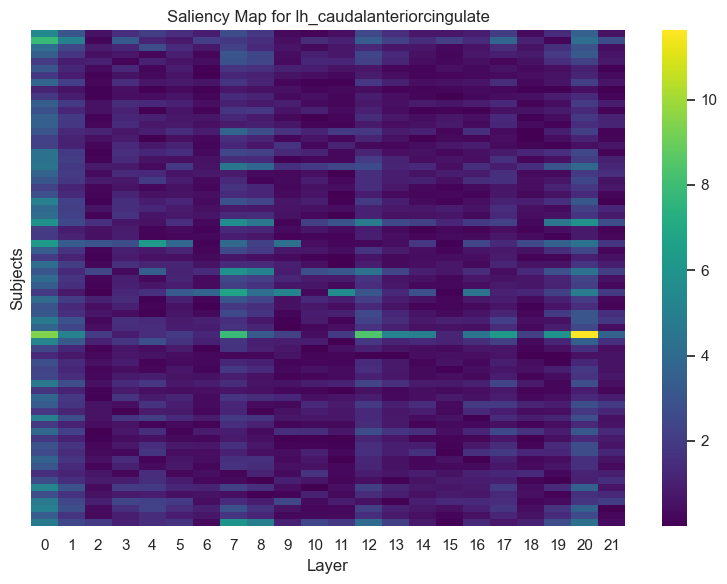

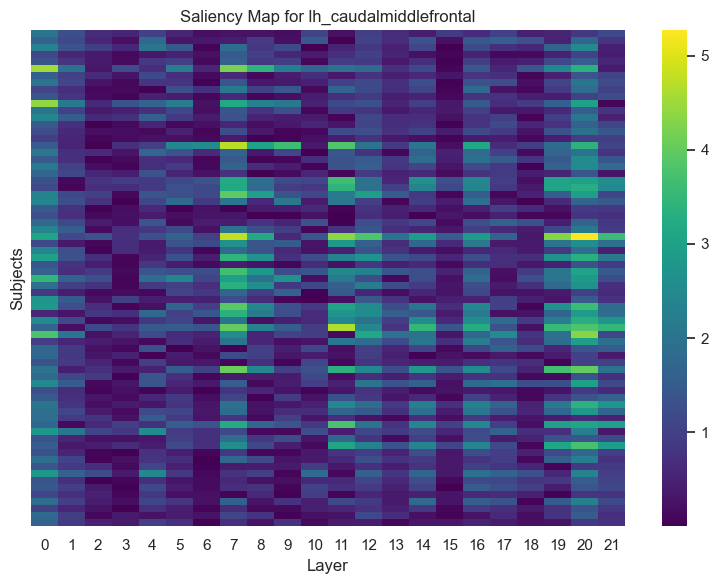

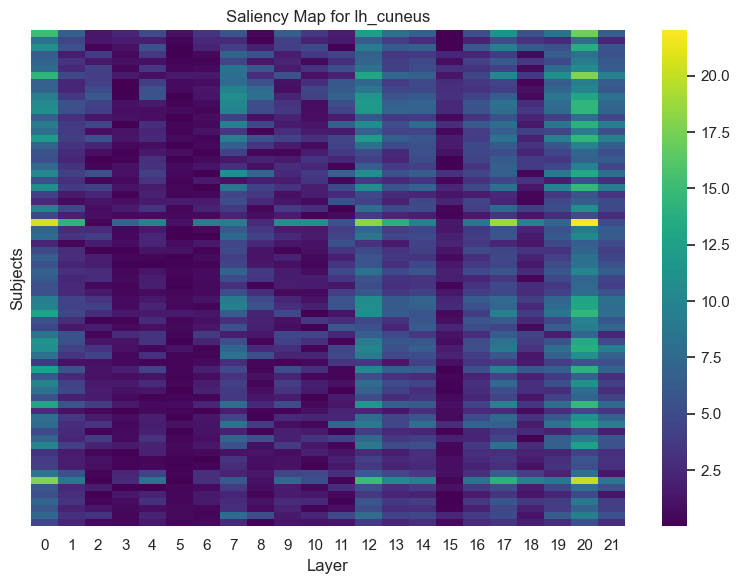

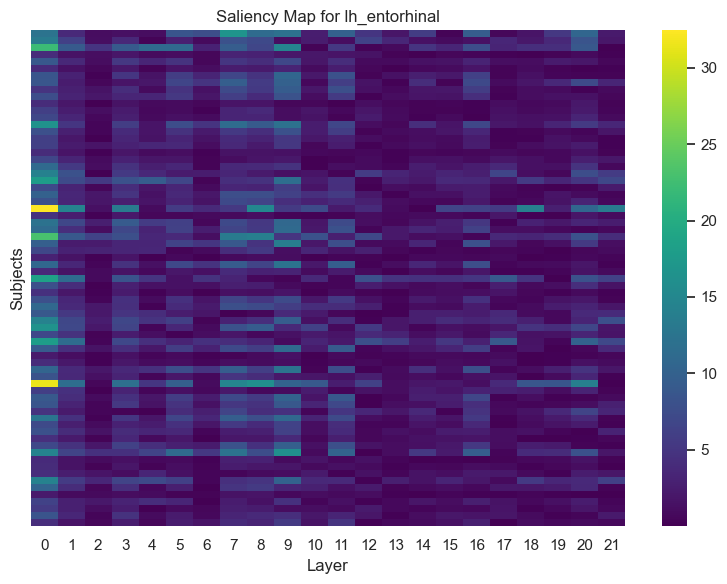

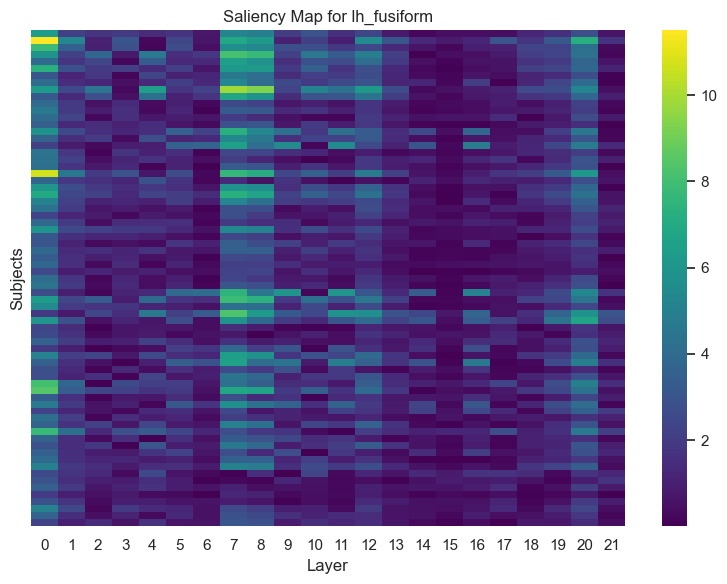

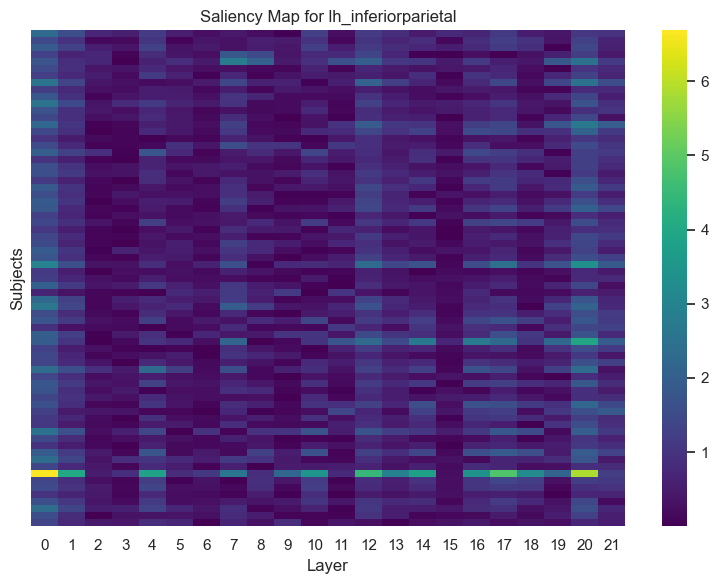

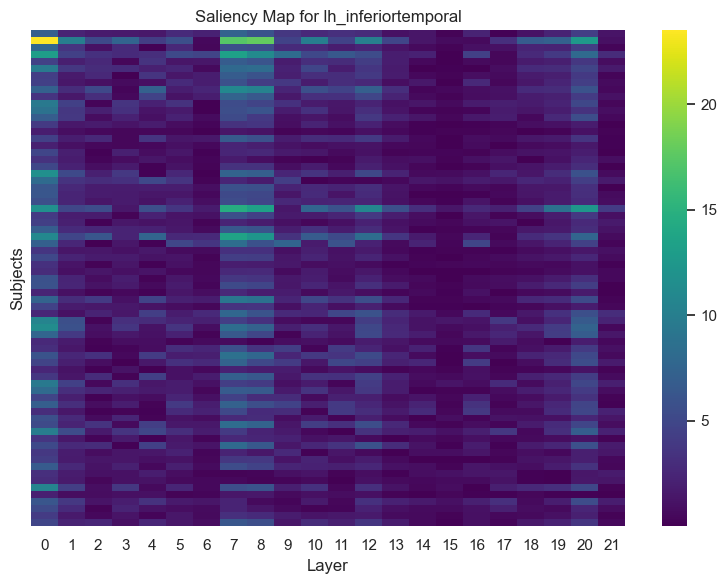

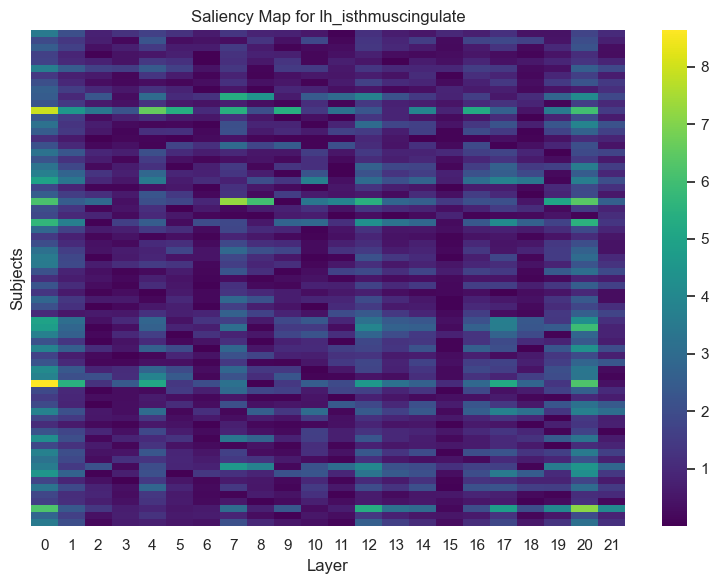

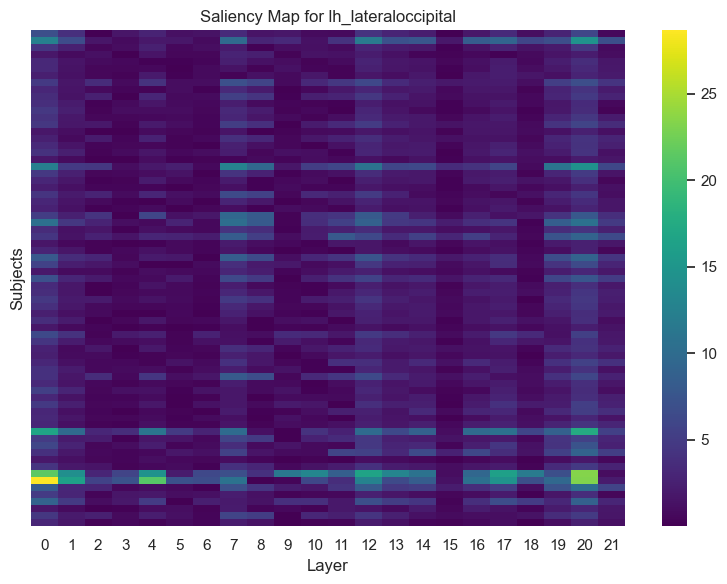

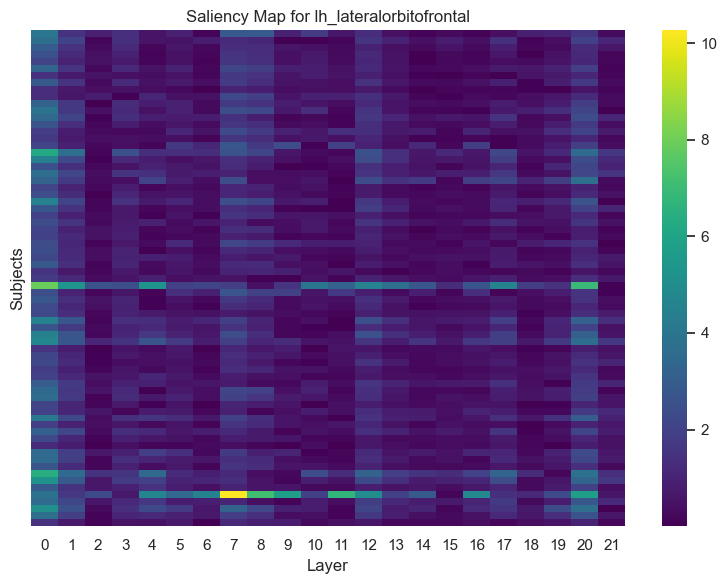

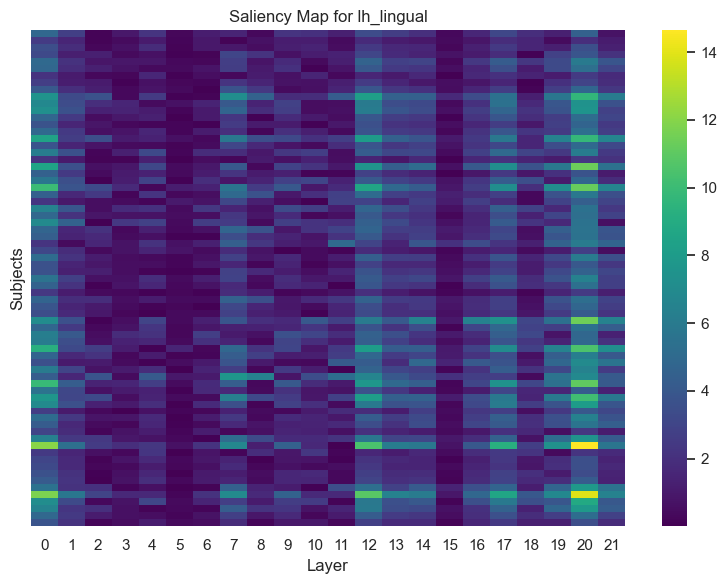

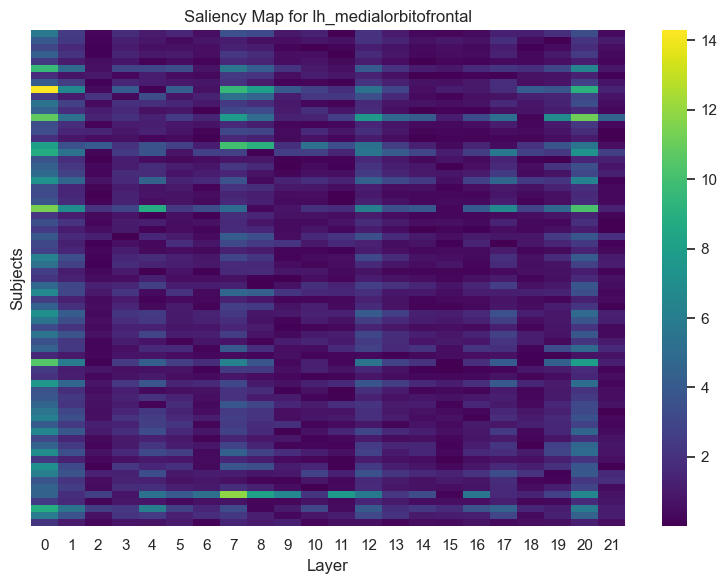

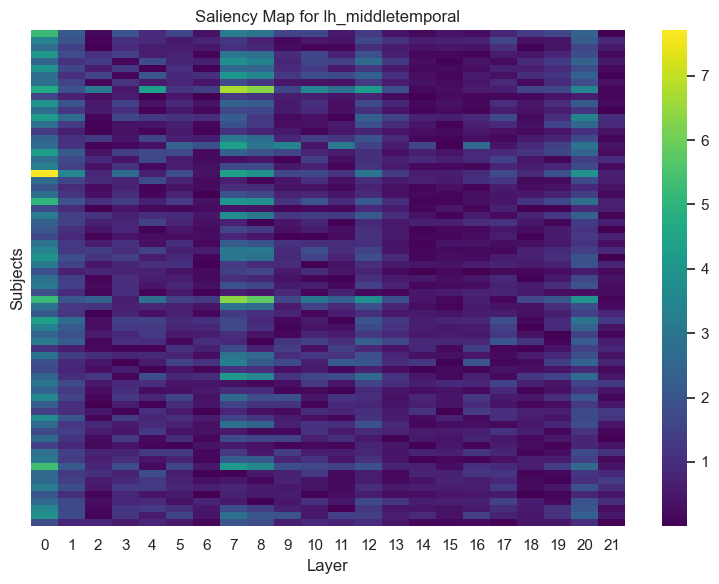

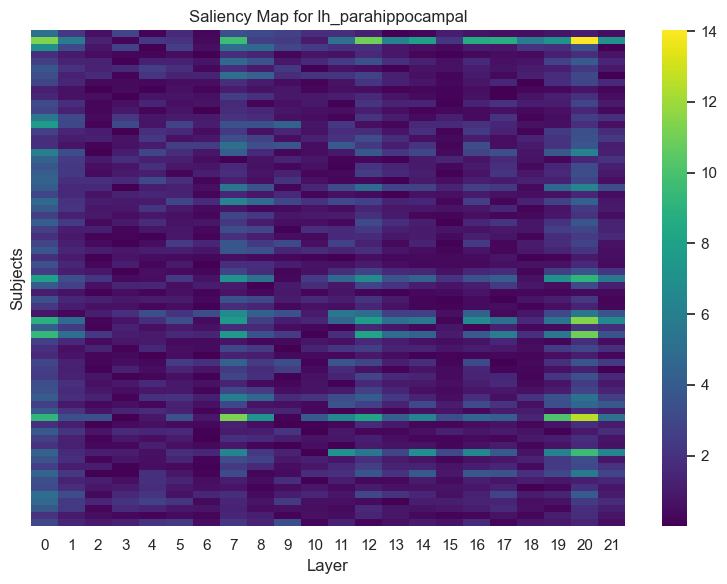

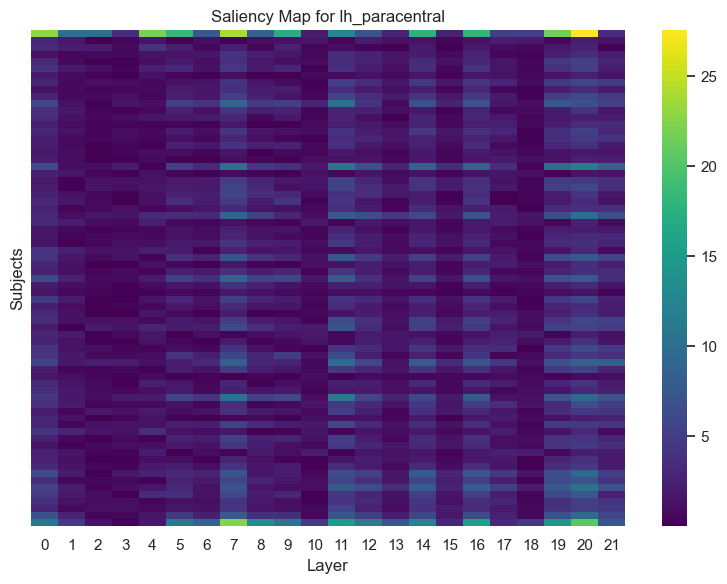

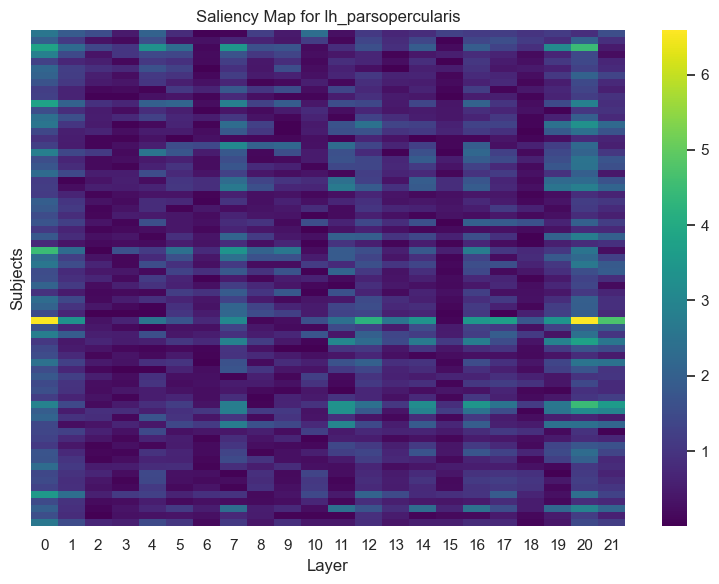

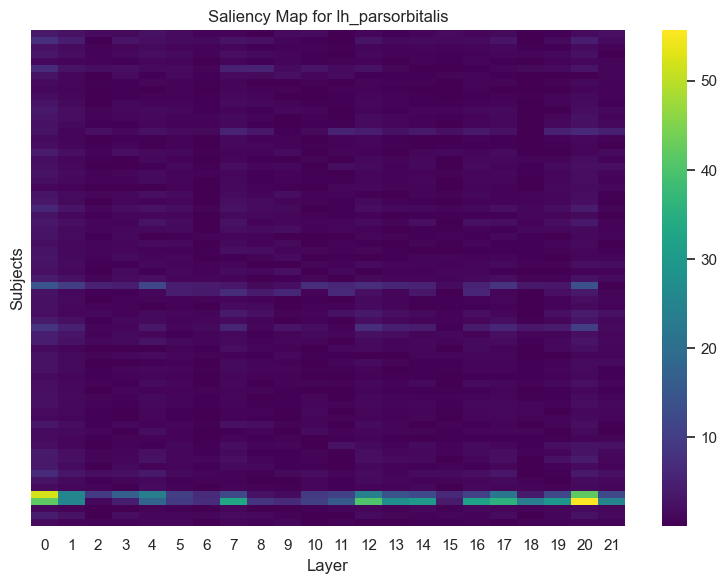

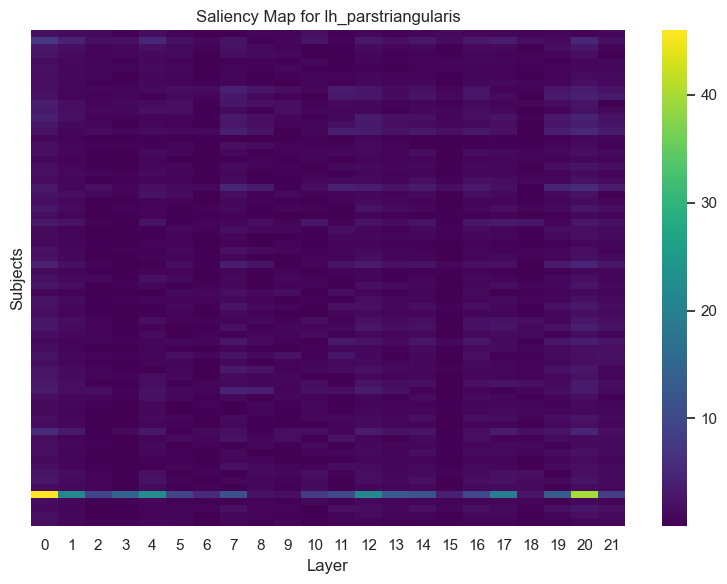

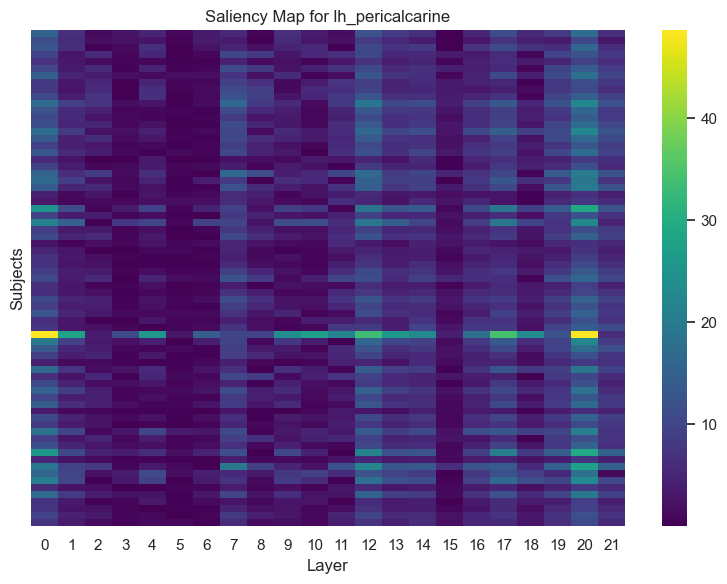

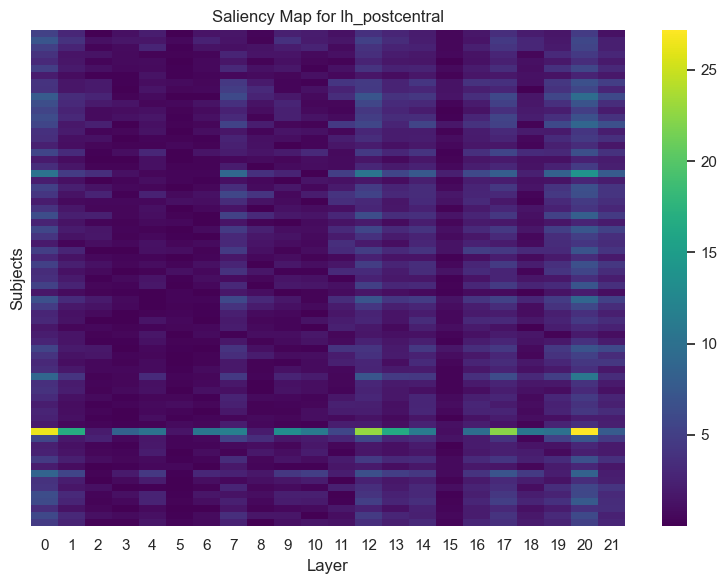

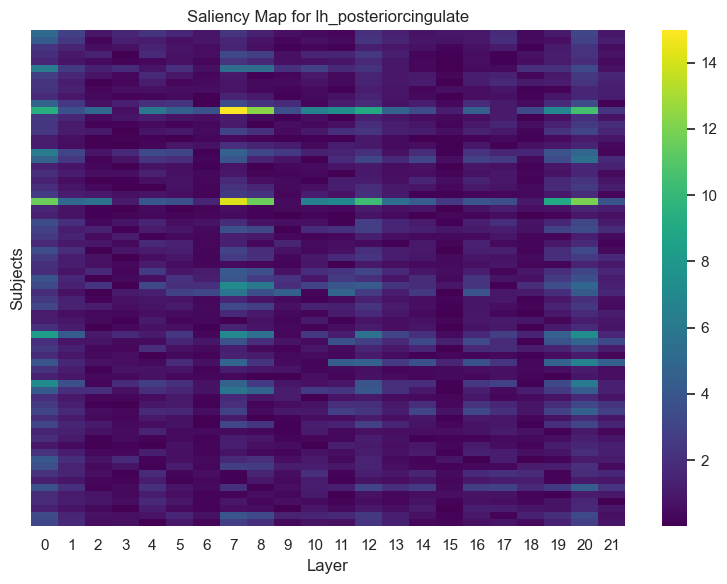

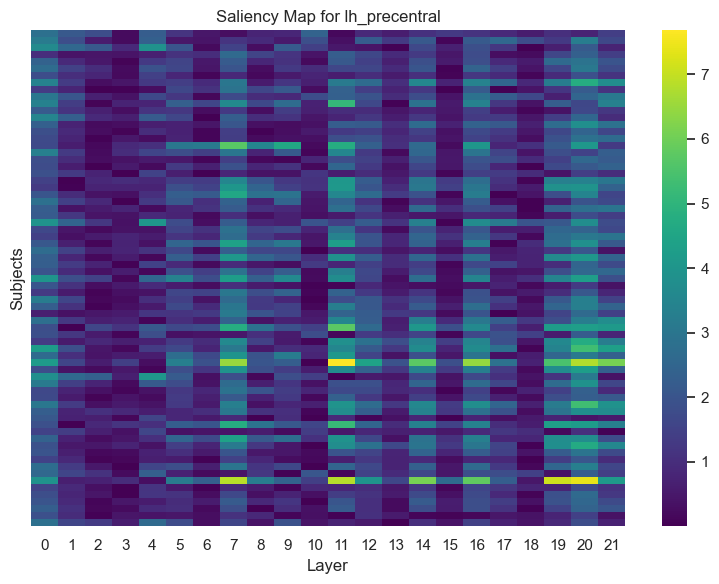

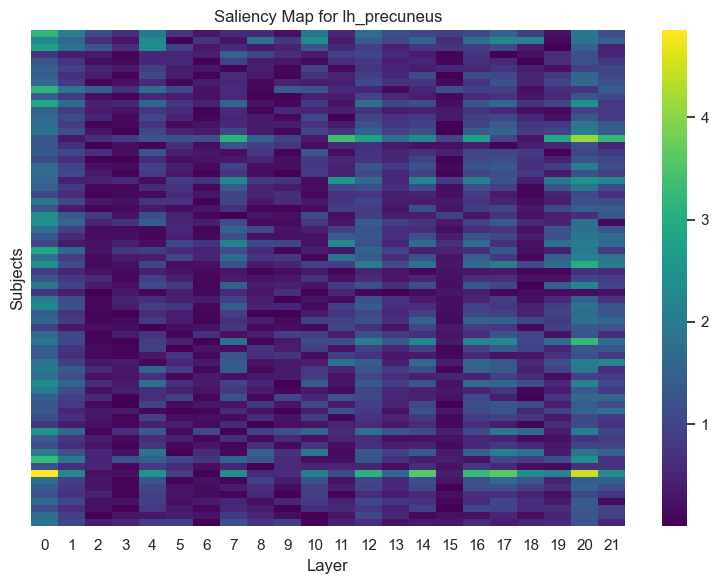

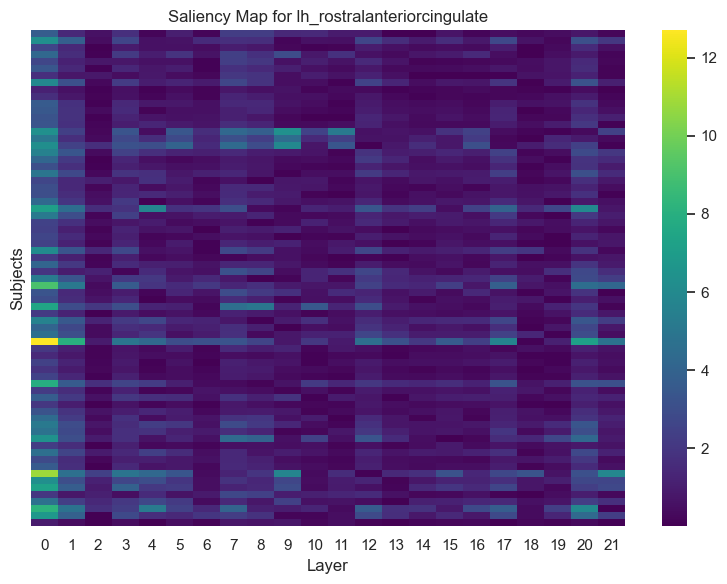

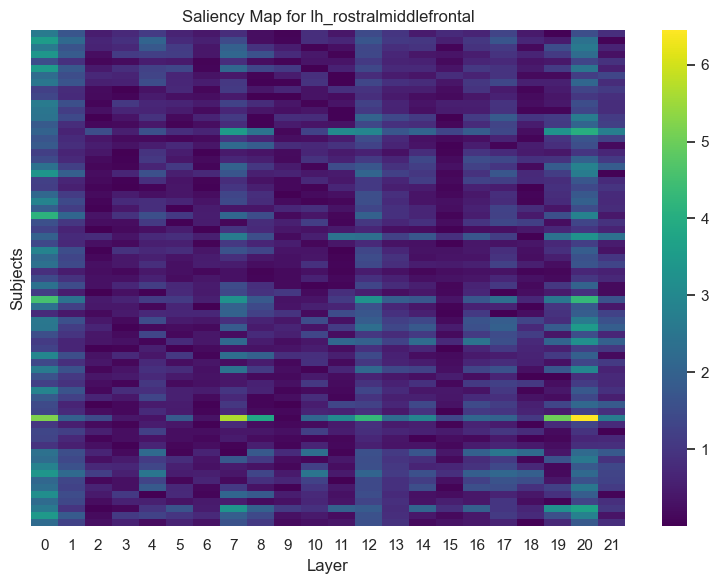

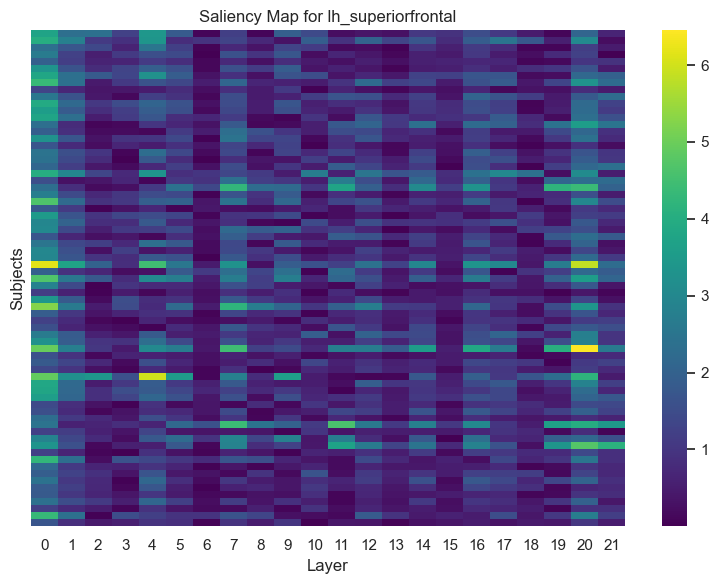

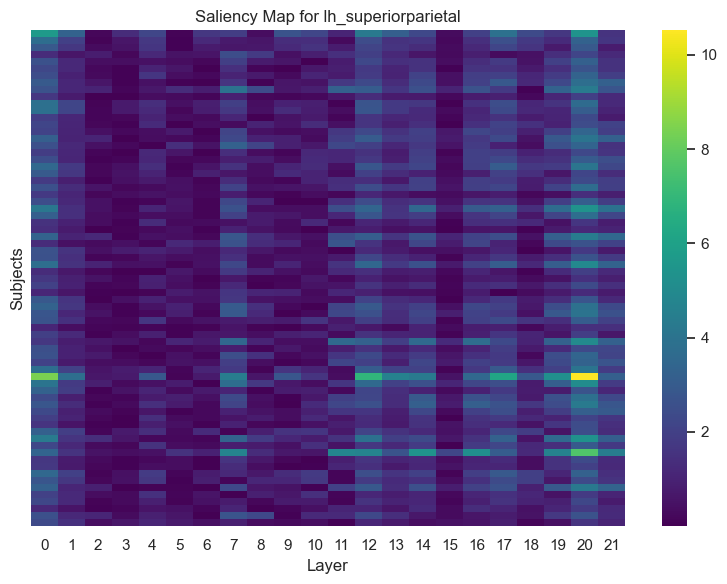

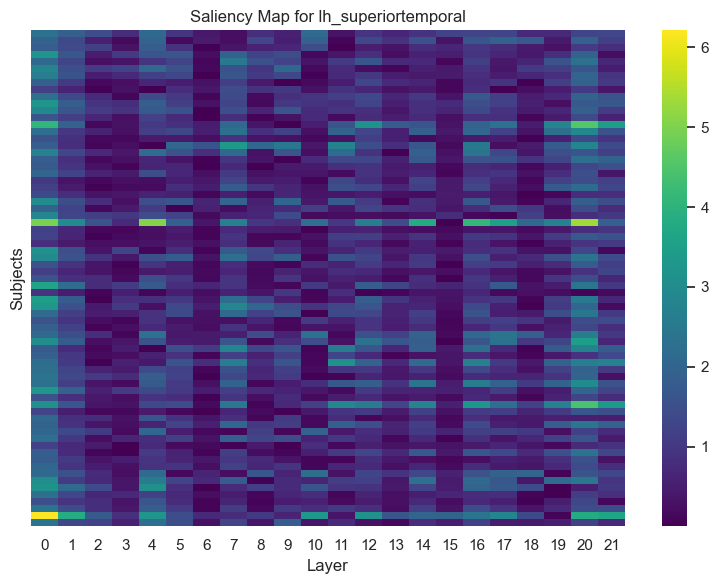

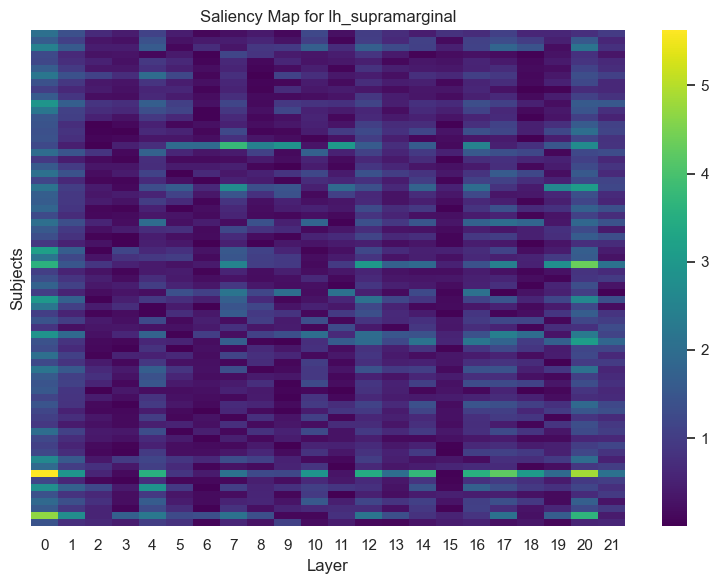

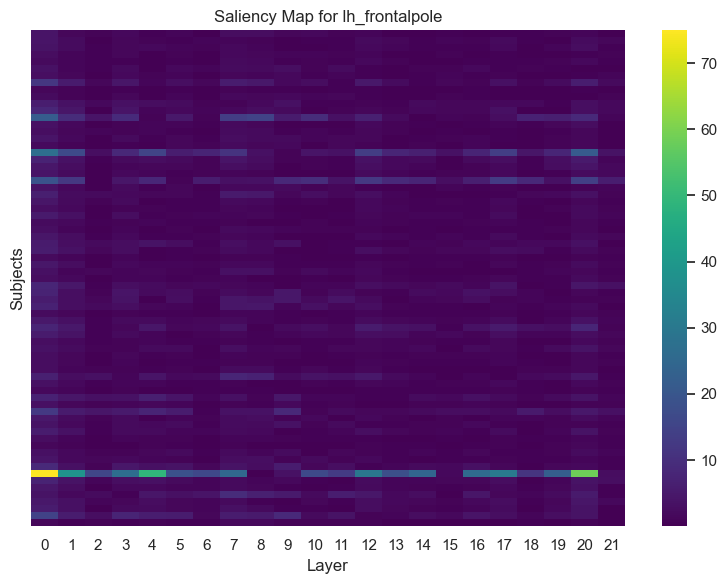

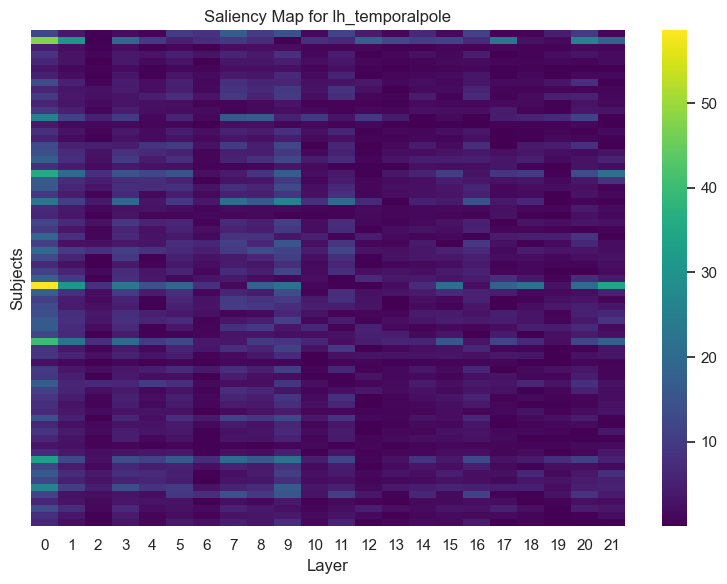

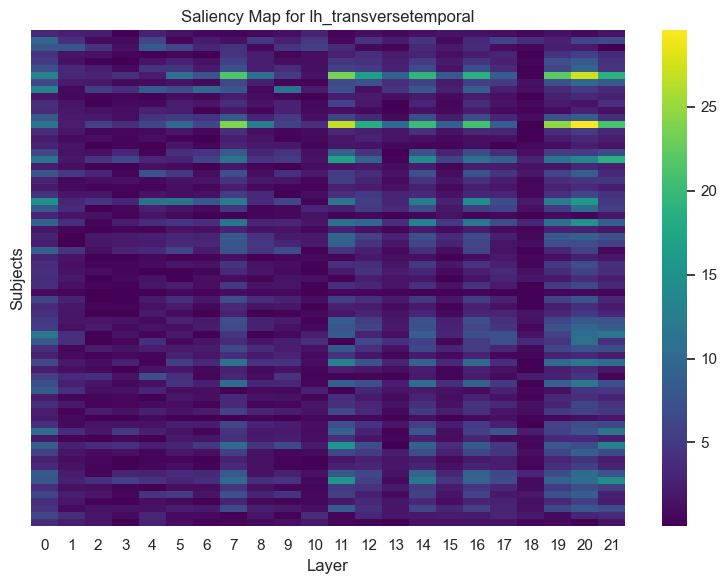

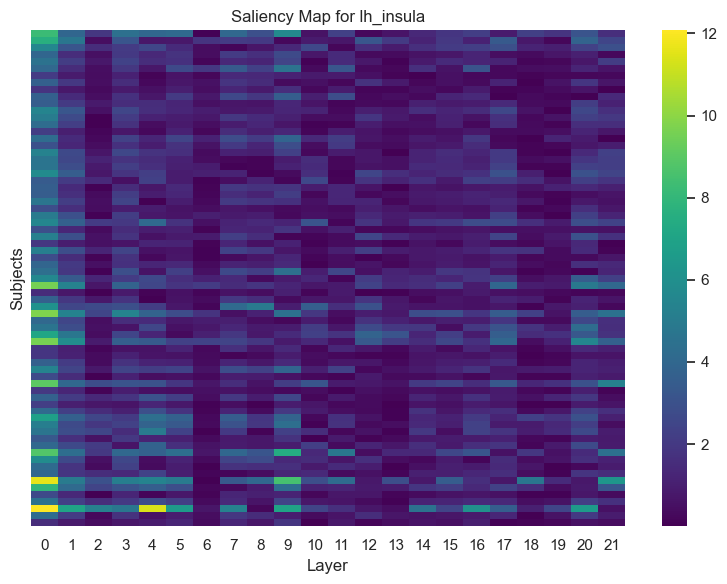

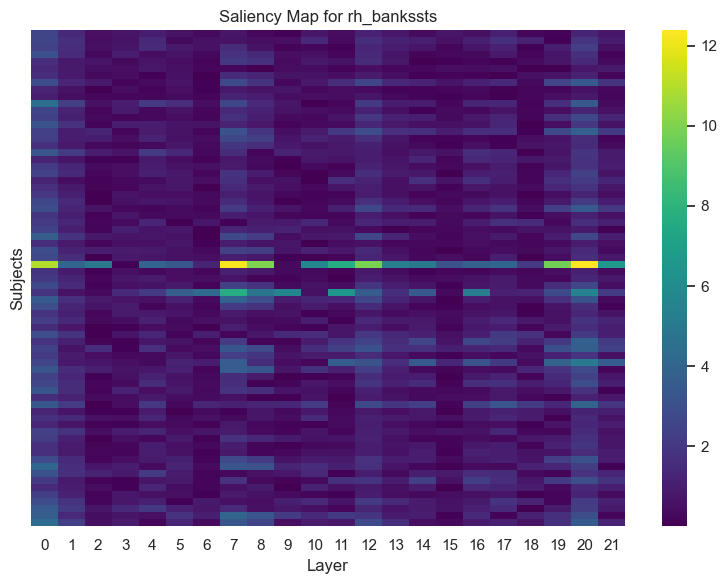

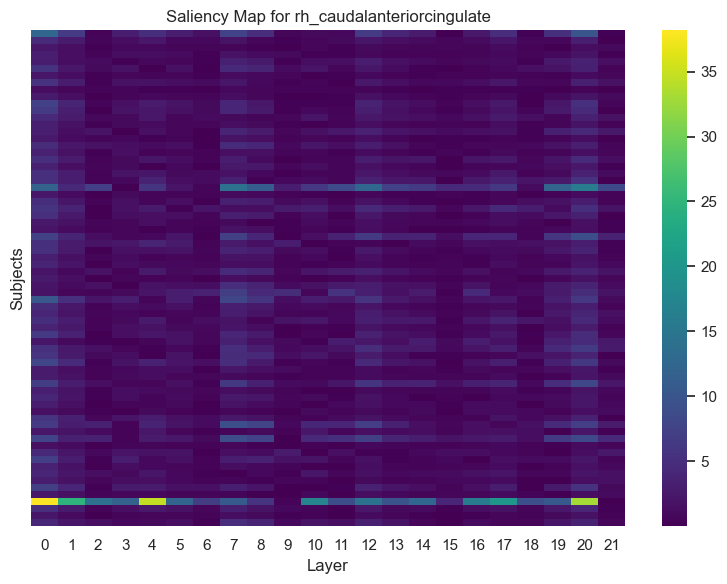

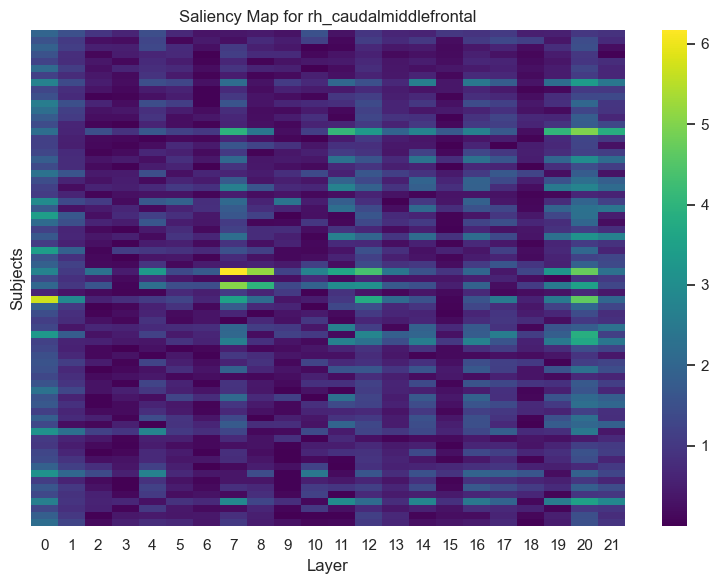

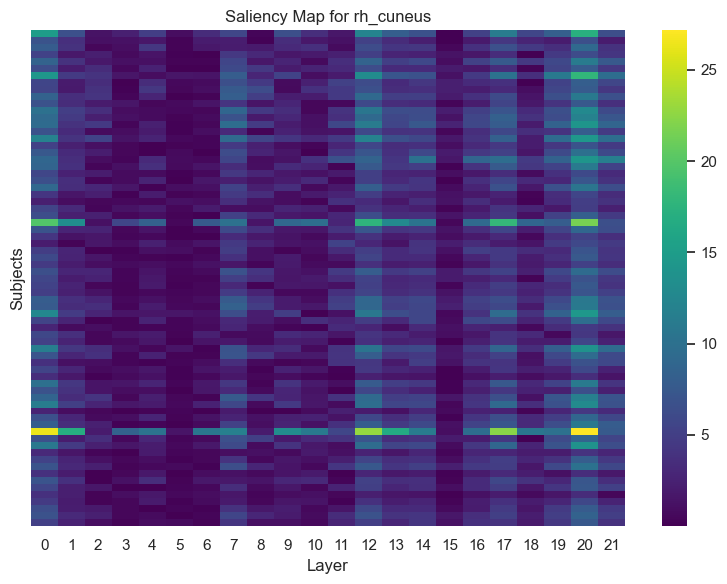

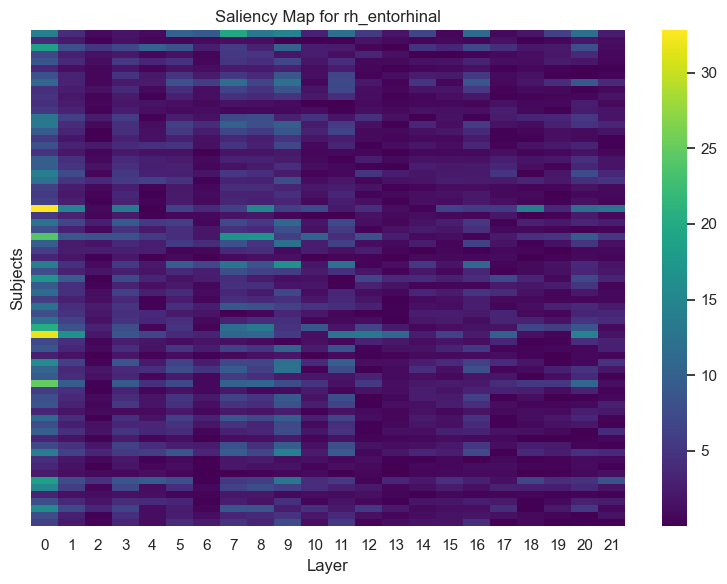

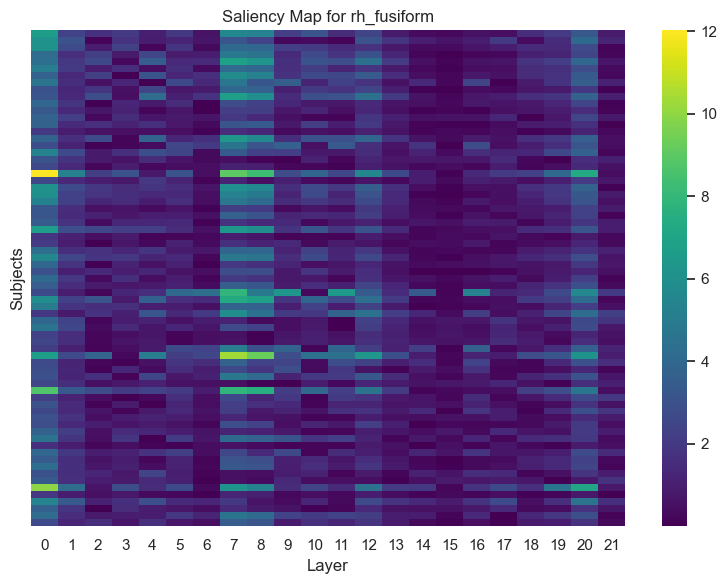

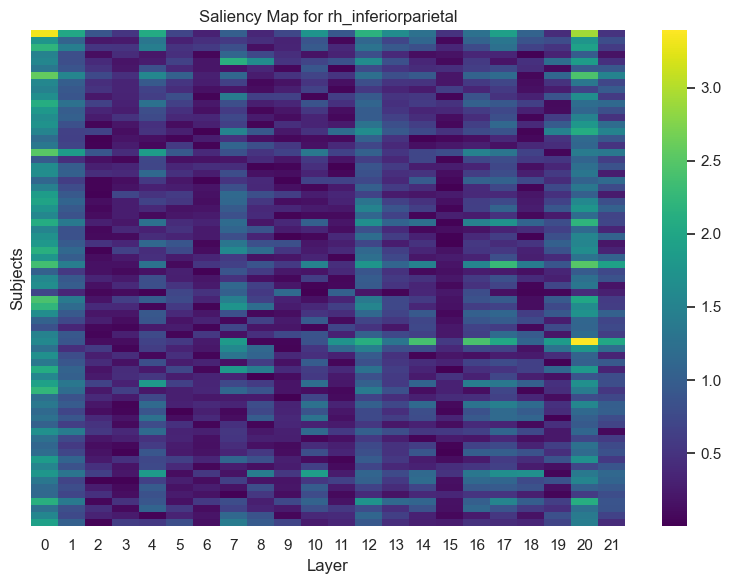

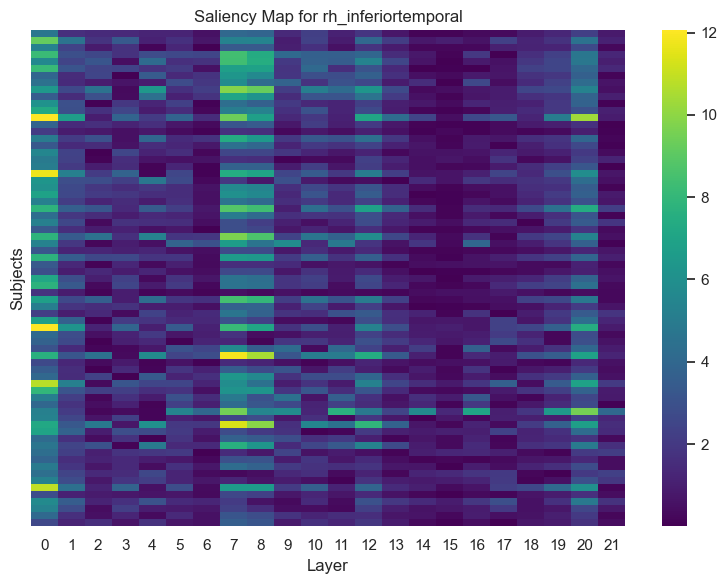

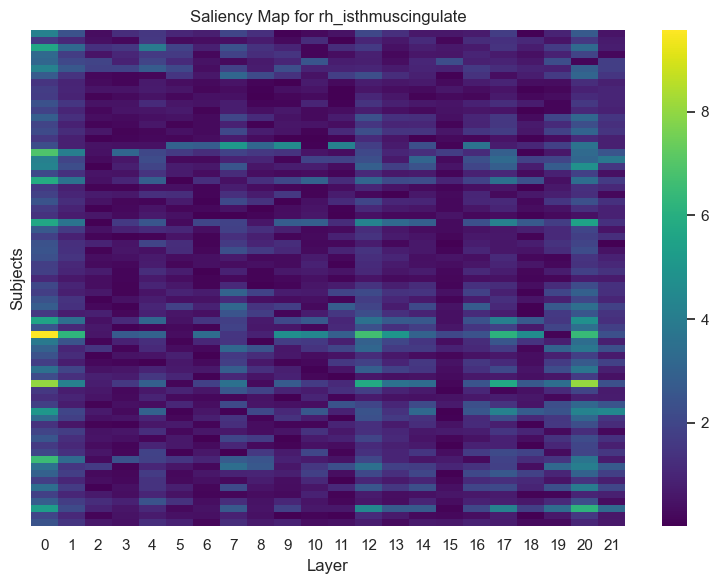

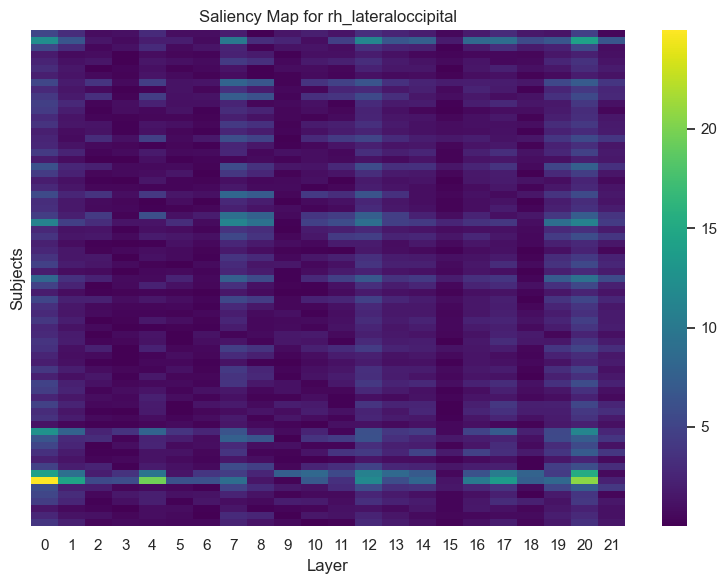

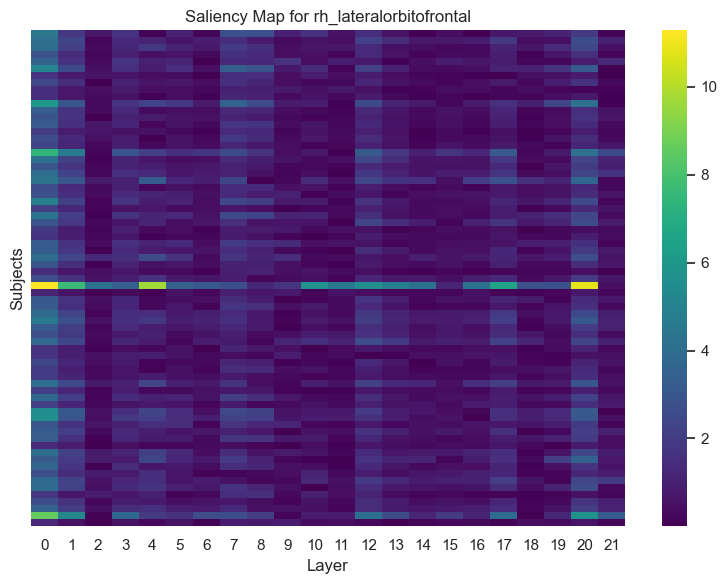

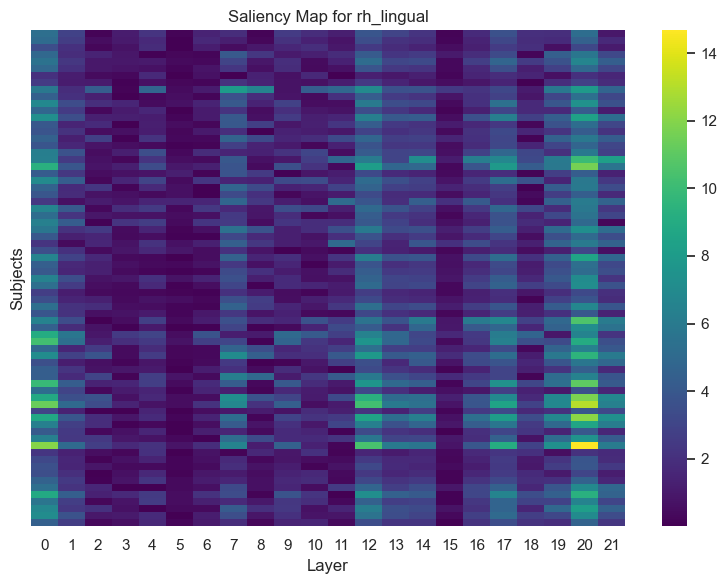

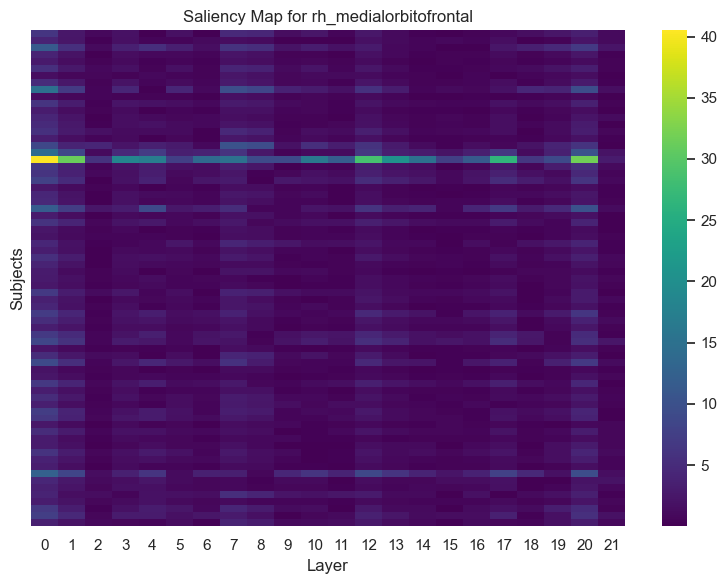

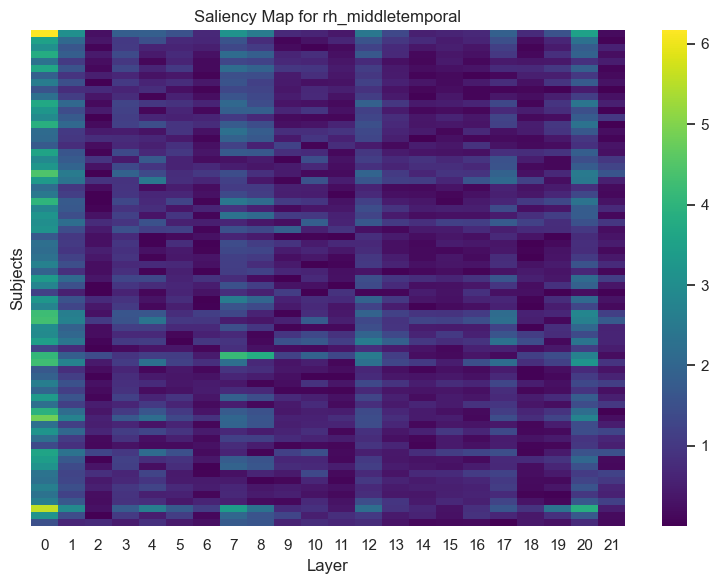

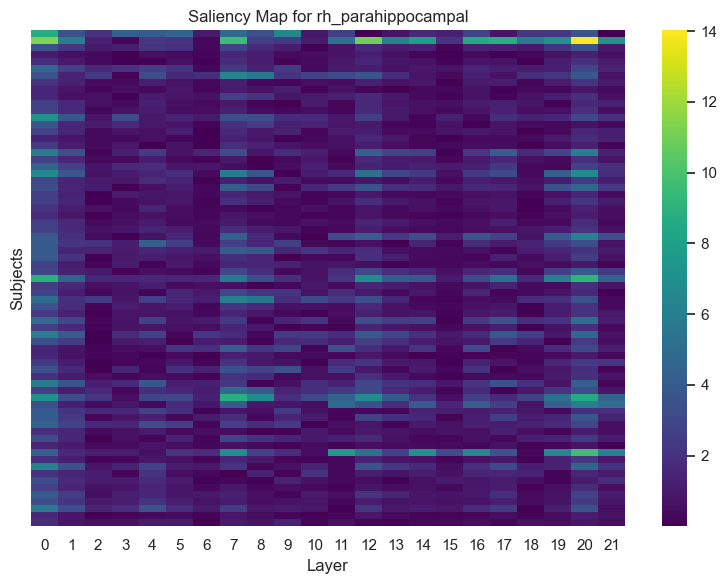

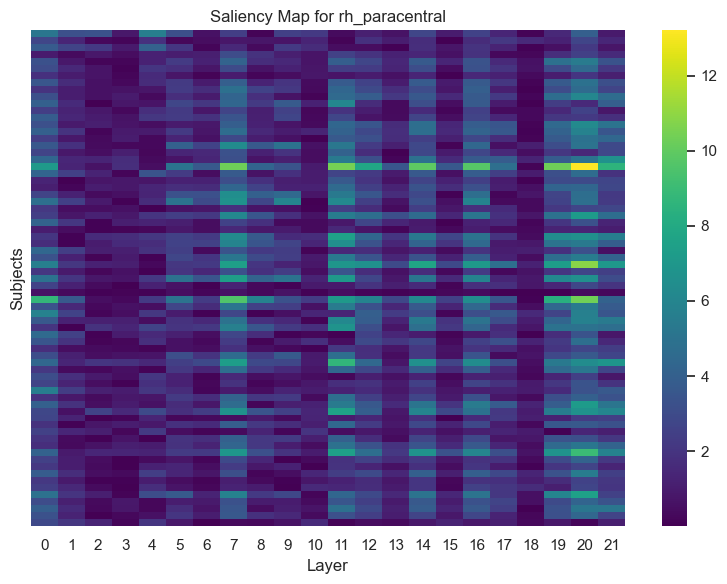

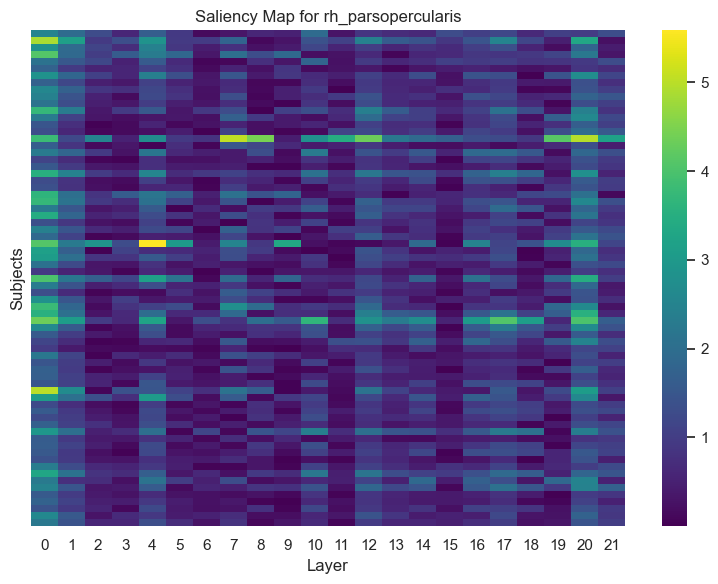

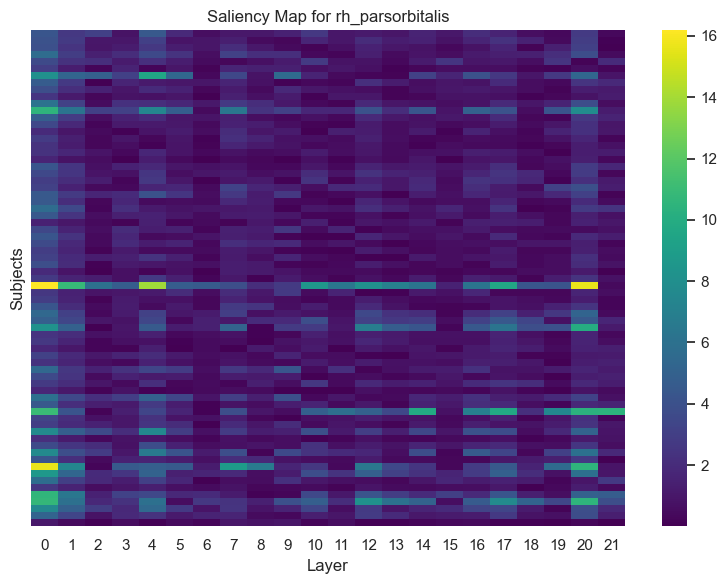

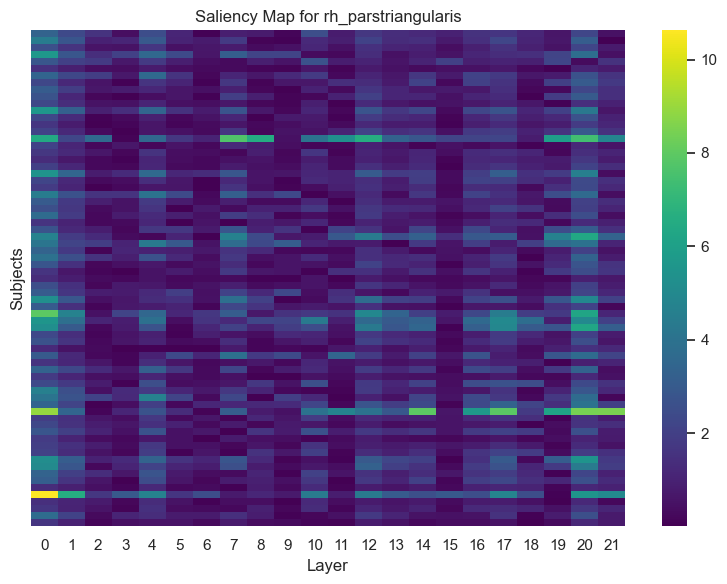

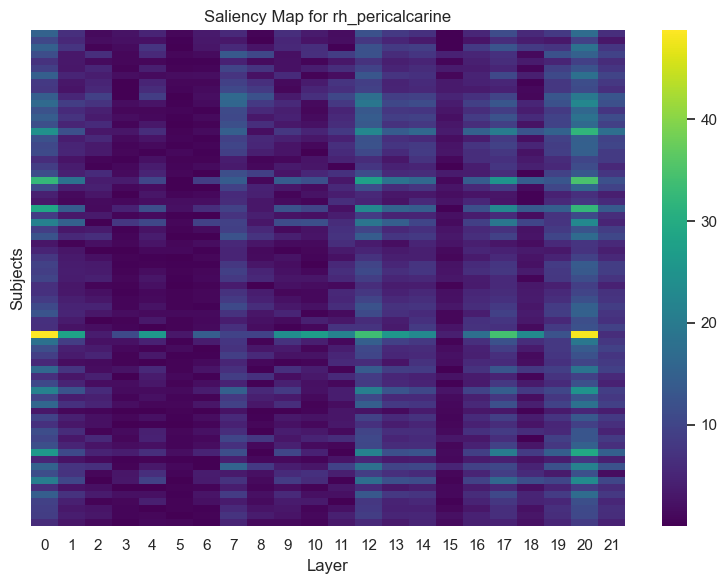

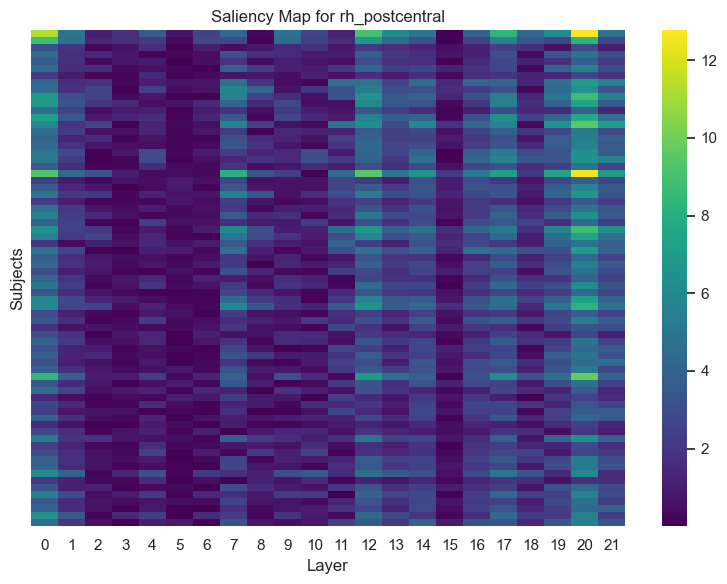

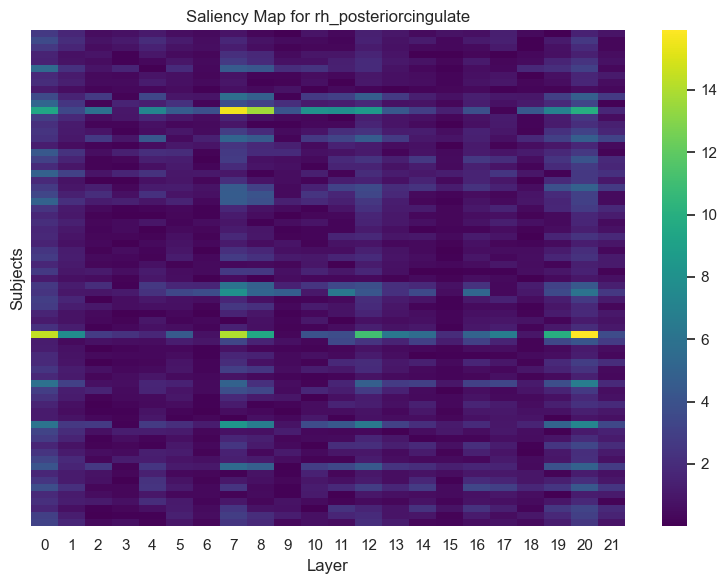

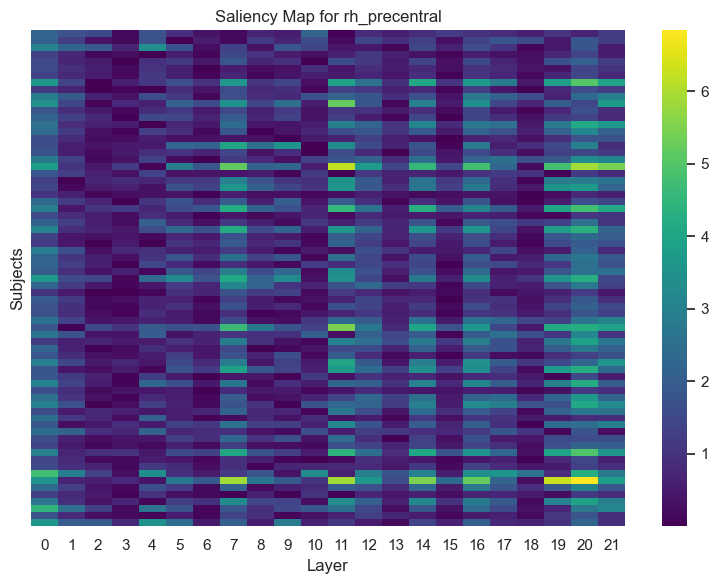

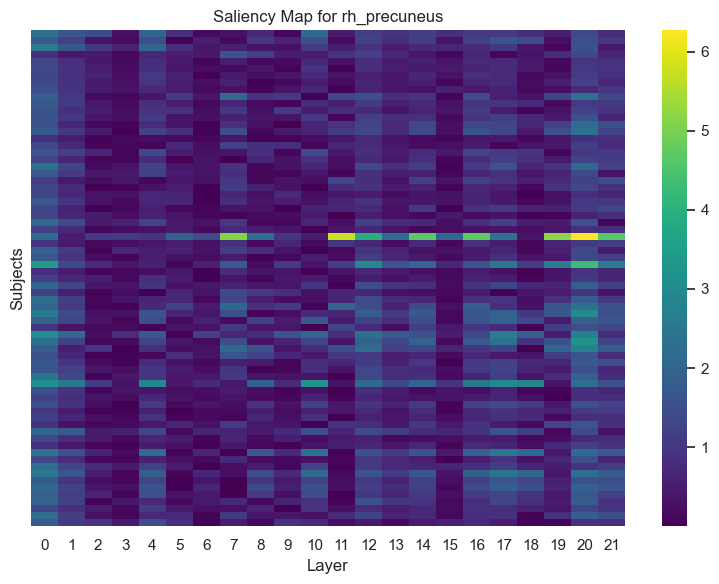

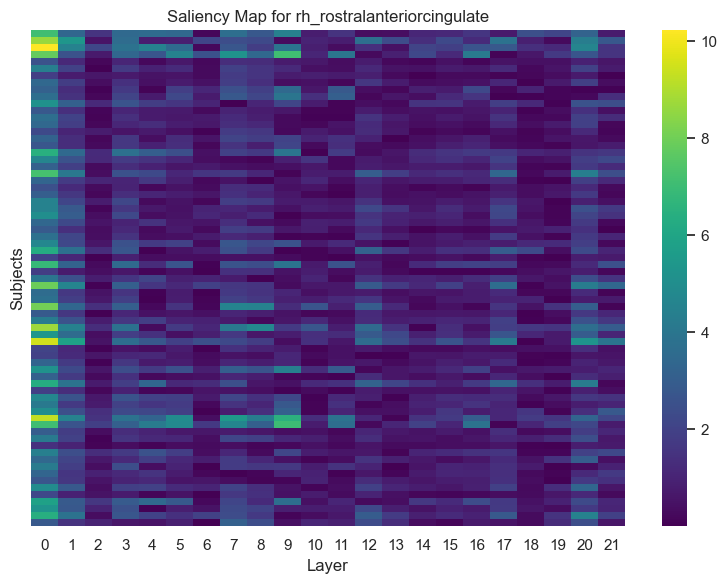

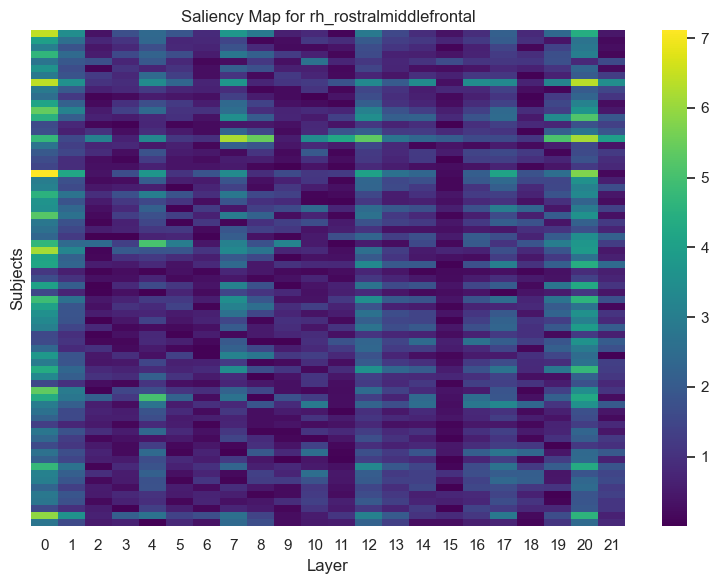

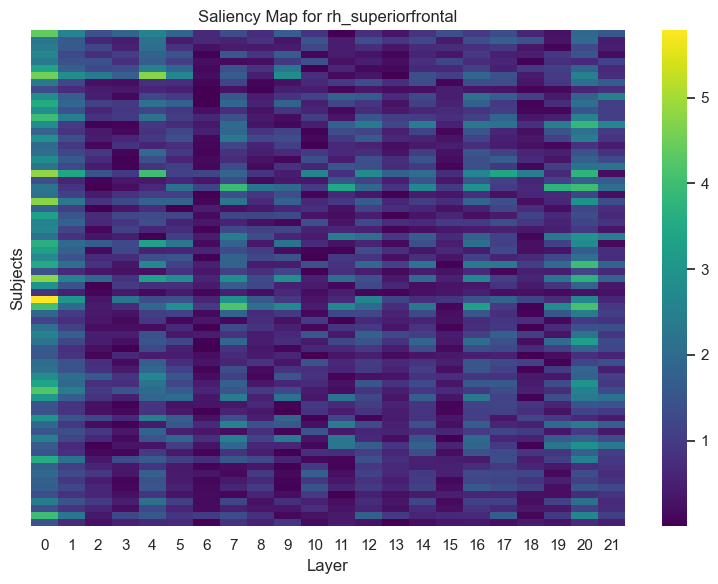

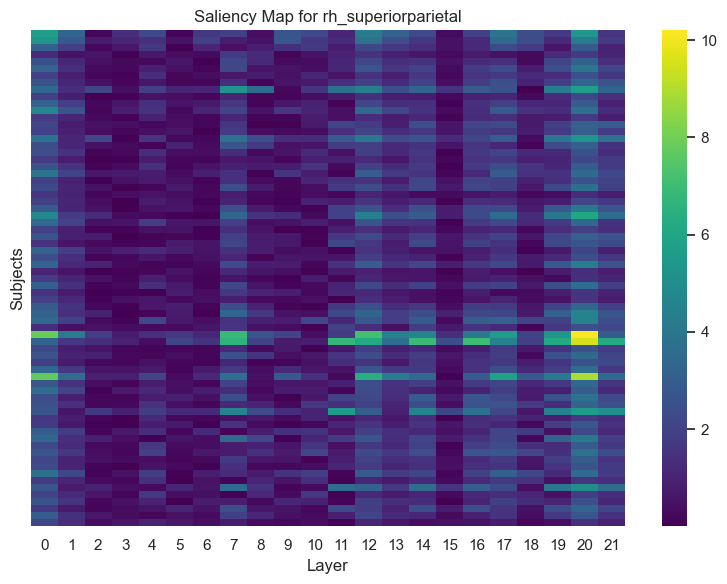

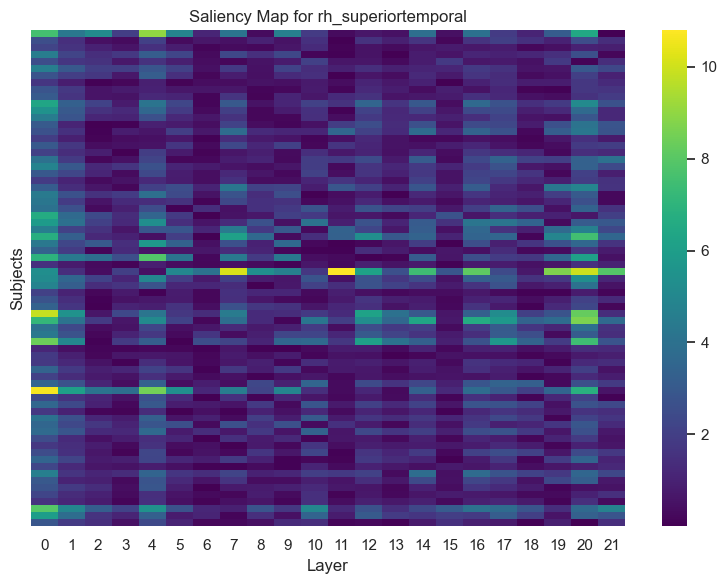

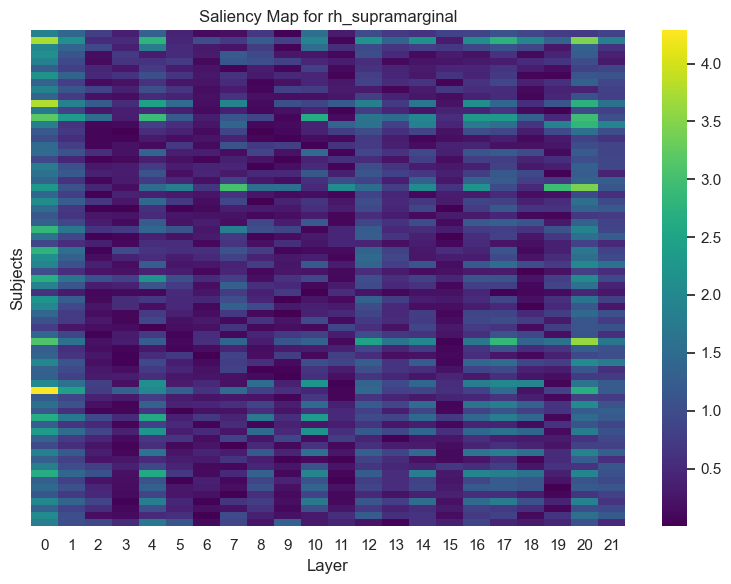

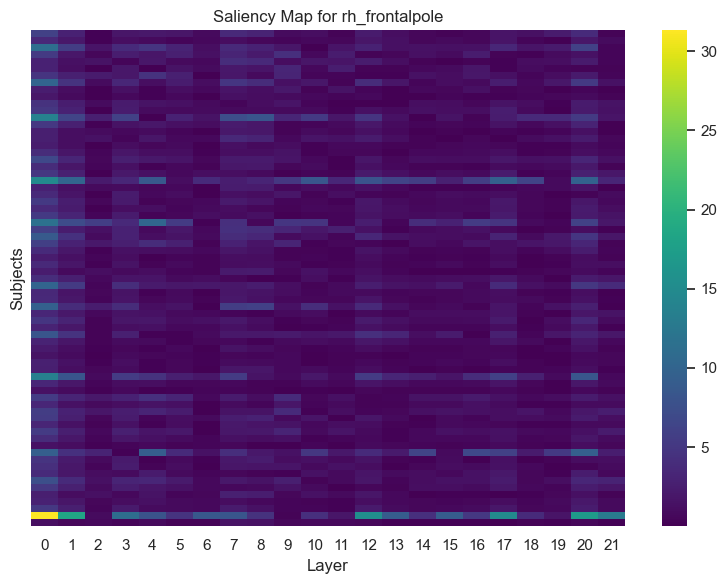

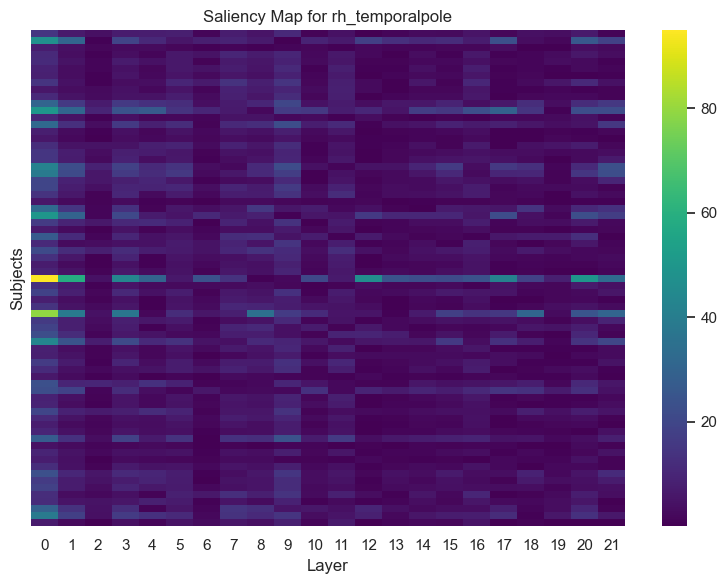

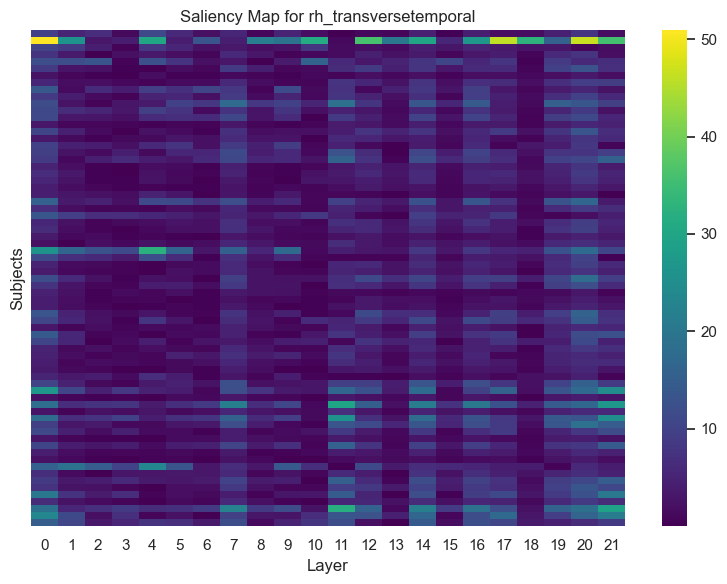

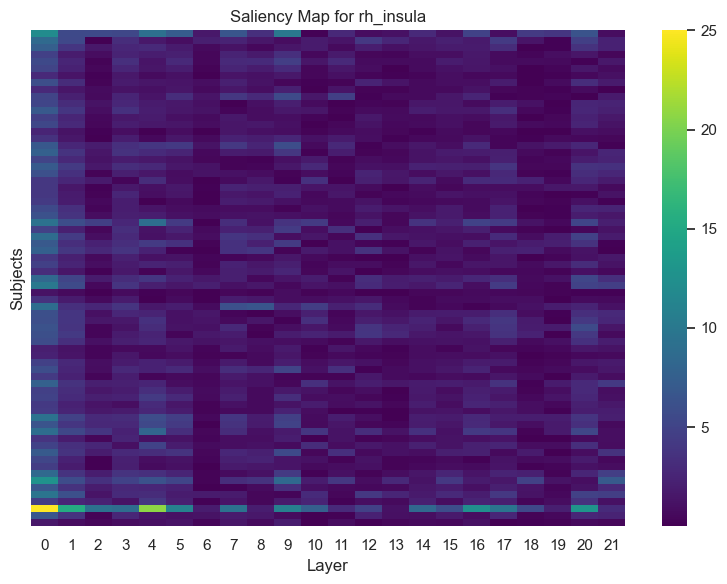

In [50]:
# Plot the saliency map of all subjects stacked
saliency_maps_all = [] # item: 68*22 matrix
for graph in graph_data_list_all:
    graph = graph.to(device)
    graph.x.requires_grad = True
    saliency_map = compute_saliency_map_by_layer(model, graph)
    saliency_maps_all.append(saliency_map)

# Convert to numpy array
saliency_maps_all = np.array(saliency_maps_all)
# Visualize saliency map for all subjects
regions = []
for hemi in HEMIS:
    for region in REGION_NAMES:
        region_key = f"{hemi}_{region}"
        regions.append(region_key)

# Plot the saliency map for each region
for i, region in enumerate(regions):
    plt.figure(figsize=(8, 6))
    sns.heatmap(saliency_maps_all[:, i], cmap="viridis", cbar=True,
                xticklabels=np.arange(22), yticklabels=False)
    plt.title(f"Saliency Map for {region}")
    plt.xlabel("Layer")
    plt.ylabel("Subjects")
    plt.tight_layout()
    plt.show()

# SHAP

In [51]:
# SHAP for GCN – By Region and Depth Feature Importance (Fixed for scalar output)
import shap
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import numpy as np

example_graph = graph_data_list_all[0]
n_total_columns, num_depths = example_graph.x.shape
feature_names = [f"Region_{i}_Depth_{j}" for i in range(n_total_columns) for j in range(num_depths)]

# Model wrapper for SHAP
class WrappedGCN(torch.nn.Module):
    def __init__(self, model, data_template):
        super().__init__()
        self.model = model
        self.edge_index = data_template.edge_index
        self.batch = data_template.batch if hasattr(data_template, 'batch') else torch.zeros(data_template.x.shape[0], dtype=torch.long)
        self.template = data_template

    def forward(self, x_flat_batch):
        n_total_columns = self.template.x.shape[0]
        num_depths = self.template.x.shape[1]
        device = next(self.model.parameters()).device

        outputs = []
        for i in range(x_flat_batch.shape[0]):
            x = x_flat_batch[i].view(n_total_columns, num_depths).to(device)
            d = Data(
                x=x,
                edge_index=self.edge_index.to(device),
                batch=self.batch.to(device) if self.batch is not None else torch.zeros(x.size(0), dtype=torch.long, device=device)
            )
            out = self.model(d)  # Shape: [1]
            outputs.append(out)

        return torch.stack(outputs, dim=0)


# SHAP value computation
shap_list = []
for graph in graph_data_list_all:
    graph = graph.to(device)
    X = graph.x.detach().cpu().numpy()
    n_total_columns, num_depths = X.shape
    X_flat = X.flatten().reshape(1, -1)

    X_input = torch.tensor(X_flat, dtype=torch.float32, requires_grad=True)
    X_background = torch.zeros_like(X_input)

    wrapped_model = WrappedGCN(model, graph).to(device)
    wrapped_model.eval()

    explainer = shap.GradientExplainer(wrapped_model, X_background.to(device))
    shap_values_result = explainer.shap_values(X_input.to(device), ranked_outputs=1)

    # Handle tuple output from SHAP
    if isinstance(shap_values_result, tuple):
        shap_values = shap_values_result[0]
    else:
        shap_values = shap_values_result

    # Handle possible list (multi-output models)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    shap_values = shap_values.reshape(n_total_columns, num_depths)
    shap_list.append(shap_values)

# Save SHAP values for each subject
import os
if not os.path.exists("shap_values"):
    os.makedirs("shap_values")
for i, graph in enumerate(graph_data_list_all):
    subject_id = graph.subject_id
    shap_values = shap_list[i]
    np.save(os.path.join("shap_values", f"shap_values_{subject_id}.npy"), shap_values)

# Aggregate across subjects
shap_ave = np.mean(np.stack(shap_list, axis=0), axis=0)


d:\Anaconda\install\envs\GNN\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


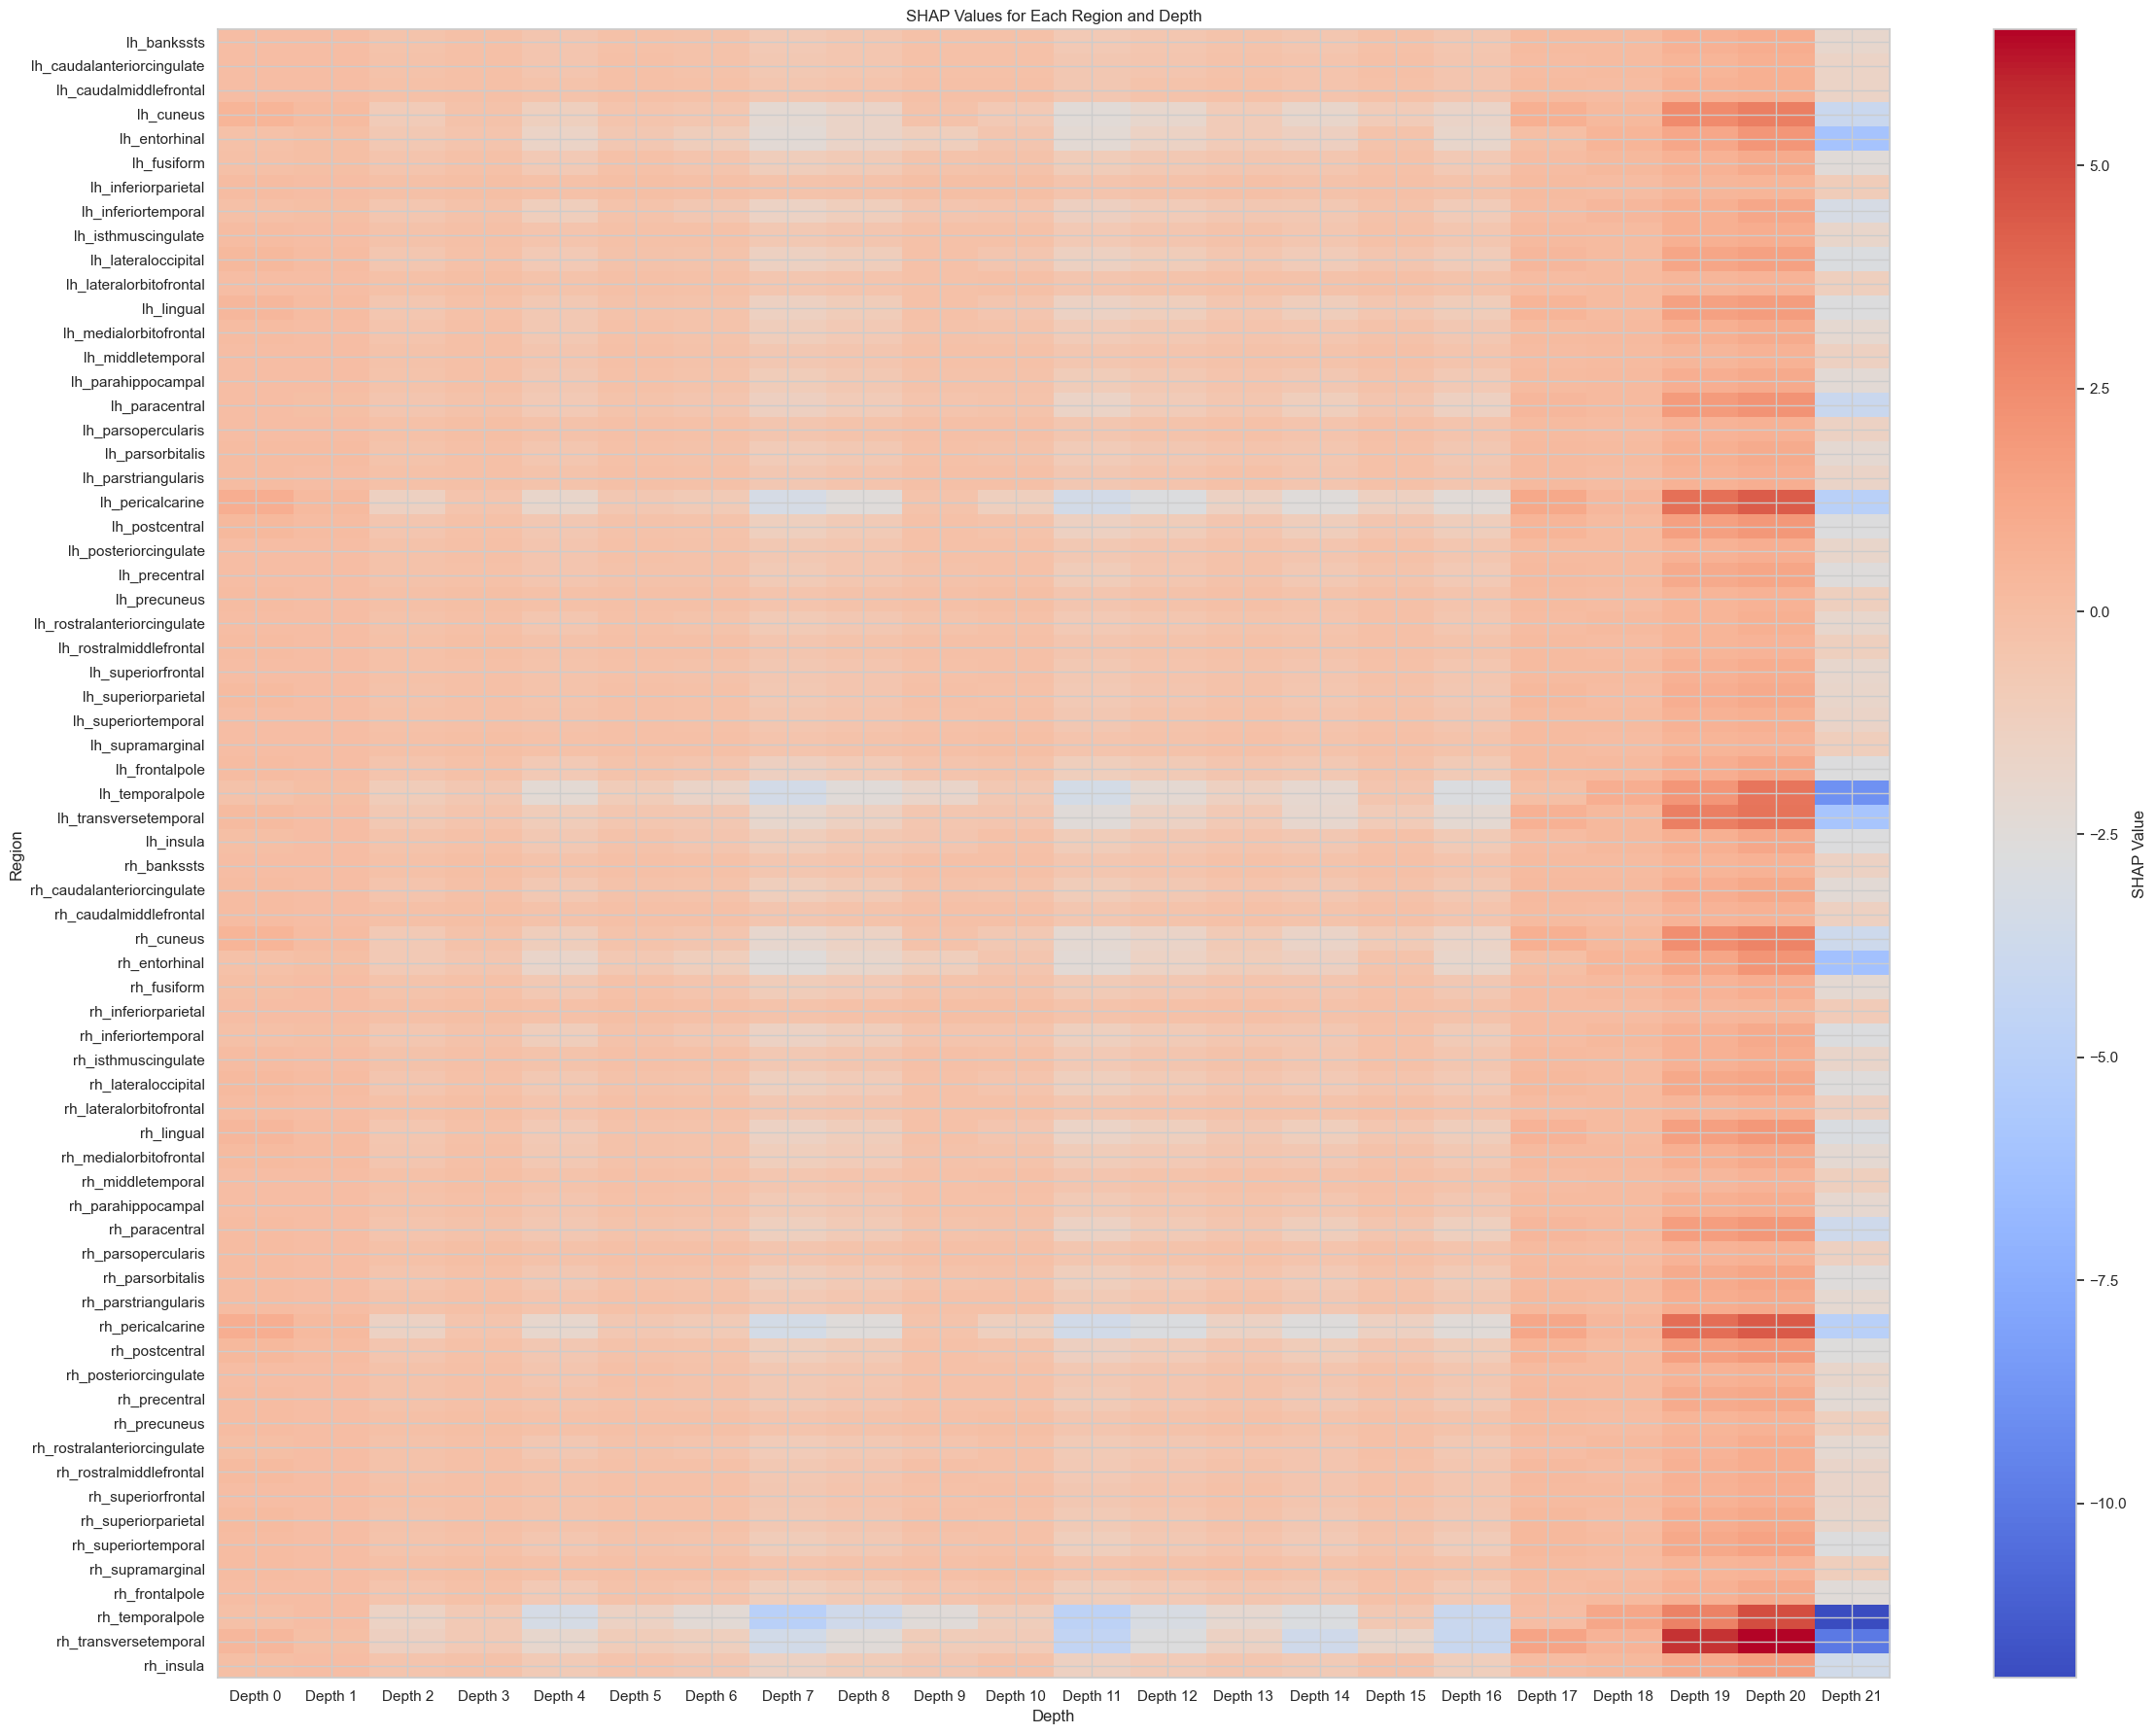

In [52]:
# Plot with wider rows (increase height per region)
xlabel = []
for hemi in HEMIS:
    for region in REGION_NAMES:
        region_key = f"{hemi}_{region}"
        xlabel.append(region_key)
plt.figure(figsize=(24, 18))  # Increase height from 10 to 18
plt.imshow(shap_ave, cmap='coolwarm', aspect='auto', interpolation='nearest')
plt.colorbar(label='SHAP Value')
plt.xticks(ticks=np.arange(num_depths), labels=[f"Depth {i}" for i in range(num_depths)])
plt.yticks(ticks=np.arange(n_total_columns), labels=xlabel)
plt.title('SHAP Values for Each Region and Depth')
plt.xlabel('Depth')
plt.ylabel('Region')
plt.tight_layout()
plt.show()



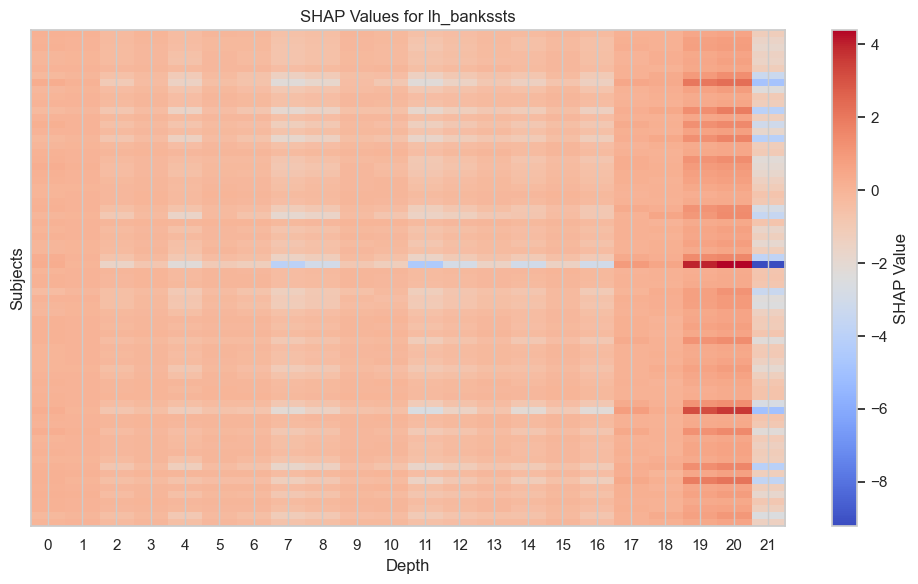

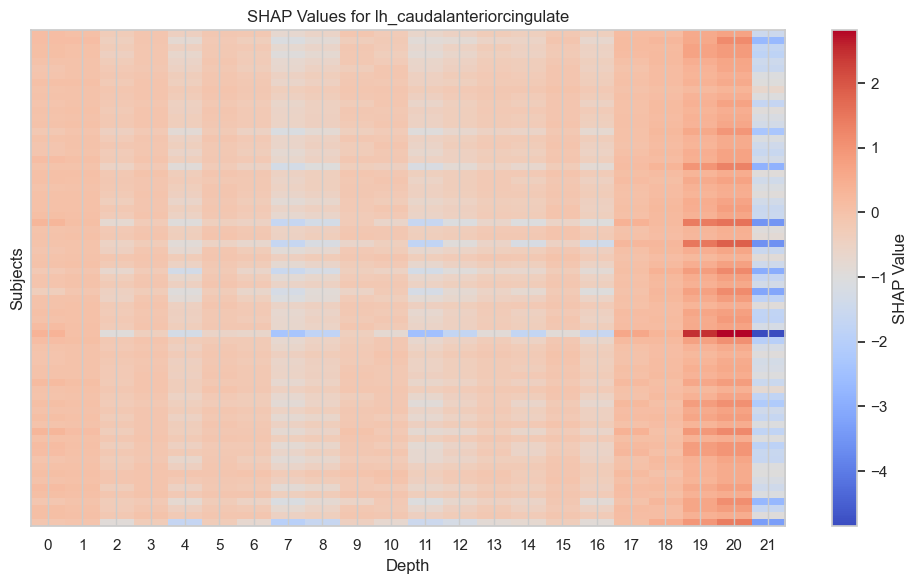

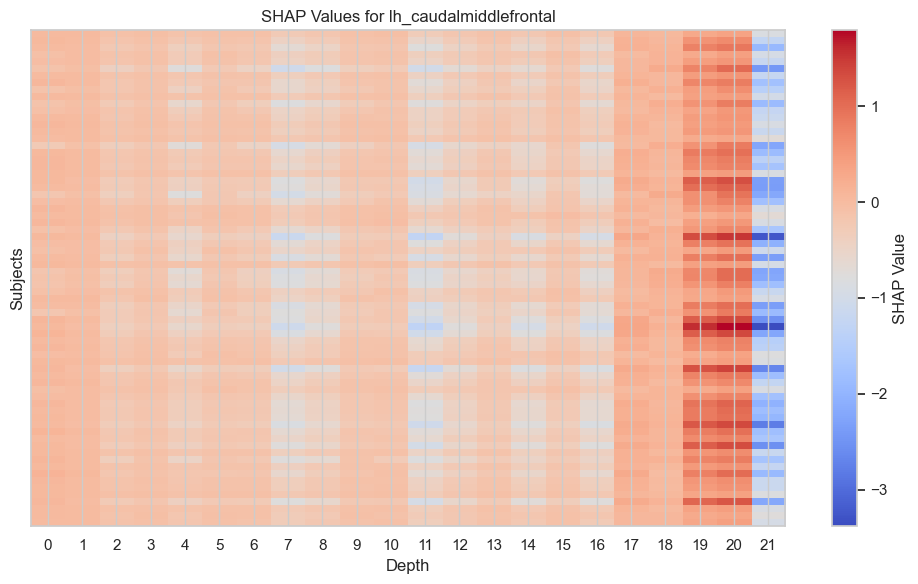

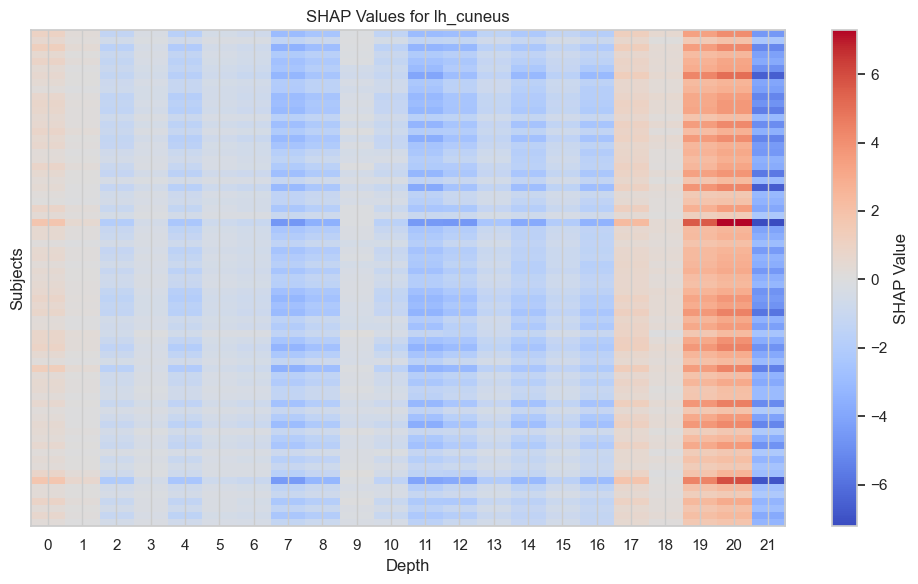

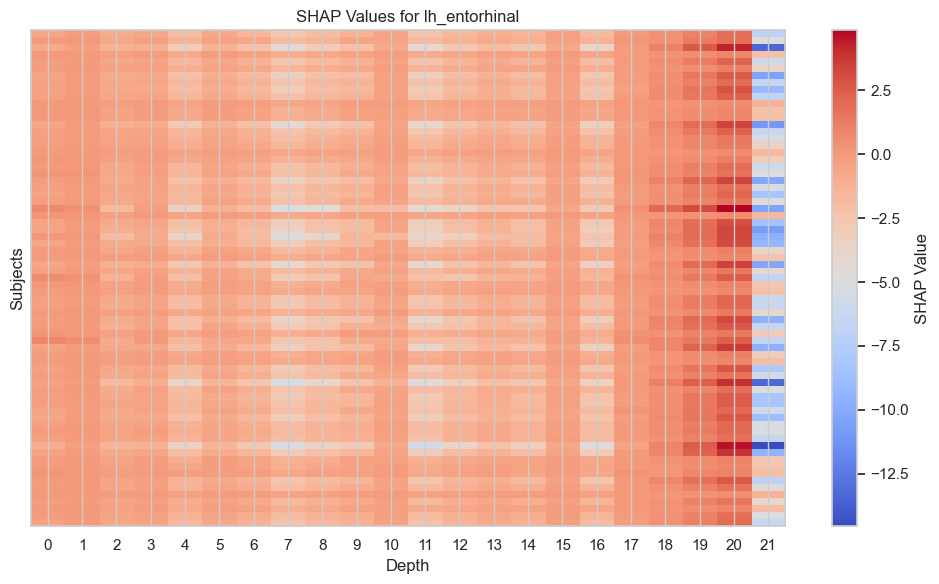

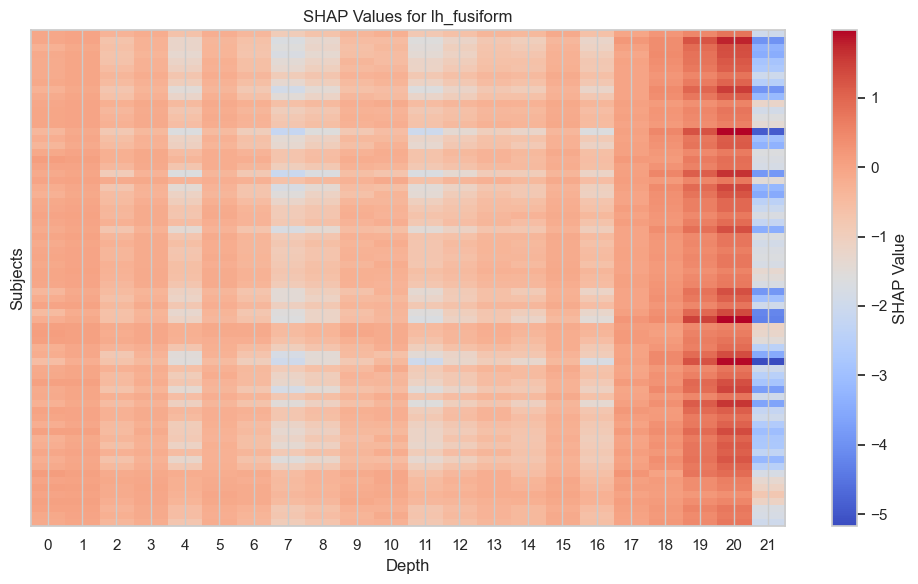

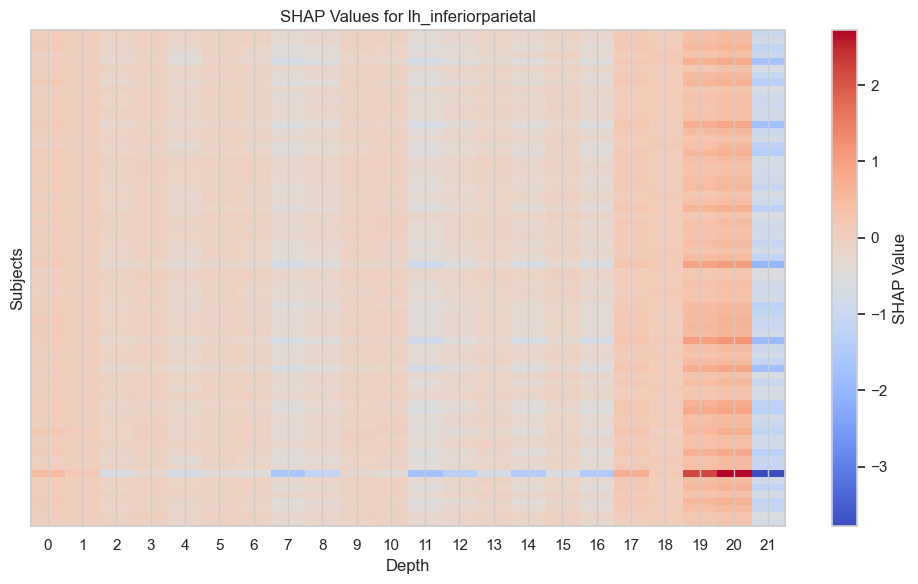

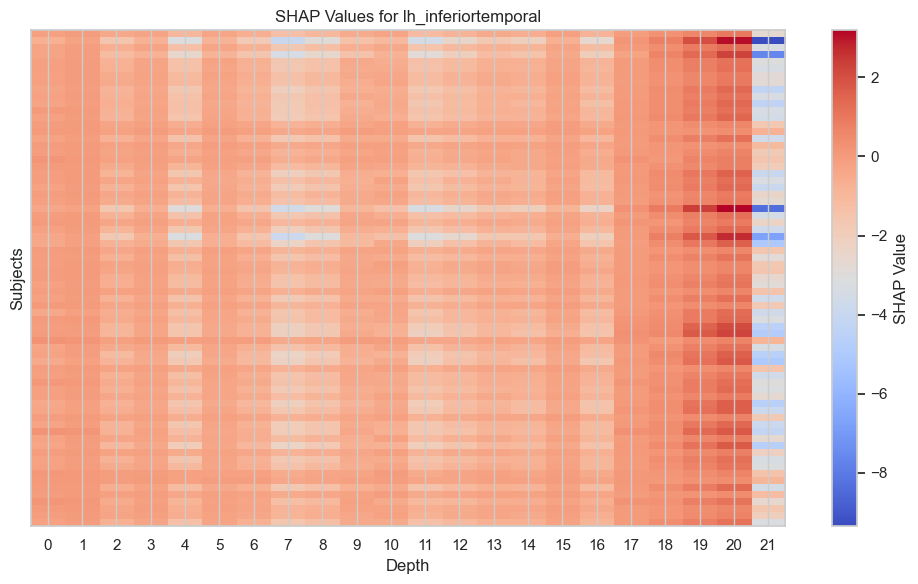

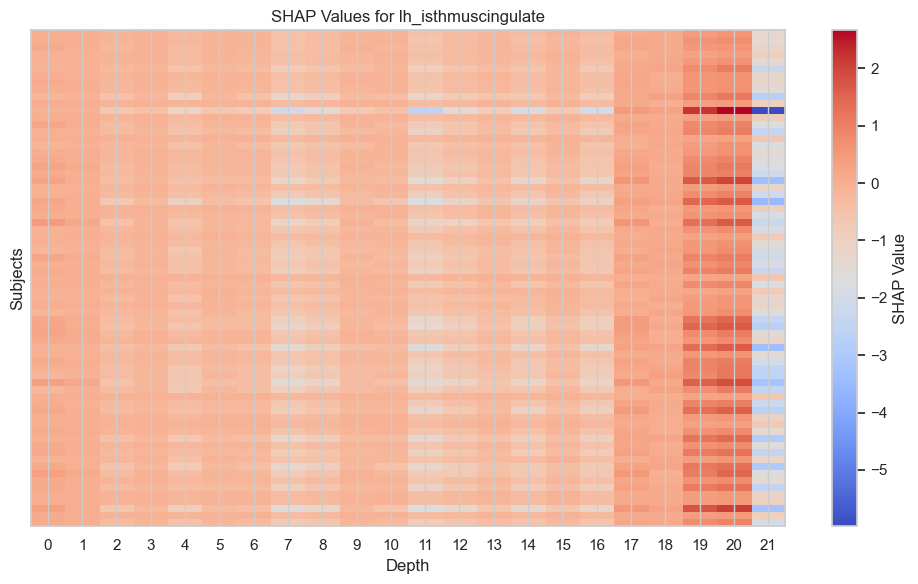

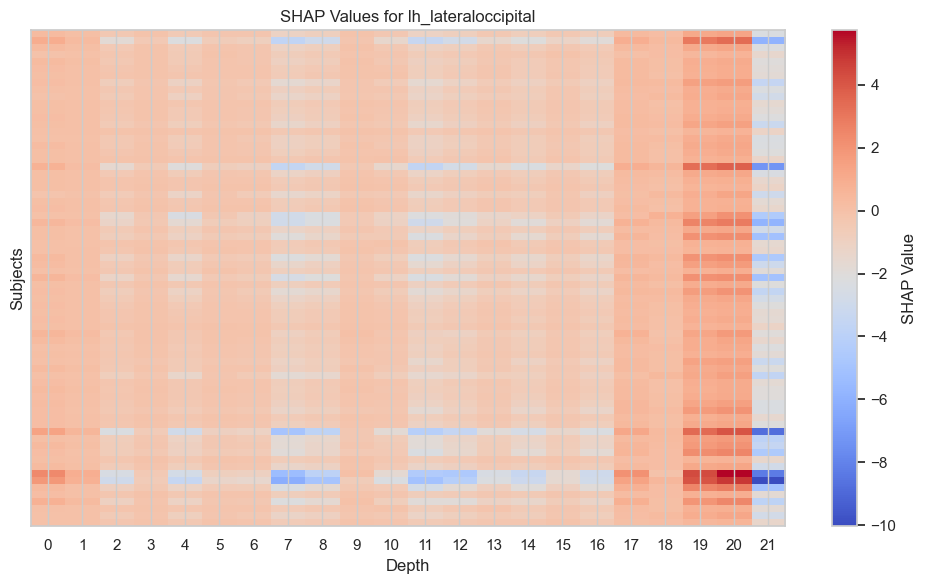

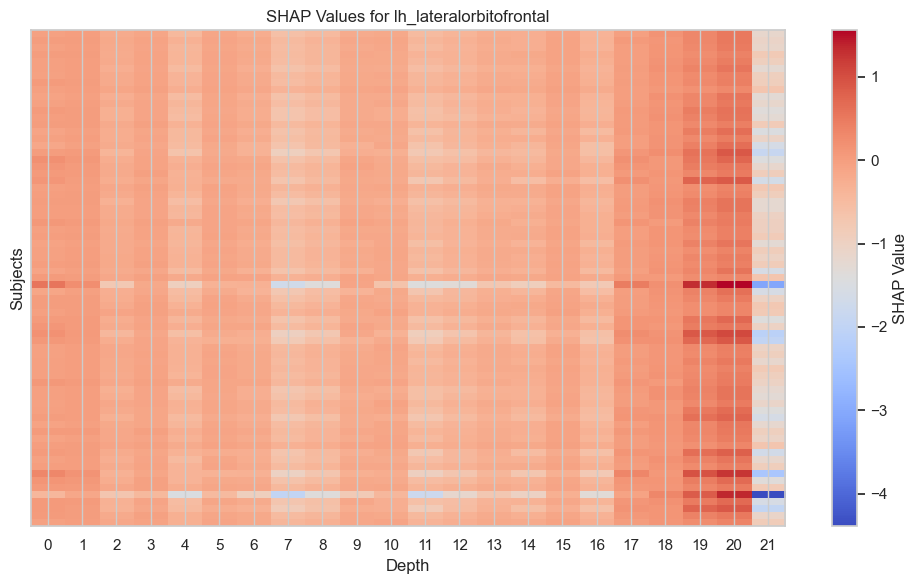

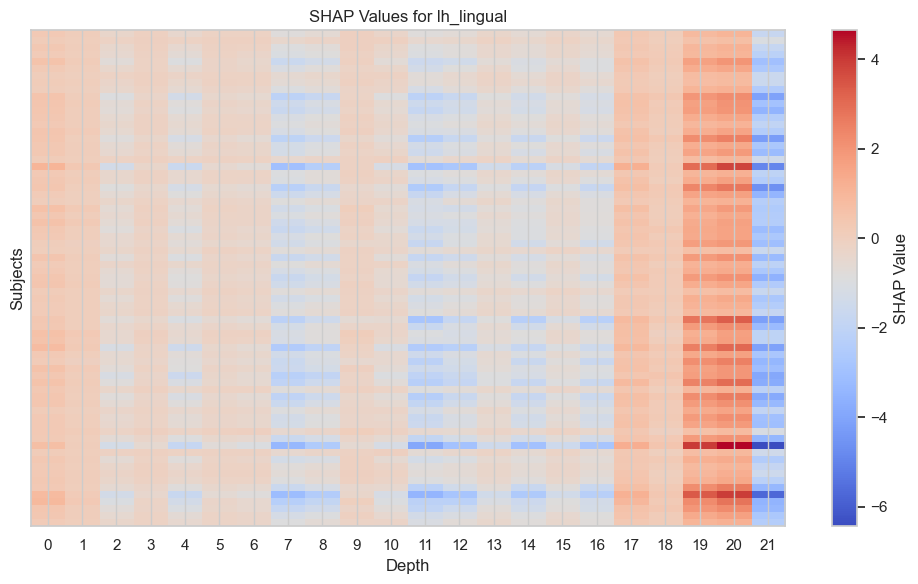

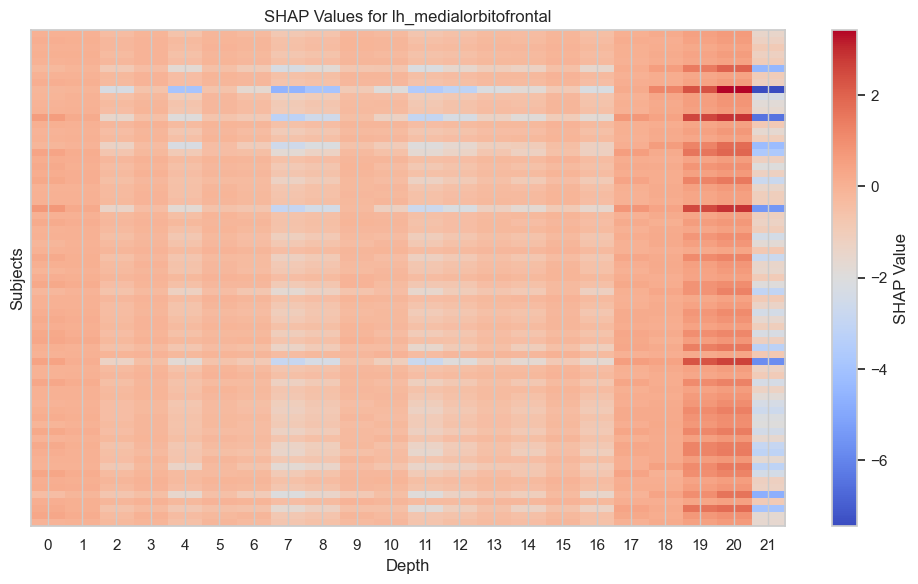

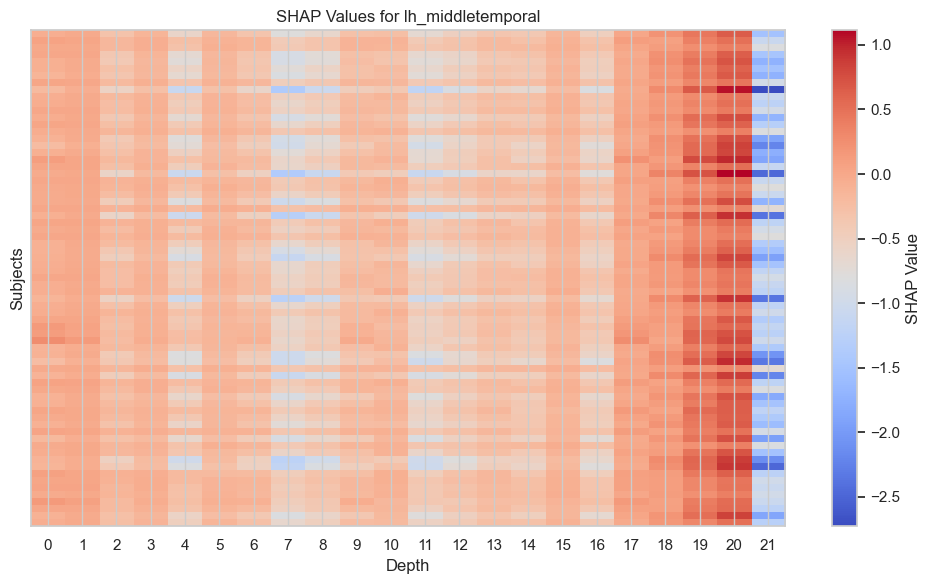

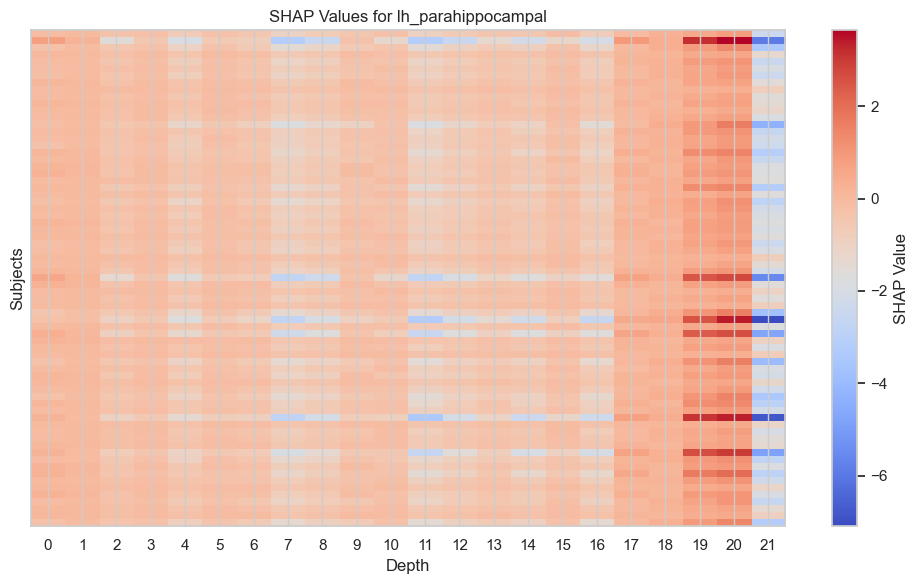

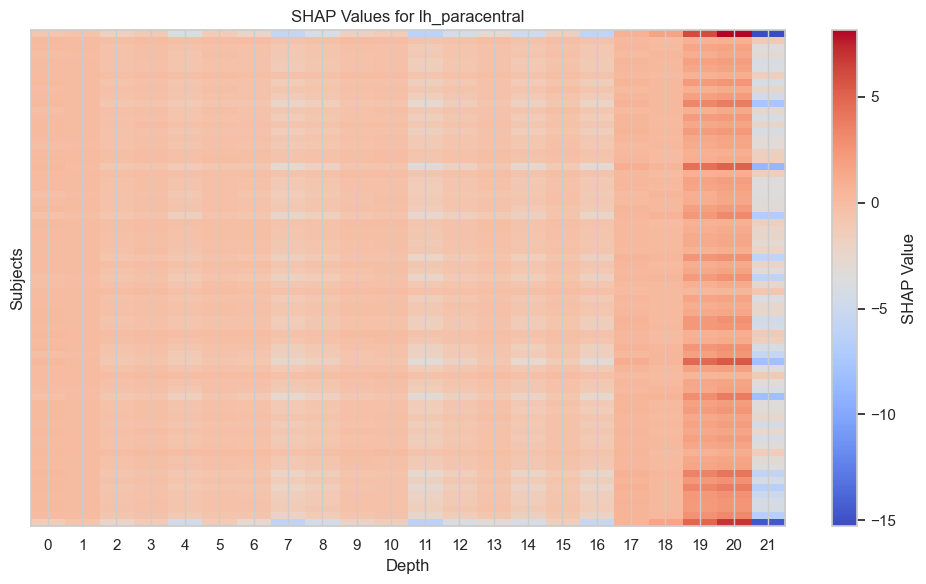

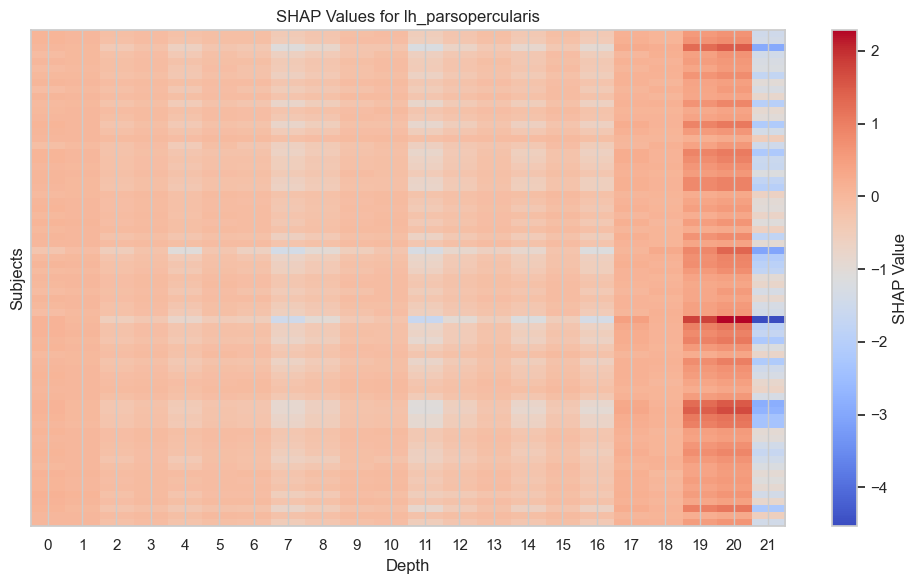

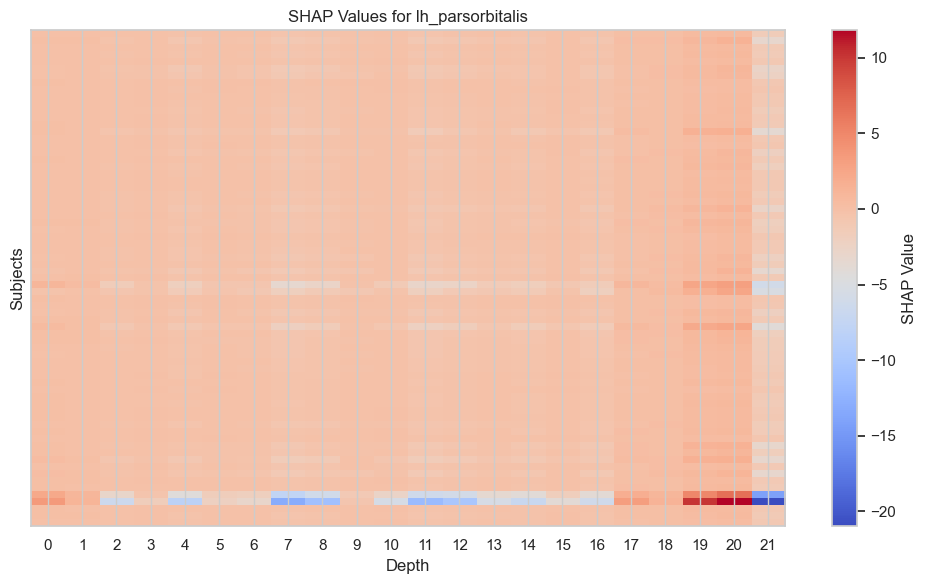

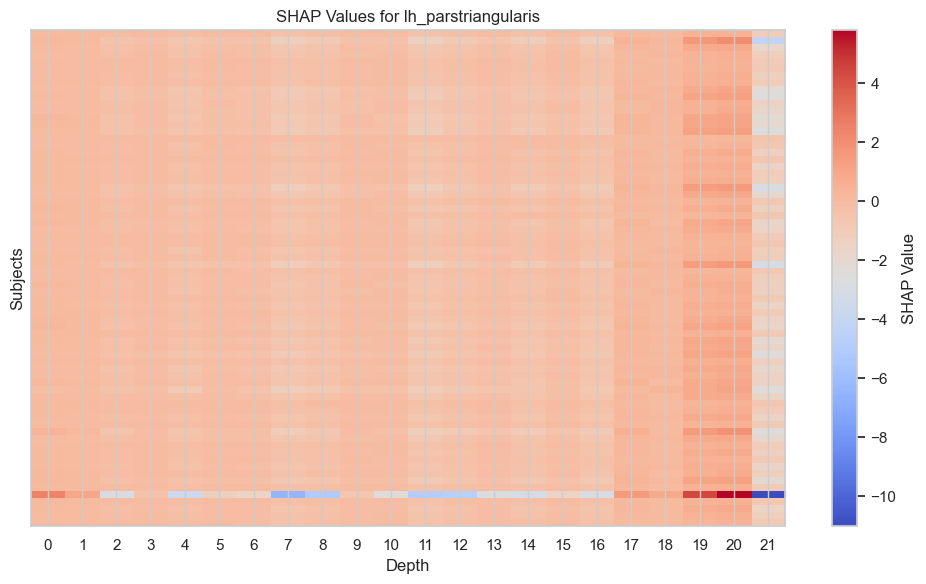

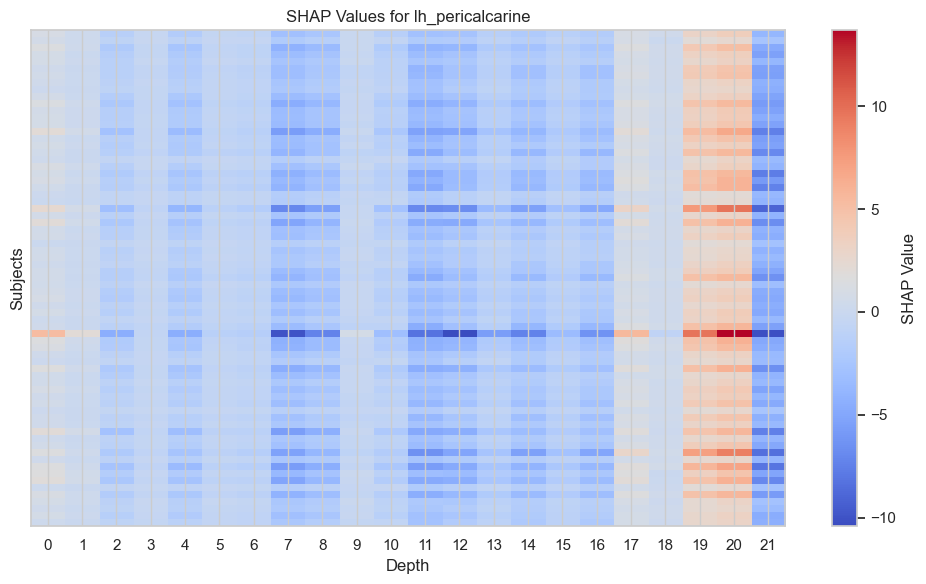

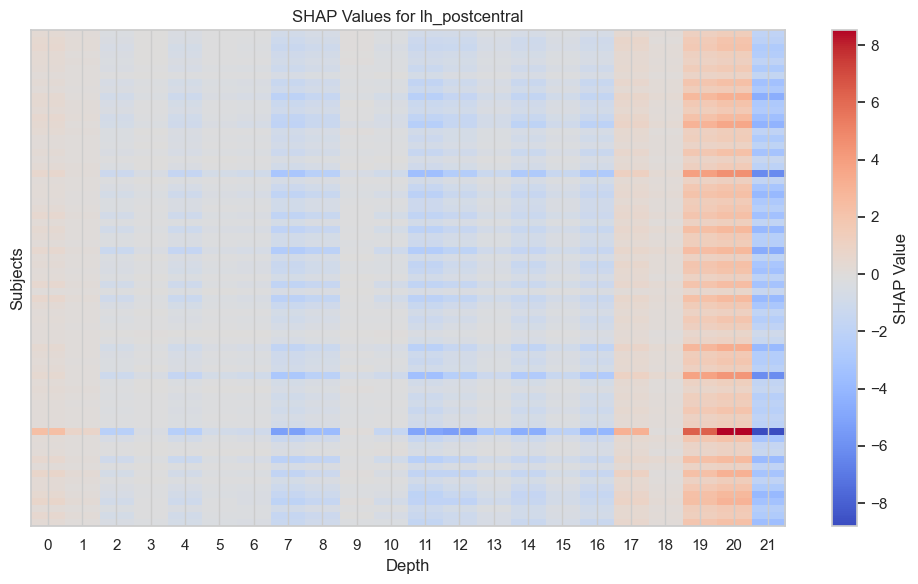

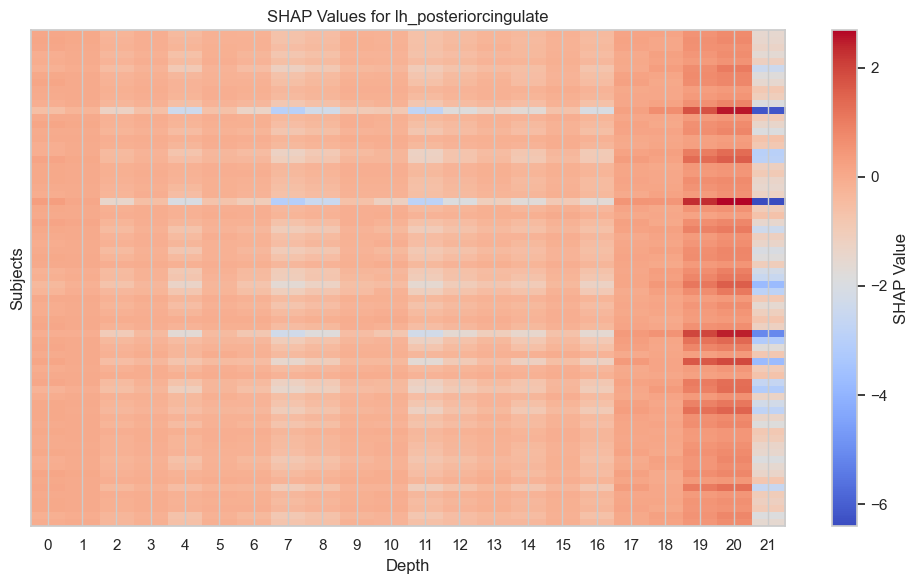

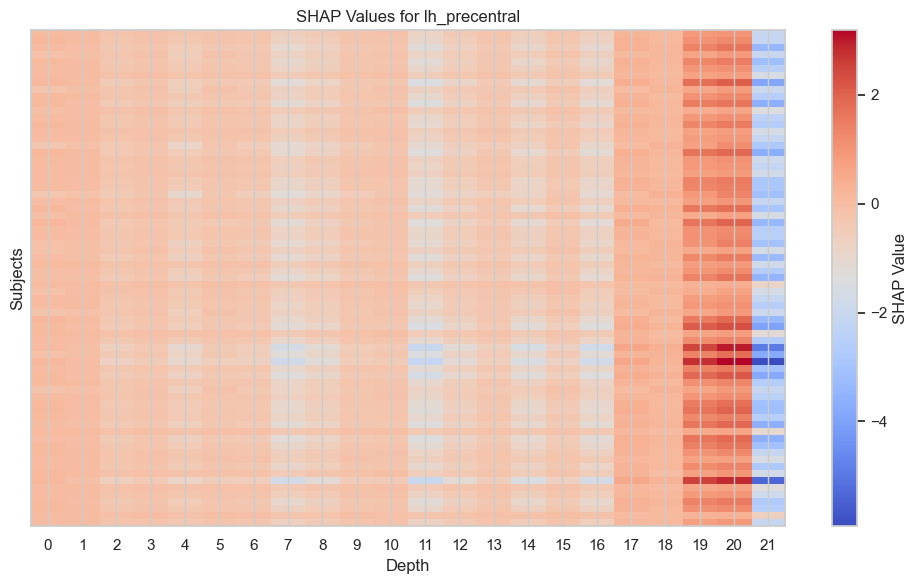

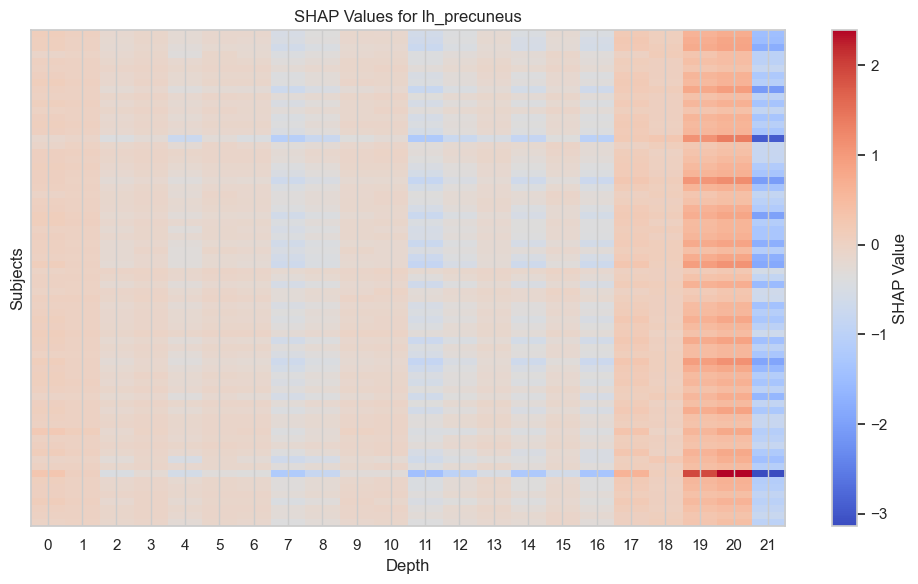

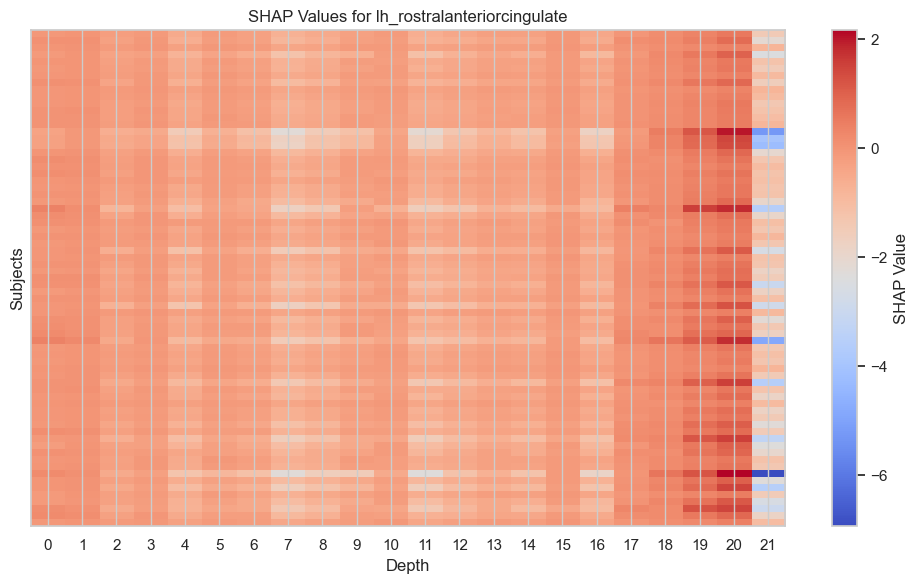

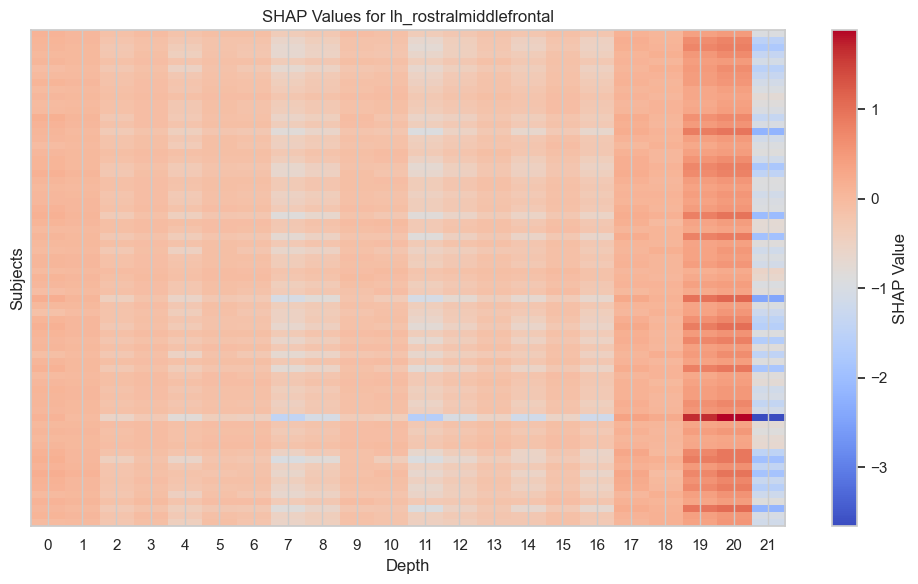

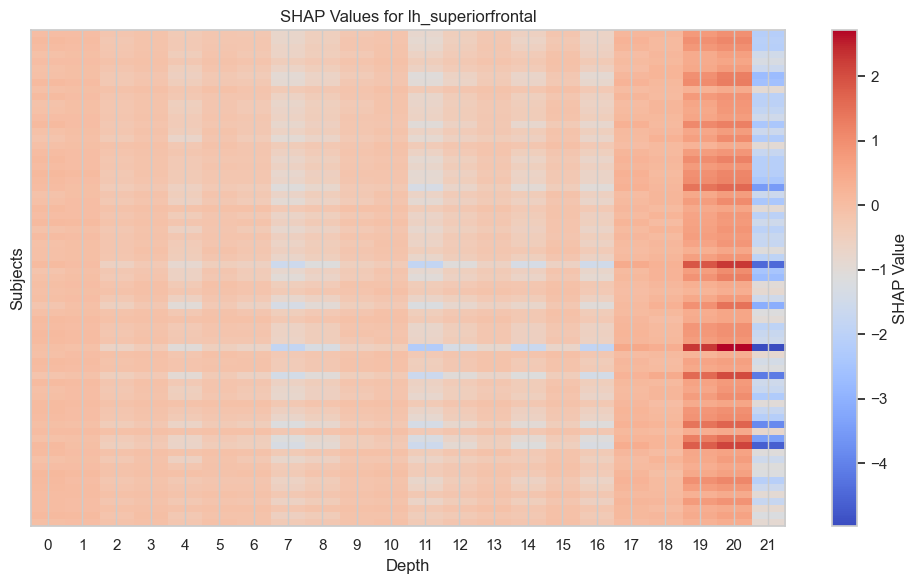

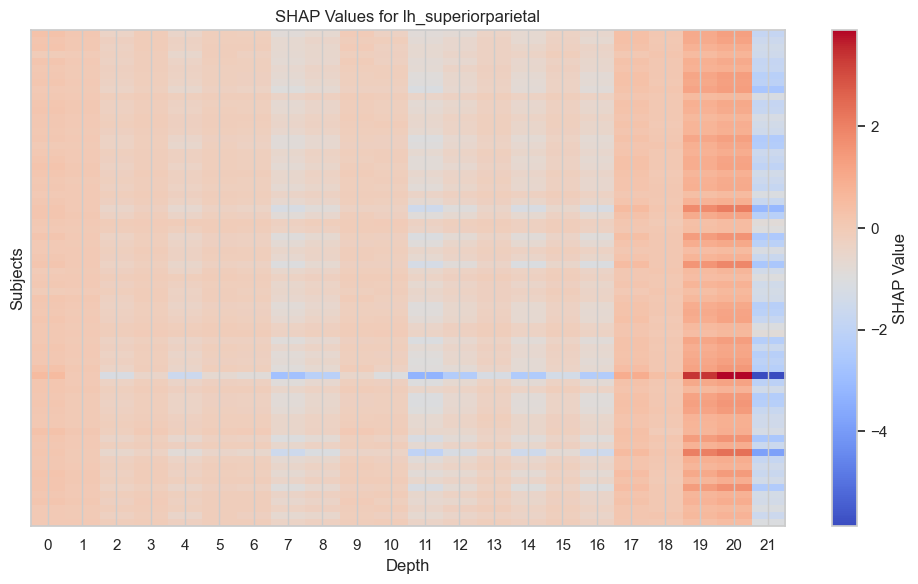

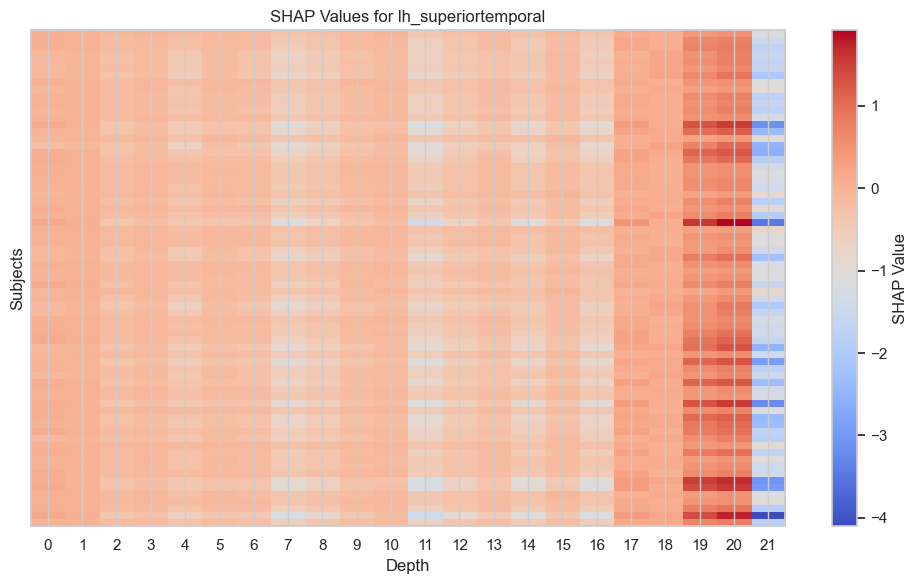

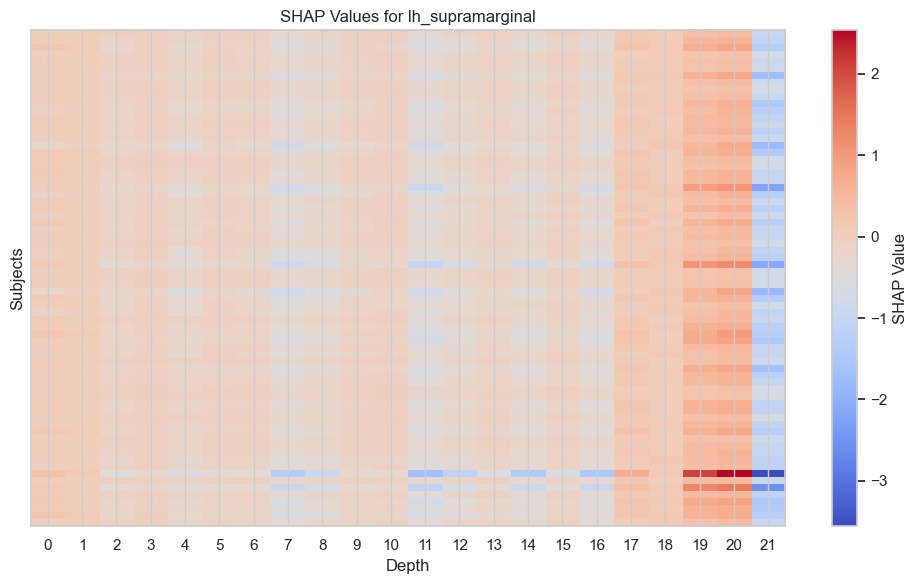

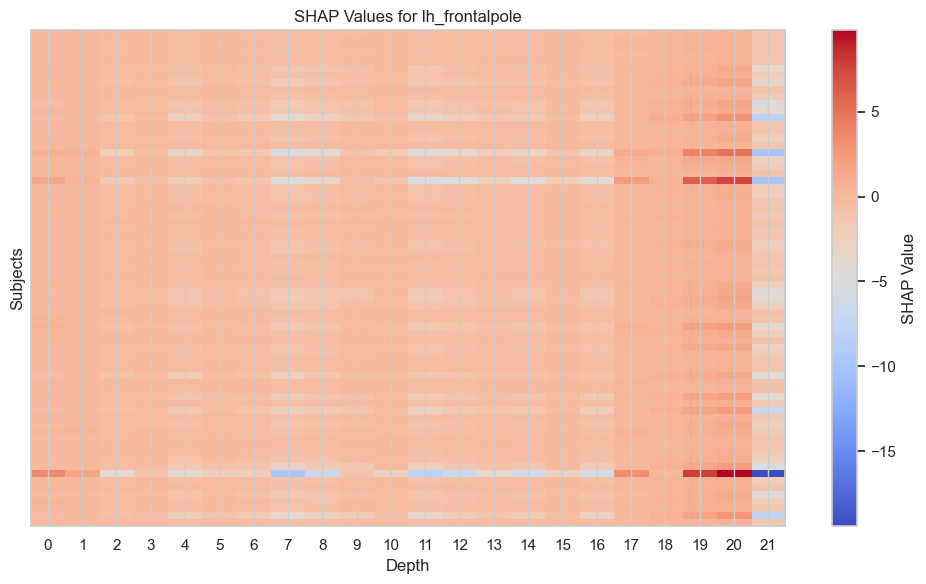

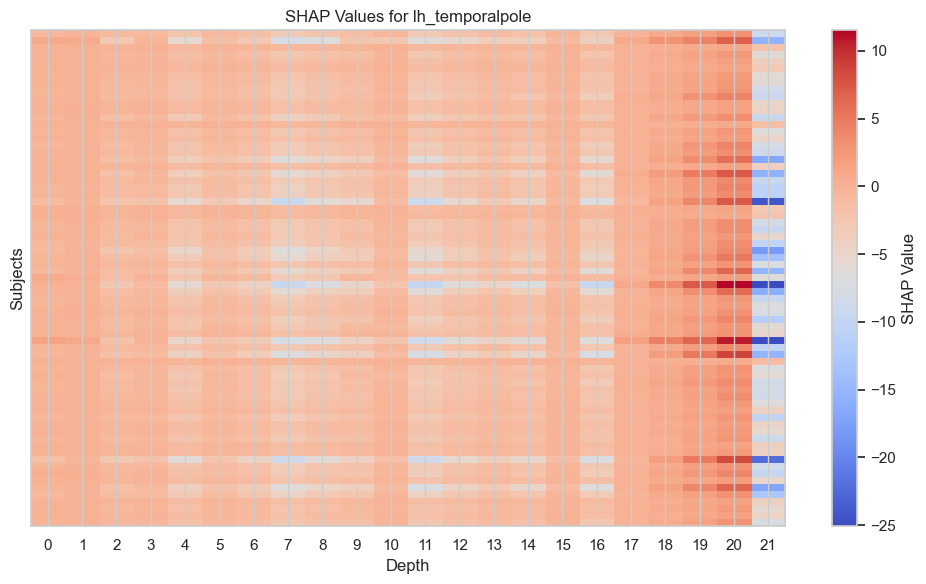

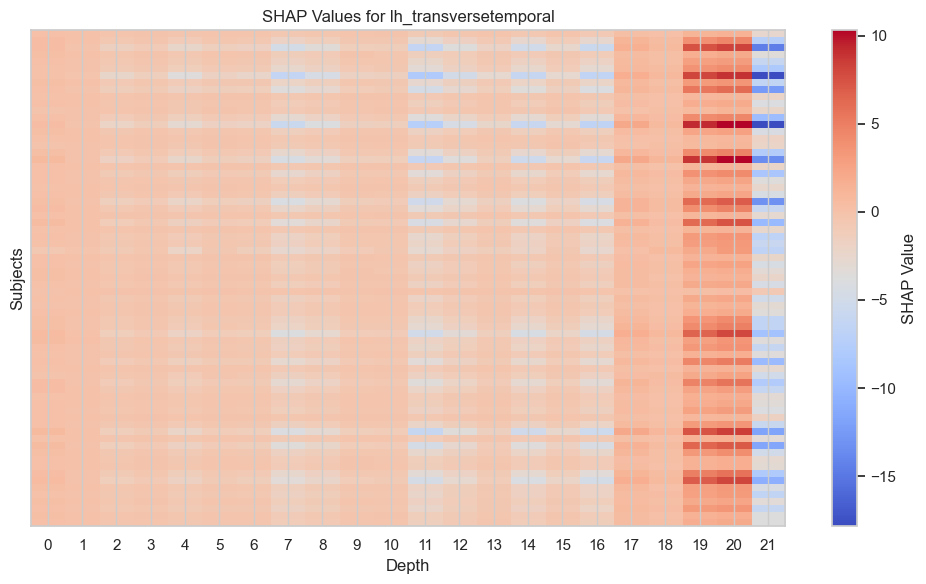

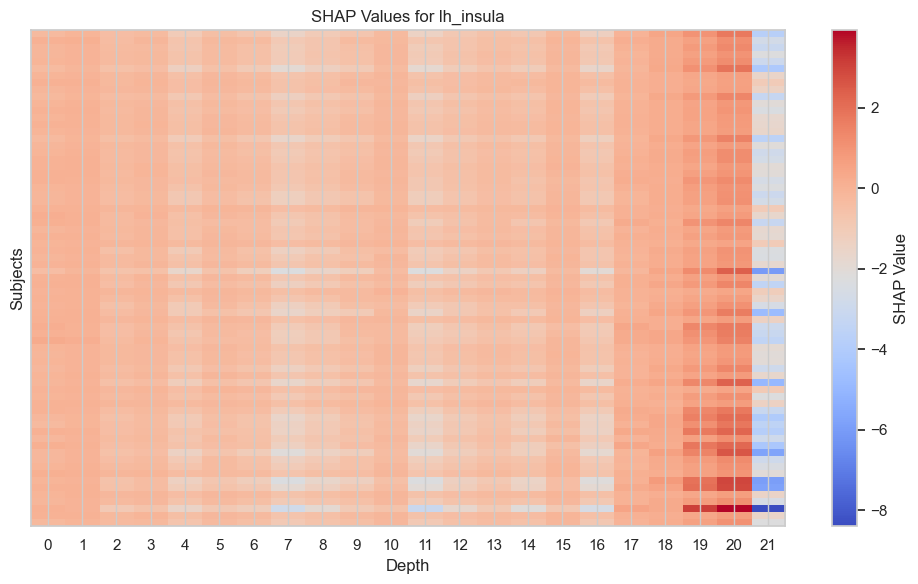

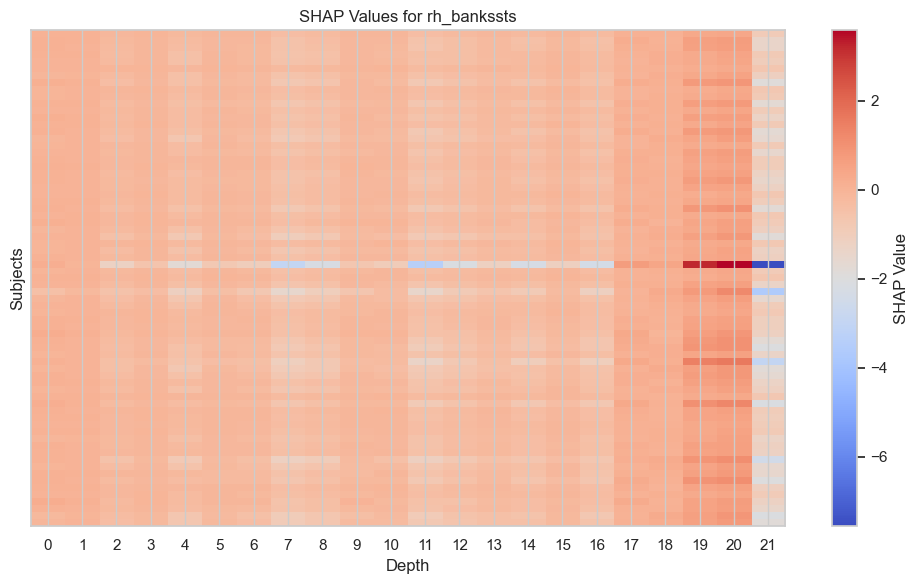

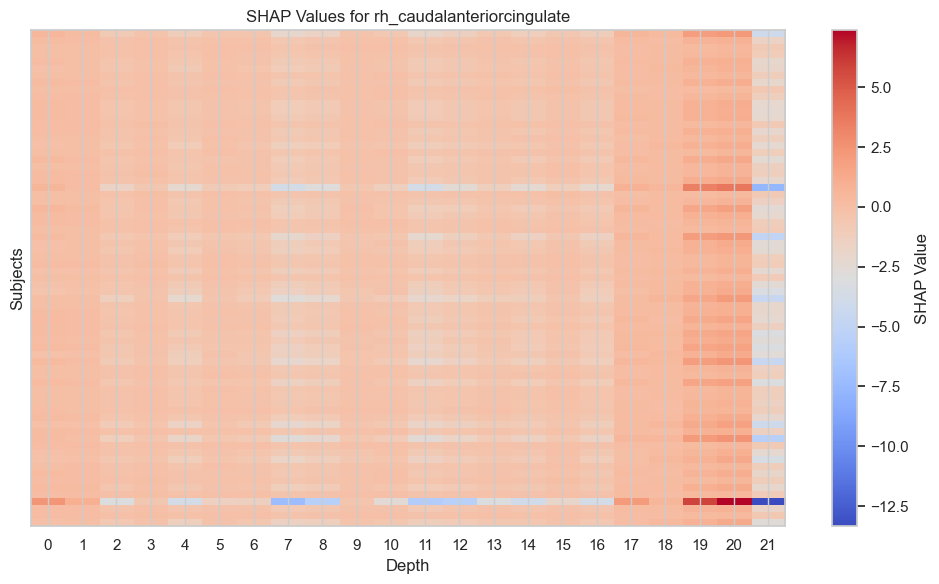

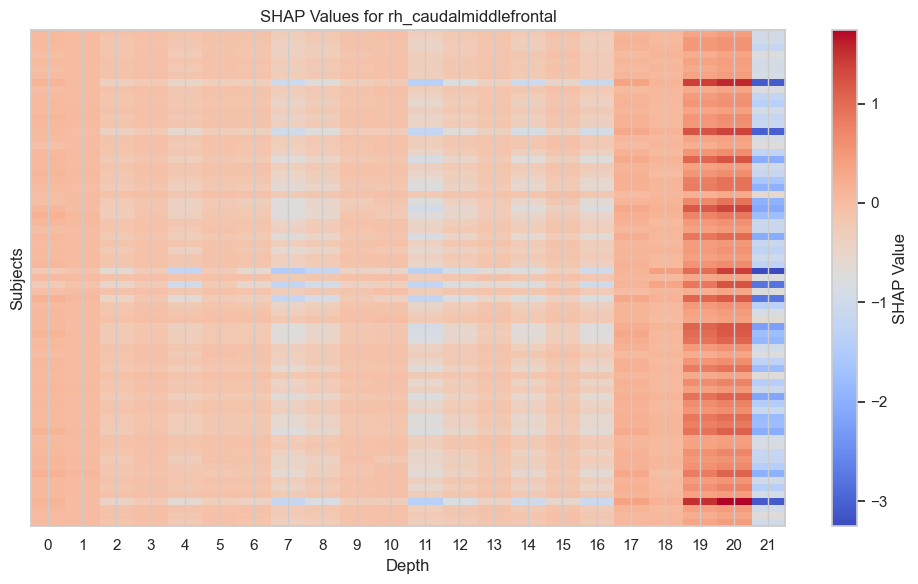

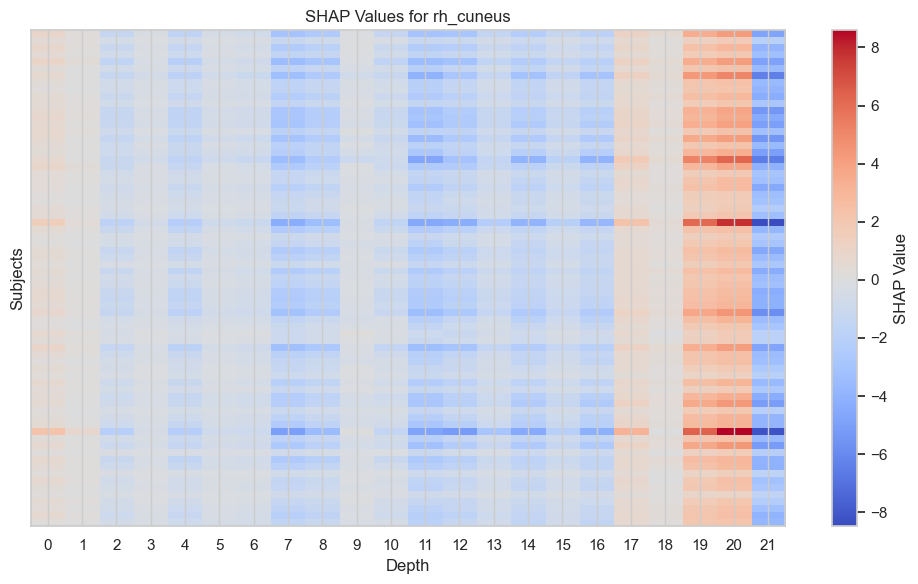

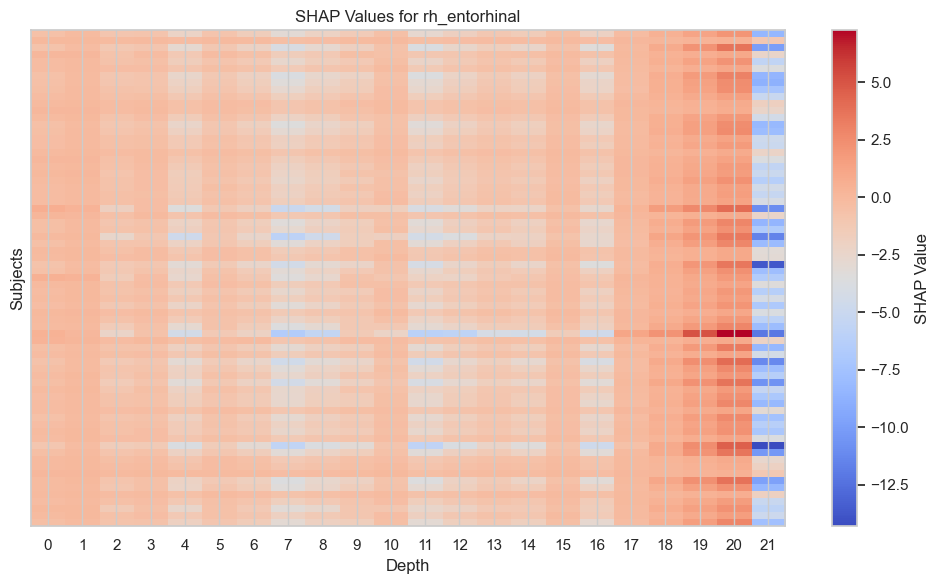

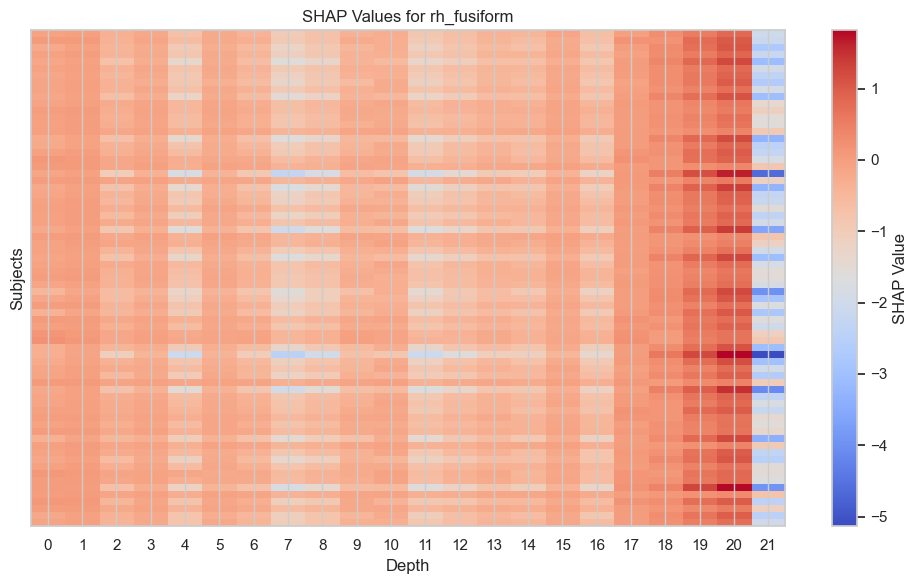

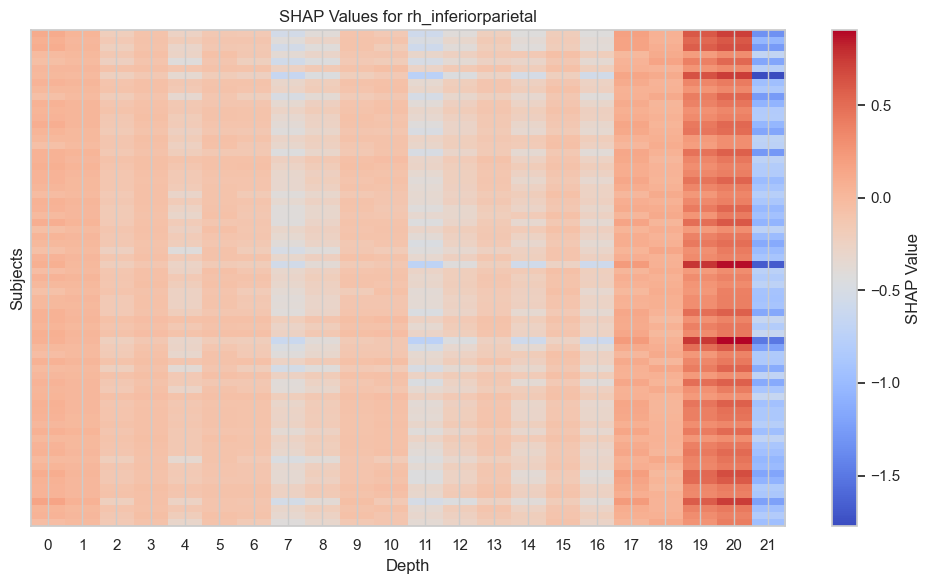

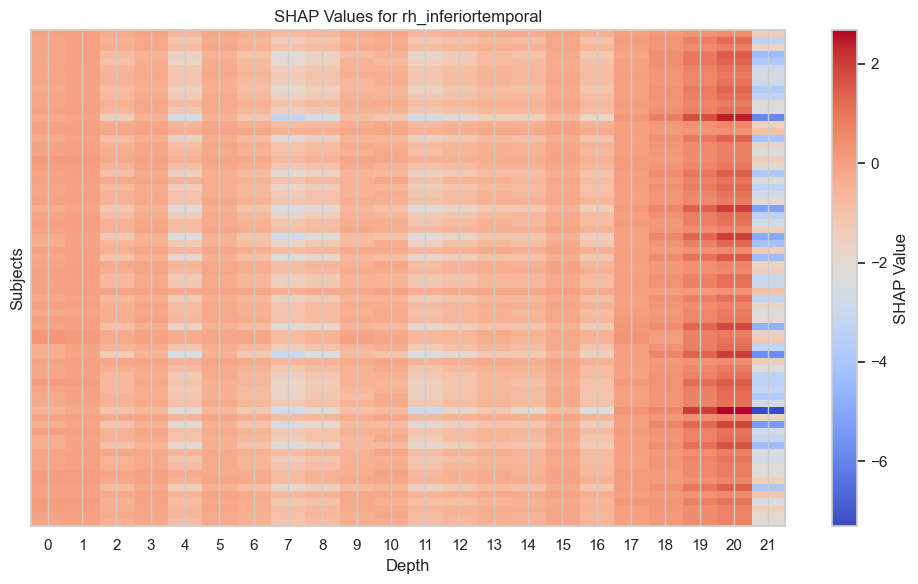

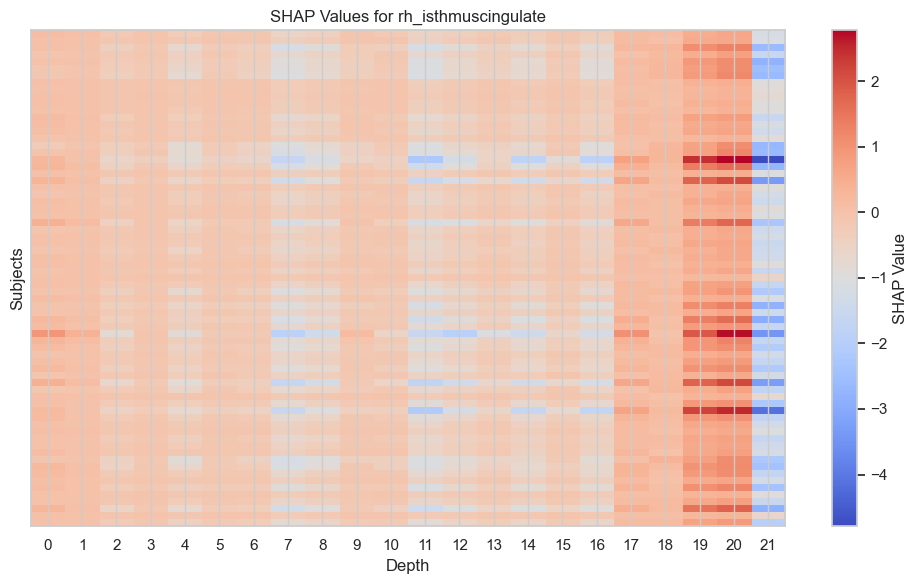

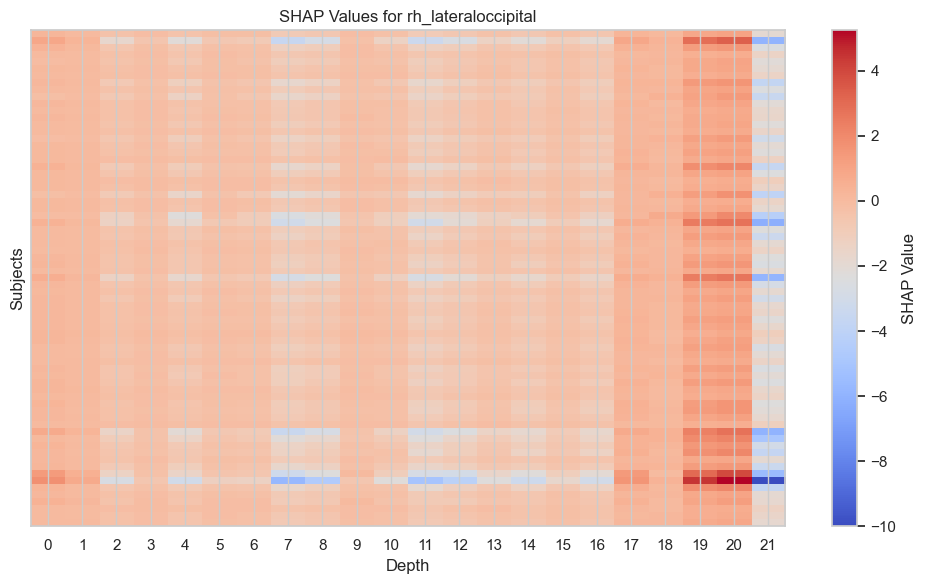

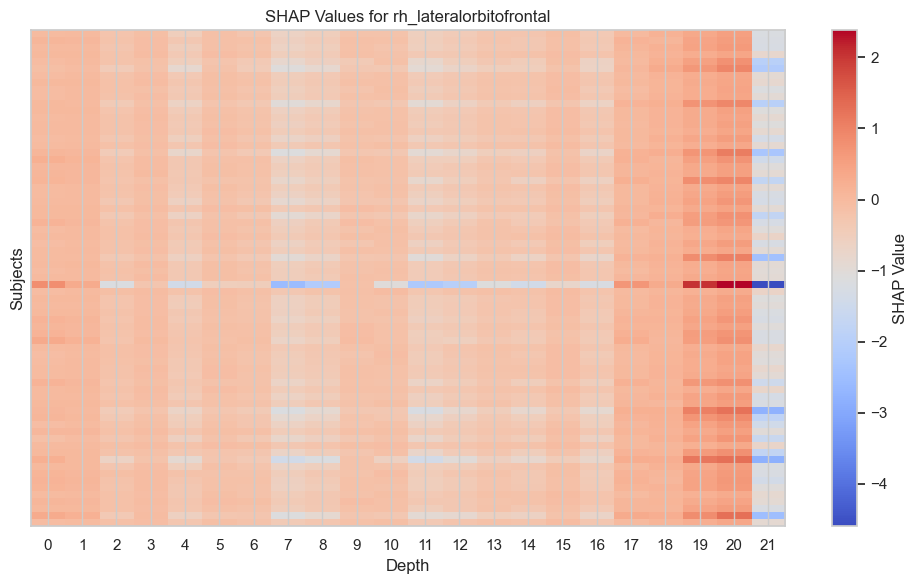

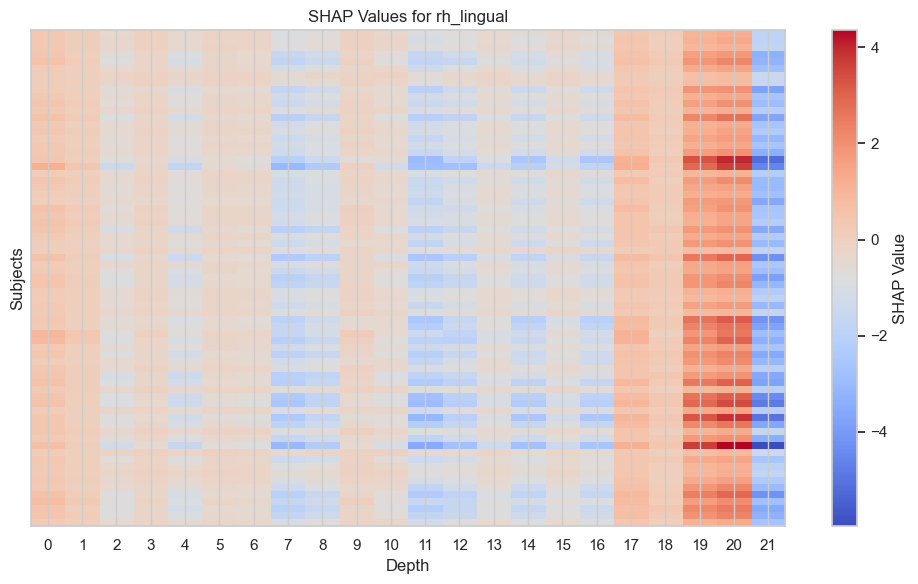

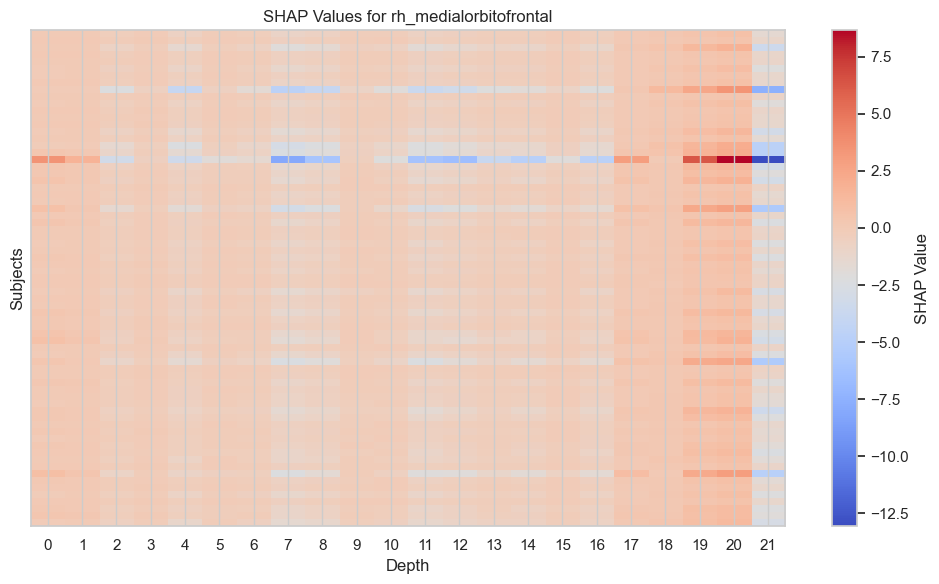

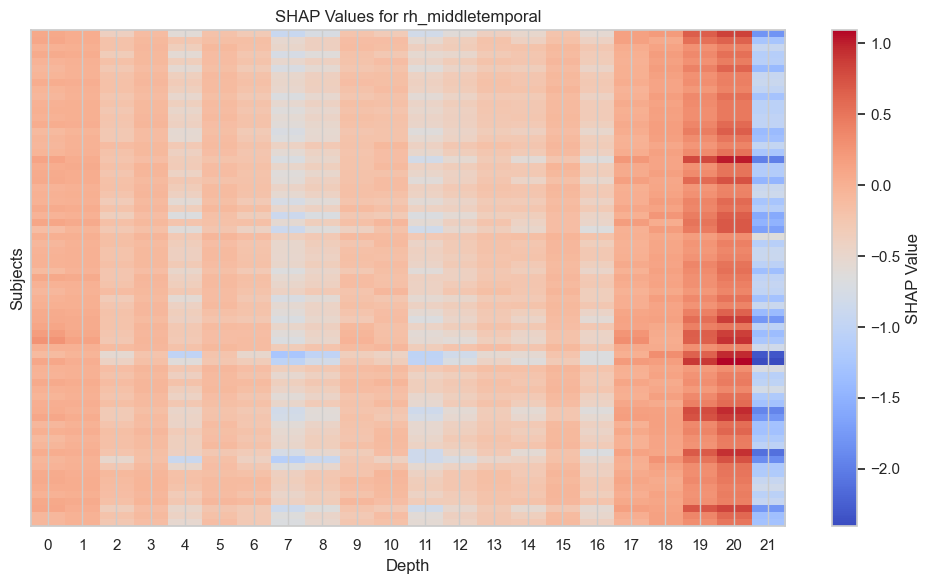

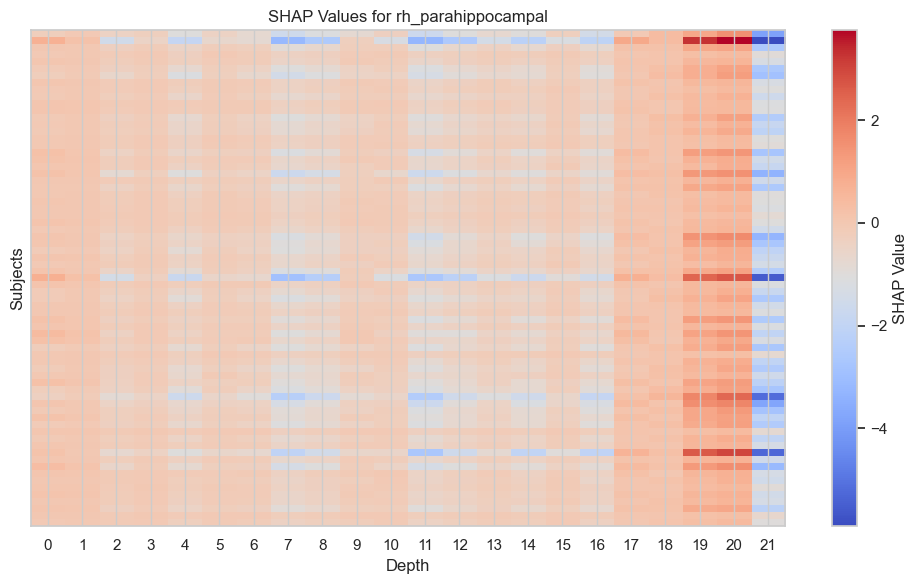

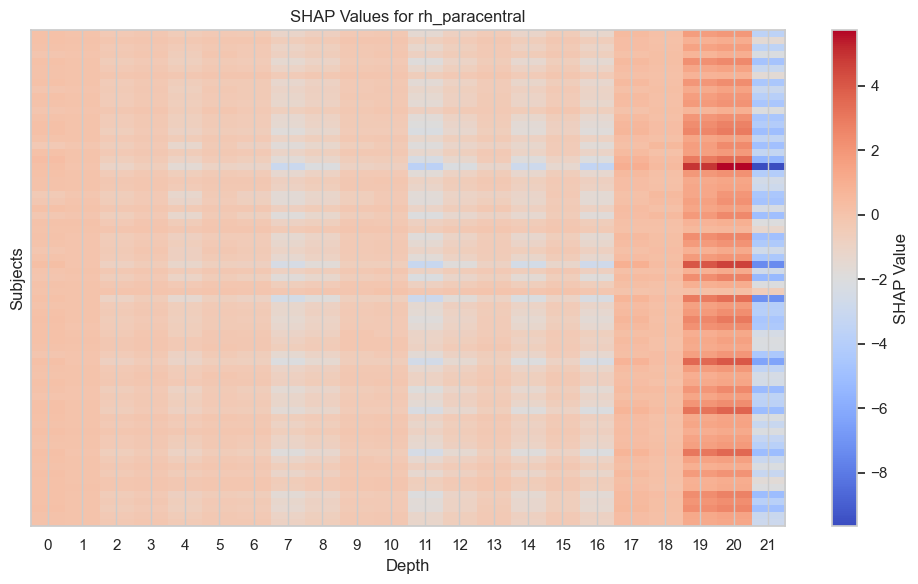

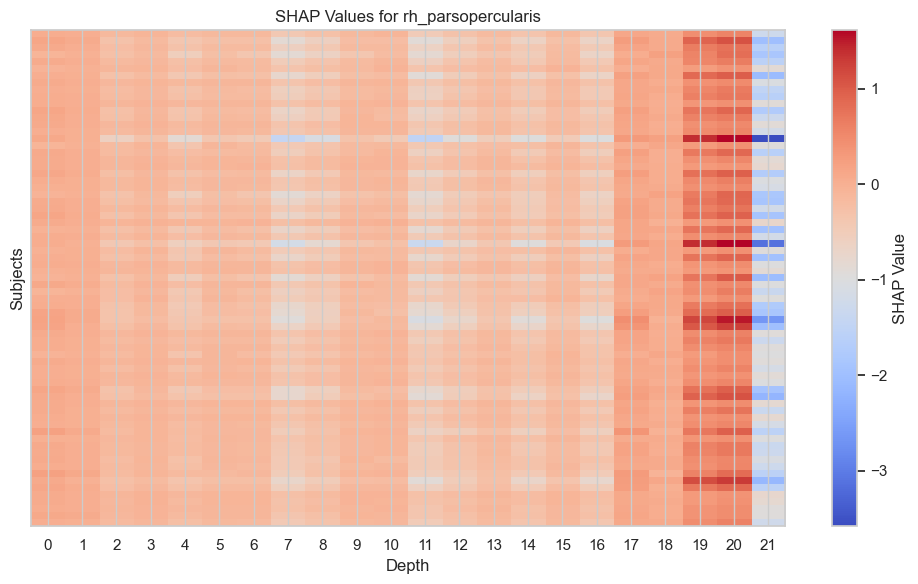

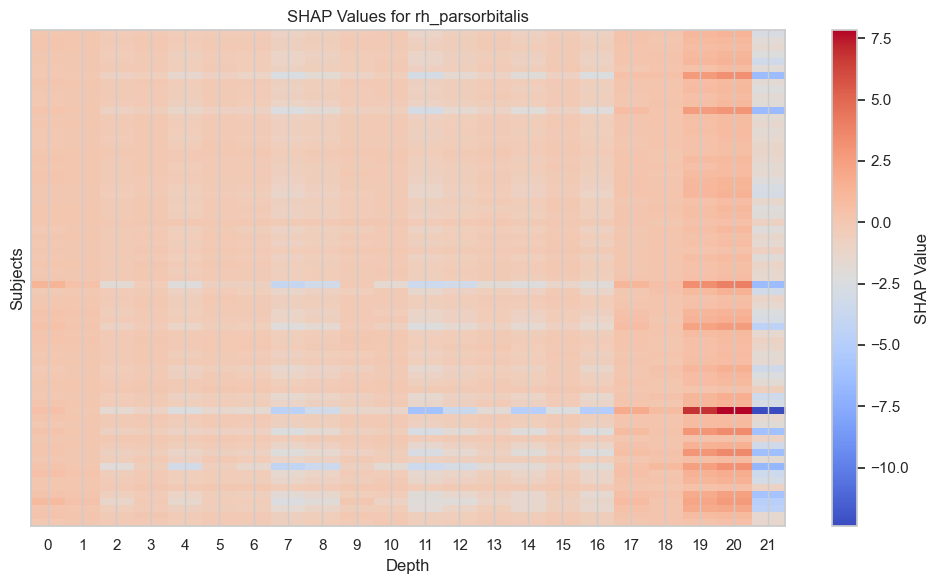

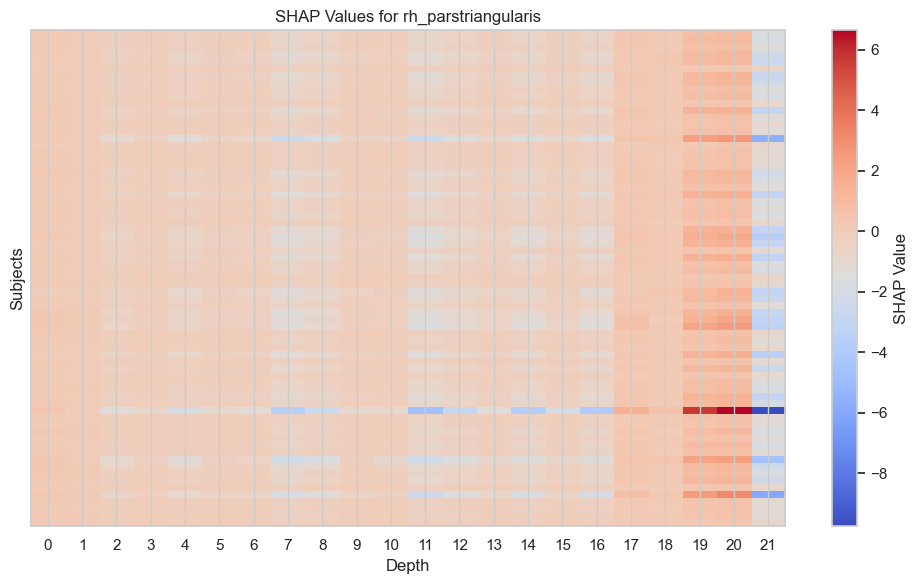

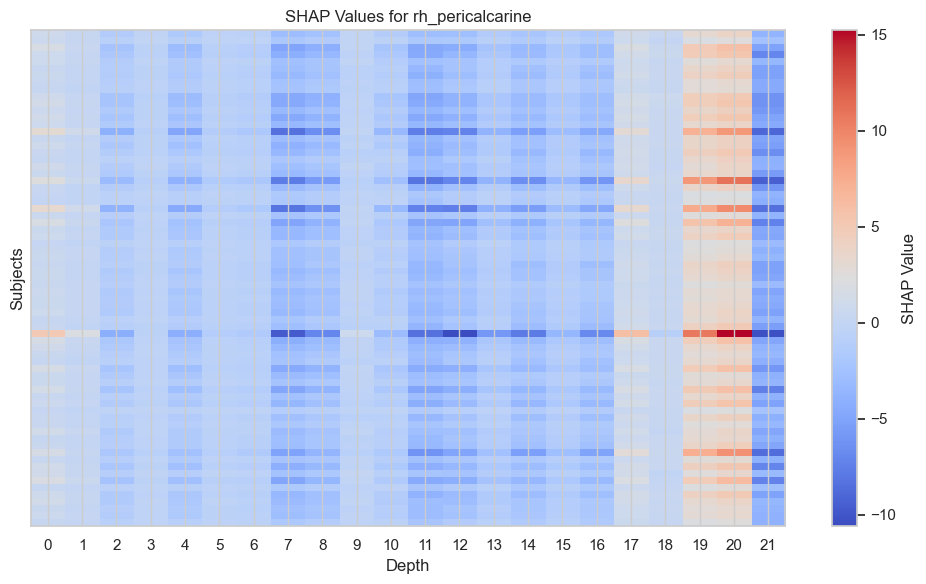

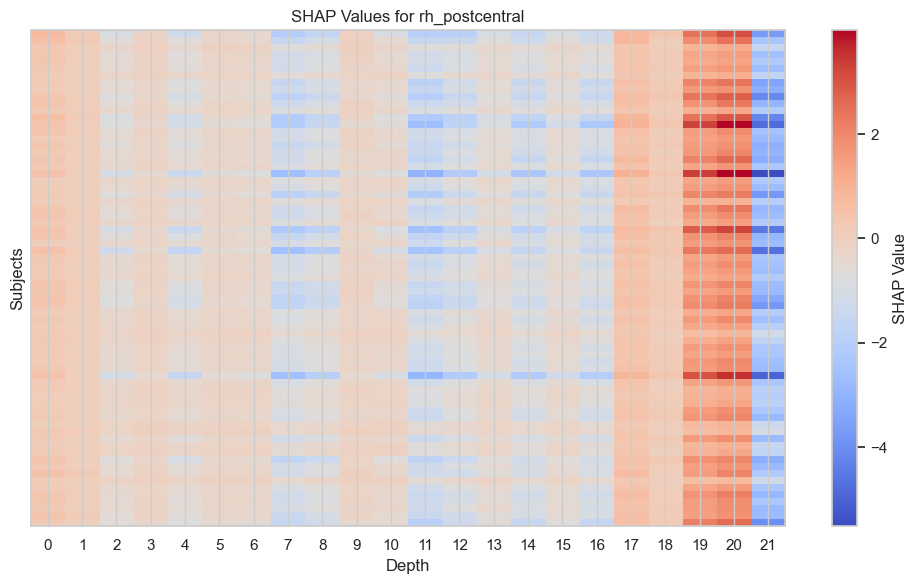

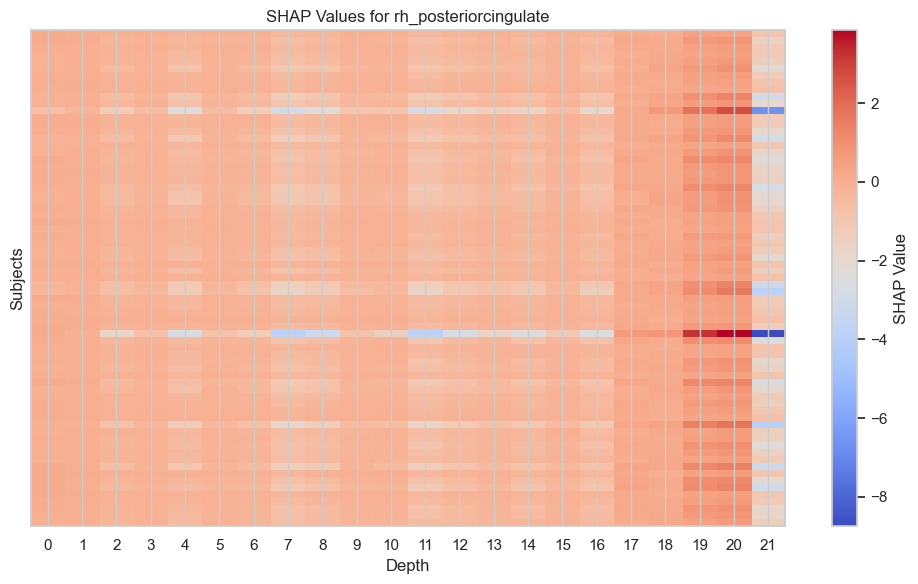

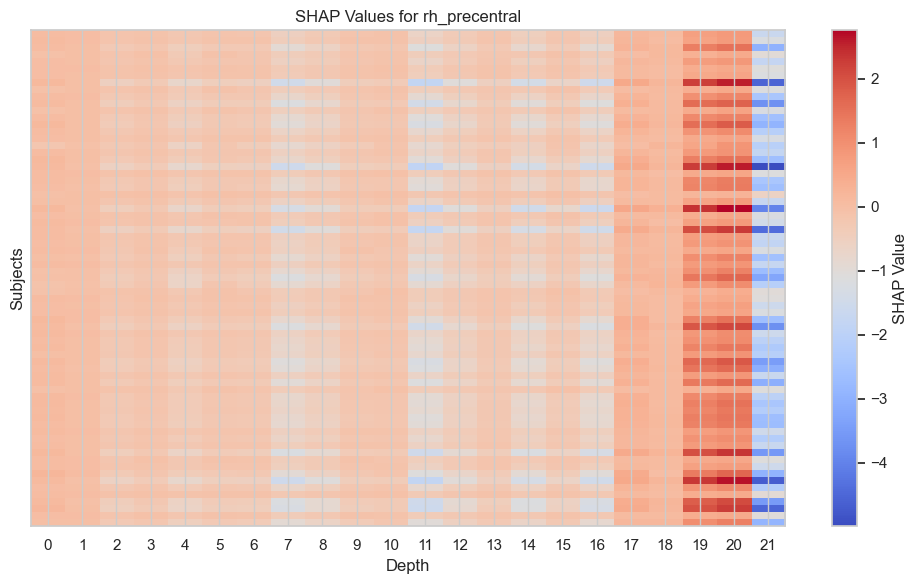

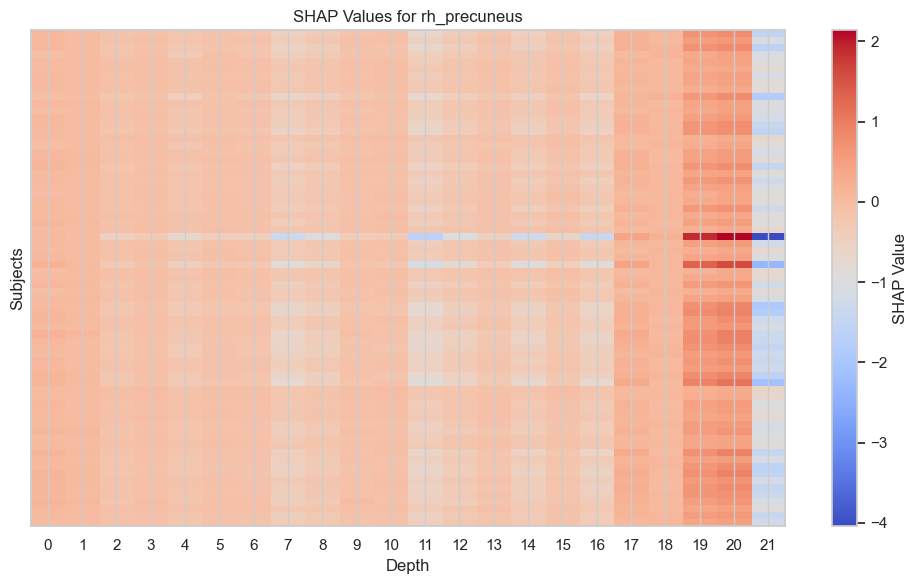

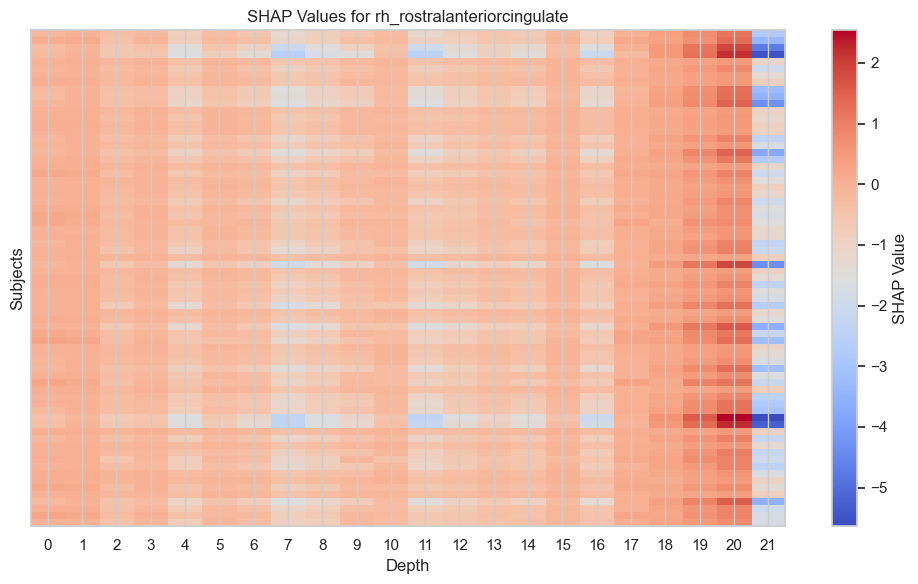

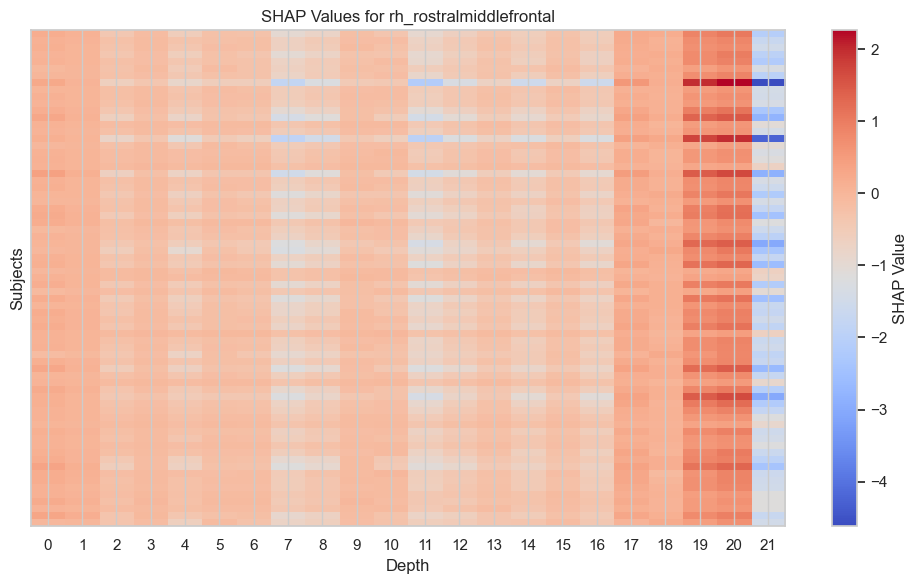

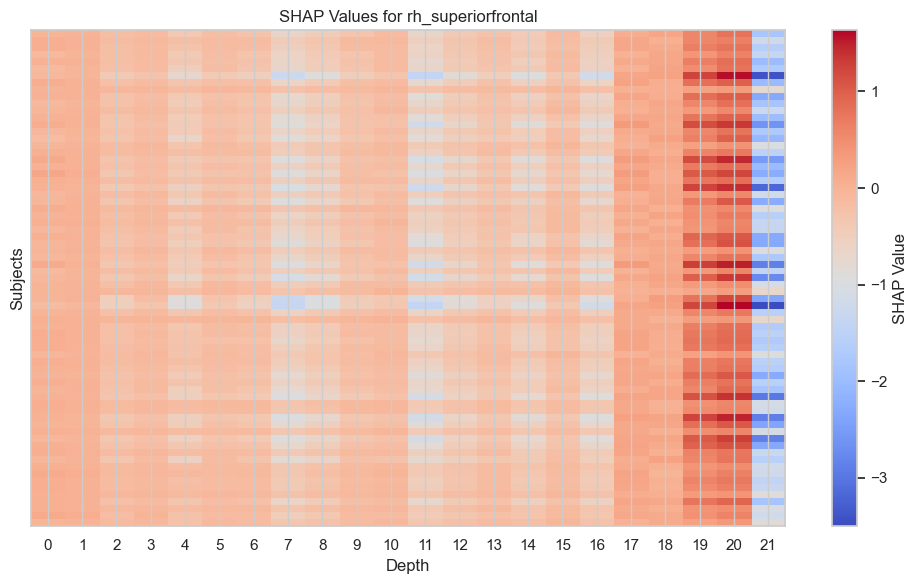

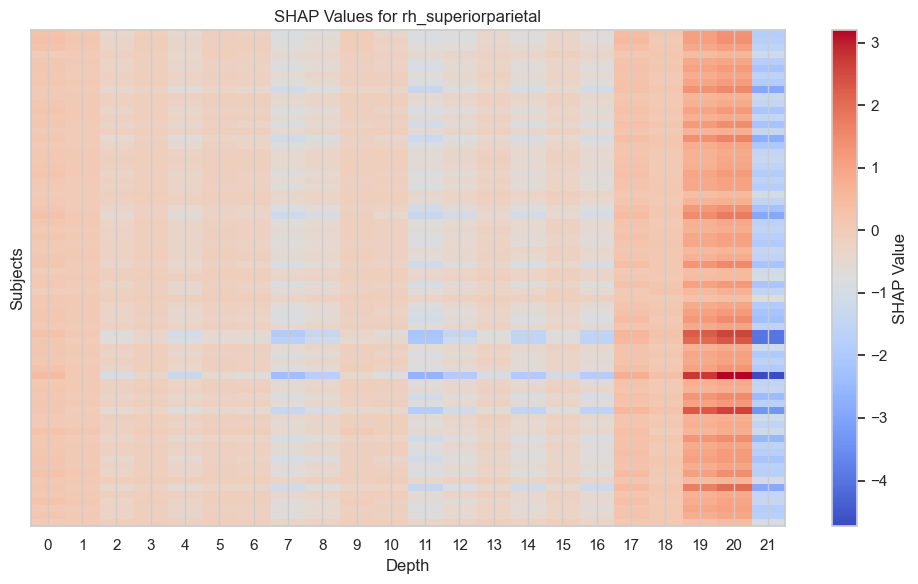

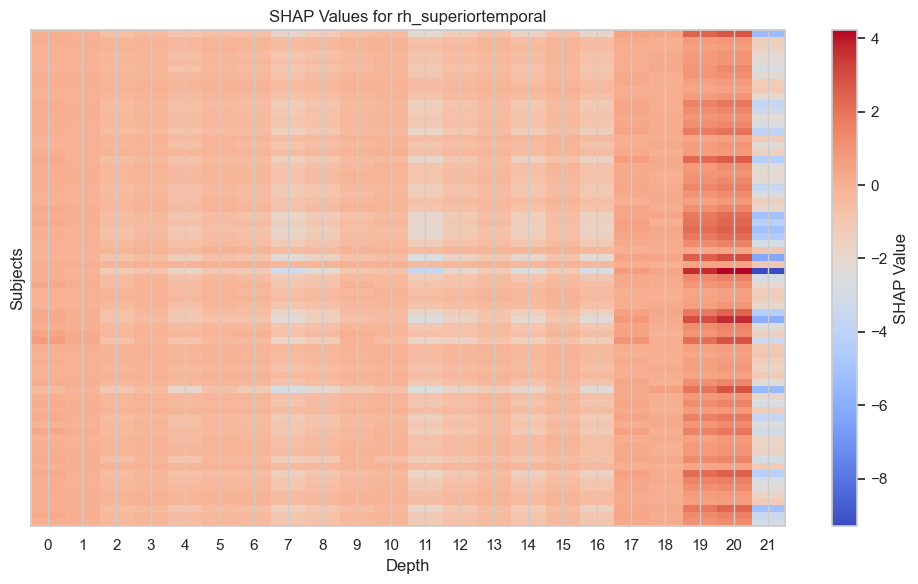

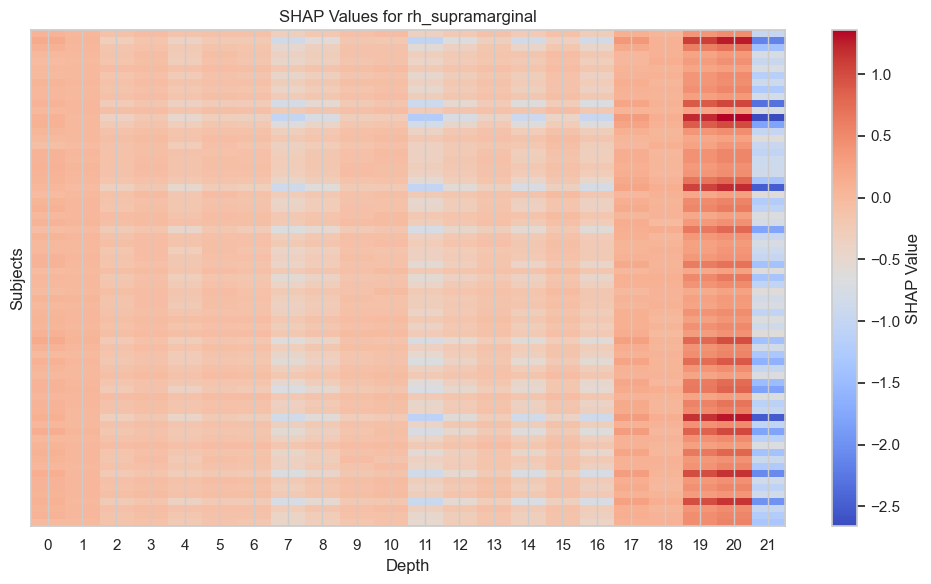

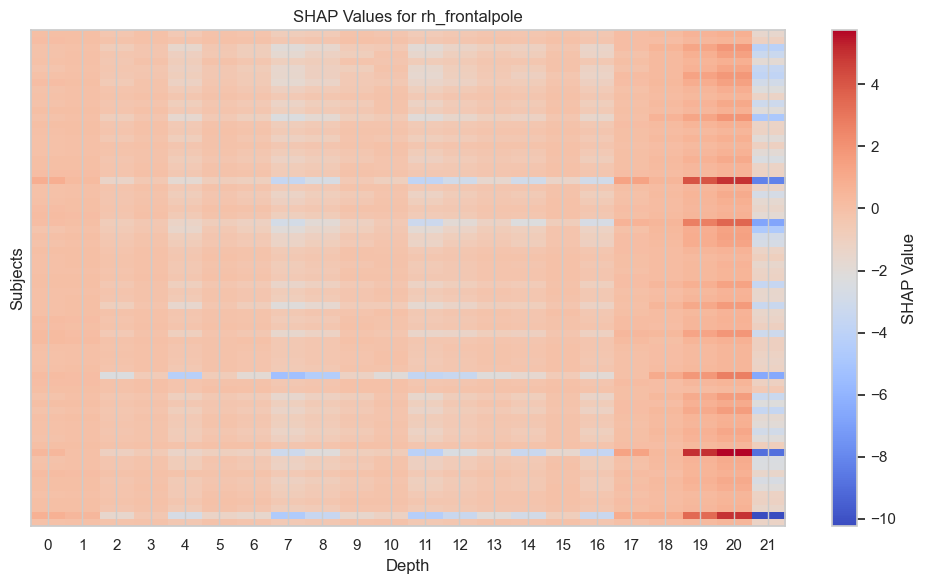

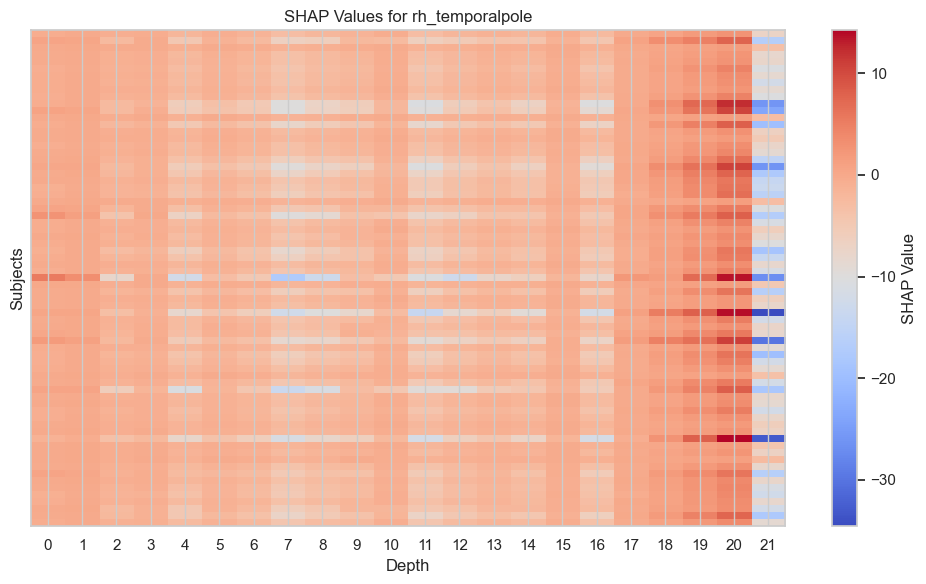

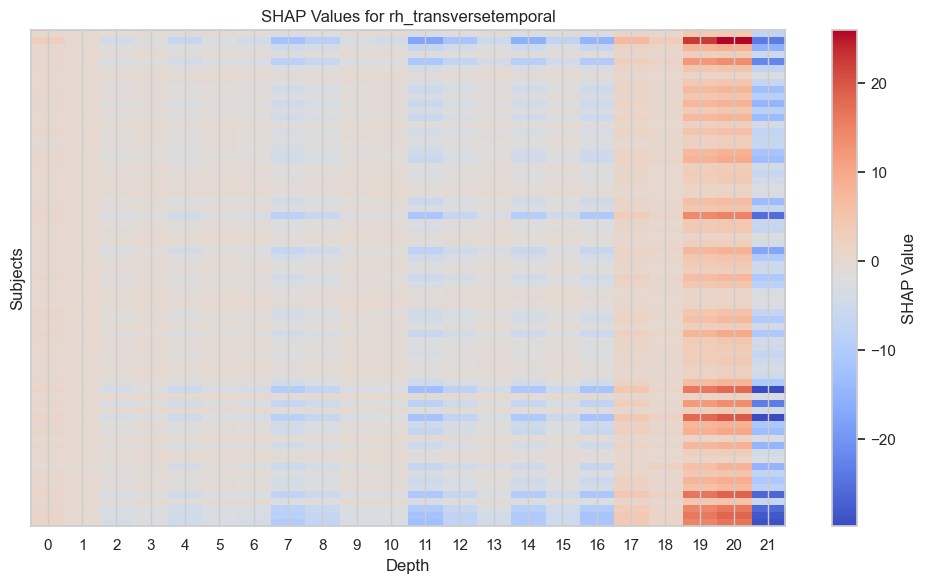

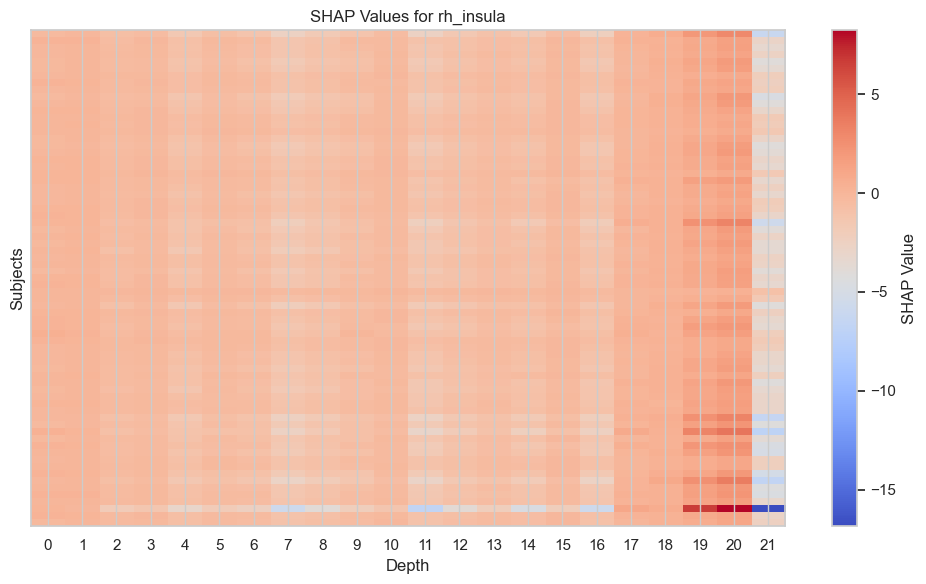

: 

In [ ]:
# Region-wise SHAP Summary
for region in xlabel:
    region_index = xlabel.index(region)
    region_shap_values = shap_ave[region_index, :]

    plt.figure(figsize=(10, 6))
    shap_array = np.array(shap_list)  # Convert list to numpy array
    plt.imshow(shap_array[:, region_index, :], cmap='coolwarm', aspect='auto', interpolation='nearest')
    plt.colorbar(label='SHAP Value')
    plt.title(f'SHAP Values for {region}')
    plt.xlabel('Depth')
    plt.ylabel('Subjects')
    plt.xticks(ticks=np.arange(num_depths), labels=[f"{i}" for i in range(num_depths)])
    plt.yticks([])  # Remove yticks
    plt.tight_layout()
    plt.show()